# Import and Function Definition

In [218]:
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib.pyplot as plt
import os, sys, pickle, glob
import qutip as qt
import textwrap
import experiments as meas

from copy import deepcopy
from collections import defaultdict
from tqdm.notebook import tqdm
from experiments.MM_dual_rail_base import MM_dual_rail_base
from fitting.fit_display_classes import GeneralFitting
from fitting.wigner import WignerAnalysis
from slab import AttrDict
from experiments import MultimodeStation, CharacterizationRunner, SweepRunner


REPO_ROOT = r"C:\python\multimode_expts" 
BASE_DIR  = r"C:\experiments"
RUN_PREFIX = "JOB-20260414"  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Helper Functions & Definitions

Run this section once (after the import cell). All later sections only call these -- no section depends on another.

In [219]:
# =====================================================================
# Helper Functions & Definitions -- run this ONE cell before any section
# below. Every function/class the notebook uses is defined here, so no
# section depends on another section's cells having been run first.
# (Requires the import cell above to have run: np, plt, meas, AttrDict, ...)
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import os, textwrap
from pathlib import Path
from collections import namedtuple, defaultdict



def pickle_return(filepath):
    with open(filepath, 'rb') as f:
        return pickle.load(f)

def experiment_list_return(experiment_name,
                           job_date,
                           job_start_num,
                           job_finish_num,
                           basedir = BASE_DIR,
                           verbose = False):
    object_directory = os.path.join(basedir, experiment_name, "expt_objs")
    exp_list_to_return = []
    job_path = f"JOB-{job_date}"
    for job_num in range(job_start_num, job_finish_num + 1):
        filepath = os.path.join(object_directory, f"{job_path}-{job_num:05d}_expt.pkl")
        try:
            exp_list_to_return.append(pickle_return(filepath))
        except Exception as e:
            if verbose == True:
                print(f"Error loading {filepath}: {e}")
            continue
    return exp_list_to_return

def retrieve_from_multiple_jobs(experiment_nane,
                                job_date_list,
                                job_start_num_list,
                                job_finish_num_list,
                                basedir = BASE_DIR):
    all_exp_list = []
    for job_date, job_start_num, job_finish_num in zip(job_date_list,job_start_num_list,job_finish_num_list):
        exp_list = experiment_list_return(experiment_nane,
                                          job_date,
                                          job_start_num,
                                          job_finish_num,
                                          basedir)
        all_exp_list.extend(exp_list)
    return all_exp_list

def check_program_class(obj,
                        class_name):
    if obj.prog.__class__.__name__ == class_name:
        return True
    return False

def hdf5_path_generator(project_name,
                        job_date,
                        job_start_num,
                        job_finish_num, 
                        experiement_name,
                        basedir = BASE_DIR,
                        verbose = False):
    object_directory = os.path.join(basedir, project_name, "data")
    path = {}
    hdf5_path_to_return = []
    if isinstance(job_date, int):
        job_path = f"JOB-{job_date}"
        for job_num in range(job_start_num, job_finish_num+1):
            filepath = os.path.join(object_directory, f"{job_path}-{job_num:05d}_{experiement_name}.h5")
            if os.path.exists(filepath):
                hdf5_path_to_return.append(filepath)
                if verbose:
                    print(f"[O] Found: {filepath}")
            else:
                if verbose:
                    print(f"[X] Missing: {filepath}")
        path[experiement_name] = hdf5_path_to_return
    elif isinstance(job_date, list):
        for date, start_num, finish_num in zip(job_date, job_start_num, job_finish_num):
            job_path = f"JOB-{date}"
            for job_num in range(start_num, finish_num+1):
                filepath = os.path.join(object_directory, f"{job_path}-{job_num:05d}_{experiement_name}.h5")
                if os.path.exists(filepath):
                    hdf5_path_to_return.append(filepath)
                    if verbose:
                        print(f"[O] Found: {filepath}")
                else:
                    if verbose:
                        print(f"[X] Missing: {filepath}")
            path[experiement_name] = hdf5_path_to_return
    return path

def path_to_experiment(hdf5_path, ExpClass):
    
    exp_name = list(hdf5_path.keys())[0]
    path_list = hdf5_path[exp_name]

    exp_list = []

    for fname in tqdm(path_list):
        obj = ExpClass.from_h5file(fname)

        obj.path = os.path.dirname(fname)
        obj.config_file = fname
        obj.prefix = os.path.splitext(os.path.basename(fname))[0]

        exp_list.append(obj)

    return exp_list

def get_inlier_indices(x, y, threshold=2.0):
    valid = np.isfinite(x) & np.isfinite(y)
    current_valid = valid.copy()
    indices = np.arange(len(x))
    
    for _ in range(10):  
        x_fit = x[current_valid]
        y_fit = y[current_valid]
        
        if len(x_fit) < 2:
            break 
            
        p = np.polyfit(x_fit, y_fit, 1)
        y_pred = np.polyval(p, x)
        
        residuals = np.abs(y - y_pred)
        
        mad = np.median(residuals[current_valid])
        sigma = 1.4826 * mad
        
        if sigma < 1e-10:  
            break
            
        new_valid = valid & (residuals < threshold * sigma)
        
        if np.array_equal(new_valid, current_valid):
            break 
            
        current_valid = new_valid
        
    return np.where(current_valid)[0]

def plot_freq_line_cut(target_freq):
    plot_gains = []
    plot_kerrs = []
    
    for expt in excursion_list:
        is_good = not getattr(expt, 'is_bad_data', False)
        is_target = (expt.cfg.expt.get('kerr_freq', np.nan) == target_freq)
        
        
        if is_target and is_good:
            plot_gains.append(expt.cfg.expt['kerr_gain'])
            plot_kerrs.append(np.abs(expt.data['Kerr'])) 
            
    if not plot_gains:
        print(f"No valid data for kerr freq = {target_freq}")
        return
        
    plt.figure(figsize=(8, 5))
    plt.scatter(plot_gains, plot_kerrs, s=50, label=f'Freq = {target_freq}')
    
    plt.xlabel('Gain [a.u.]', fontsize=12)
    plt.ylabel('|Kerr|', fontsize=12)
    plt.title(f'Kerr vs Gain Line Cut (Freq: {target_freq})', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

def estimate_periodicity(y, sampling_rate=1.0):
        # Compute FFT
        fft = np.fft.fft(y - np.mean(y))  # remove DC offset
        freqs = np.fft.fftfreq(len(y), d=1/sampling_rate)

        # Only take the positive frequencies
        pos_mask = freqs > 0
        freqs = freqs[pos_mask]
        power = np.abs(fft[pos_mask])

        # Find the dominant frequency
        dominant_freq = freqs[np.argmax(power)]

        # Convert frequency to period
        estimated_period = 1 / dominant_freq if dominant_freq != 0 else np.inf
        return estimated_period

def fit_model(x, alpha2, f, scale, offset, phase):
    return scale * np.exp(-2.0*alpha2*(1.0 + np.cos(2.0*np.pi*f*x - phase))) + offset

def fit_func(x, kc, delta):
    return  kc * x + delta

def estimate_phase(y, debug = False):
    if debug == True:
        print("y[0]", y[0], "min", np.min(y), "max", np.max(y))
    return np.abs(y[0] - np.min(y)) / np.abs(np.max(y) - np.min(y)) * np.pi/2

def normalize(z, exp_obj):
    Ig = exp_obj.cfg.device.readout.Ig[0]
    Ie = exp_obj.cfg.device.readout.Ie[0]
    return (z - Ig) / (Ie - Ig)

def _cfg_get(cfg, path, default=None):
    cur = cfg
    for key in path.split("."):
        if cur is None:
            return default
        if isinstance(cur, dict):
            cur = cur.get(key, None)
        else:
            cur = getattr(cur, key, None)
    return default if cur is None else cur

def _normalize_from_obj_or_cfg(obj, avgi_2d):
    if hasattr(obj, "normalize") and callable(getattr(obj, "normalize")):
        try:
            return obj.normalize(avgi_2d)
        except Exception:
            pass

    Ig = _cfg_get(obj.cfg, "device.readout.Ig", None)
    Ie = _cfg_get(obj.cfg, "device.readout.Ie", None)
    if Ig is None or Ie is None:
        return np.array(avgi_2d, float)

    Ig = float(Ig[0] if isinstance(Ig, (list, tuple, np.ndarray)) else Ig)
    Ie = float(Ie[0] if isinstance(Ie, (list, tuple, np.ndarray)) else Ie)
    denom = (Ie - Ig)
    if denom == 0:
        return np.array(avgi_2d, float)
    return (np.array(avgi_2d, float) - Ig) / denom

def kerr_ramsey_model_phi(x, alpha2, f, phi0, scale, offset):
    return scale * np.exp(-2.0 * alpha2 * (1.0 + np.cos(2.0*np.pi*f*x + phi0))) + offset

def linear_model(x, kc, delta):
    return kc * x + delta

def post_refit_one_cavity_ramsey_v2(
    obj,
    *,
    smooth_sigma=1.5,
    rsq_threshold=0.2,
    f_window_mhz=5.0,       
    # alpha2_mode="bounded",     
    alpha2_bound_ratio=(0.3, 3.0),
    use_smoothed_for_fit=True,
    verbose=False,
    method_setting = None
):
    # x/y
    x = np.array(obj.data.get("xpts", _cfg_get(obj.cfg, "expt.kerr_lengths")), float)
    y = np.array(obj.data.get("gain_list", _cfg_get(obj.cfg, "expt.displace_gains")), float)

    avgi_2d = np.array(obj.data["g_avgi"], float)
    n_lines, n_x = avgi_2d.shape

    z = _normalize_from_obj_or_cfg(obj, avgi_2d)

    virtual_freq = float(_cfg_get(obj.cfg, "expt.ramsey_freq", 0.0) or 0.0)

    g2a = _cfg_get(obj.cfg, "device.manipulate.gain_to_alpha", None)
    man_mode_no = obj.cfg.expt.get('man_mode_no', 1)
    if isinstance(g2a, (list, tuple, np.ndarray)):
        g2a = g2a[man_mode_no-1] if len(g2a) else None

    model = Model(kerr_ramsey_model_phi)

    fit_lids, fit_results, z_fits, rsqs = [], [], [], []
    alpha2_fits, f_fits, phi0_fits = [], [], []

    for lid in range(n_lines):
        line = np.array(z[lid, :], float)
        line_sm = gaussian_filter1d(line, sigma=smooth_sigma)

        yfit = line_sm if use_smoothed_for_fit else line

        off0 = float(np.nanmin(yfit))
        sc0 = float(np.nanmax(yfit) - off0)
        sc0 = max(sc0, 1e-3)

        if g2a is not None:
            alpha_guess = float(y[lid]) * float(g2a)
            alpha2_0 = max(alpha_guess*alpha_guess, 0.0)
        else:
            alpha2_0 = 0.2  # fallback

        params = model.make_params(
            alpha2=alpha2_0,
            f=virtual_freq,
            phi0=0.0,
            scale=sc0,
            offset=off0,
        )

        # if alpha2_mode == "fixed":
        params["alpha2"].set(value=alpha2_0, vary=False)
        # elif alpha2_mode == "bounded":
        #     lo, hi = alpha2_bound_ratio
        #     params["alpha2"].set(value=alpha2_0,
        #                          min=max(lo*alpha2_0, 0.0),
        #                          max=max(hi*alpha2_0, 1e-12),
        #                          vary=True)
        # elif alpha2_mode == "free":
        #     params["alpha2"].set(value=alpha2_0, min=0.0, vary=True)
        # else:
        #     raise ValueError("alpha2_mode must be fixed|bounded|free")
        if f_window_mhz == None:
            params["f"].set(value=virtual_freq)
        else:
            params["f"].set(value=virtual_freq #)
                            , min=virtual_freq - f_window_mhz
                            , max=virtual_freq + f_window_mhz)

        params["phi0"].set(value=0.0, min=-np.pi, max=np.pi)

        params["scale"].set(value=sc0, min=0.0, max=2.0)
        params["offset"].set(value=off0)#, min=-0.5, max=1.5)

        try:
            # res = model.fit(yfit, params, x=x[lid], nan_policy="omit",
            if method_setting == "basinhopping" :
                res_global = model.fit(yfit, params, x=x[lid], nan_policy="omit", 
                                    method="basinhopping")
                res = model.fit(yfit, res_global.params, x=x[lid], nan_policy="omit", 
                                method="leastsq")
            else:
                res = model.fit(yfit, params, x=x[lid], nan_policy="omit", 
                                    method="leastsq")
            fit_lids.append(lid)
            fit_results.append(res)
            z_fits.append(res.best_fit)

            alpha2_fits.append(float(res.params["alpha2"].value))
            f_fits.append(float(res.params["f"].value))
            phi0_fits.append(float(res.params["phi0"].value))
            rsq = float(getattr(res, "rsquared", np.nan))
            rsqs.append(rsq)

            if verbose:
                print(f"lid={lid:3d} rsq={rsq:.3f} f={f_fits[-1]:.4f} phi0={phi0_fits[-1]:+.3f} alpha2={alpha2_fits[-1]:.3g}")

        except Exception as e:
            if verbose:
                print(f"lid={lid:3d} failed: {e!r}")
            continue

    fit_lids = np.array(fit_lids, int)
    rsqs = np.array(rsqs, float)
    alpha2_fits = np.array(alpha2_fits, float)
    f_fits = np.array(f_fits, float)
    phi0_fits = np.array(phi0_fits, float)
    z_fits = np.array(z_fits, float) if len(z_fits) else np.zeros((0, n_x), float)

    fit_good = np.isfinite(rsqs) & (rsqs > rsq_threshold)

    alpha2_good = alpha2_fits[fit_good]
    f_det = (f_fits[fit_good] - virtual_freq)

    # linear fit
    kc = np.nan
    delta = np.nan
    linear_fit_result = None
    try:
        if len(alpha2_good) >= 2:
            lm = Model(linear_model, independent_vars=["x"])
            lp = lm.make_params(kc=1.0, delta=0.0)
            linear_fit_result = lm.fit(f_det, lp, x=alpha2_good, nan_policy="omit")
            kc = float(linear_fit_result.params["kc"].value)
            delta = float(linear_fit_result.params["delta"].value)
    except Exception:
        pass

    obj.fit_results = AttrDict(dict(
        alpha2=alpha2_good,
        f=f_det,
        kc=kc,
        delta=delta,
        linear_fit_result=linear_fit_result,

        results=fit_results,
        z_fits=z_fits,
        rsquared=rsqs,
        fit_lids=fit_lids,
        fit_good=fit_good,

        virtual_freq=virtual_freq,
        f_window_mhz=f_window_mhz,
        # alpha2_mode=alpha2_mode,
    ))

    return obj.fit_results

def _first_scalar(value):
    arr = np.asarray(value)
    if arr.size == 0:
        return None
    out = arr.reshape(-1)[0]
    return out.item() if hasattr(out, 'item') else out

def wigner_stor_label(ro_stor):
    return 'M1' if int(ro_stor) == 0 else f'S{int(ro_stor)}'

def _ensure_multiparity_read_num(expt):
    """Backfill expt.cfg.read_num when it was not saved to the .h5 (e.g. Qsim
    runs). Defined here so this cell is self-contained -- do not rely on the copy
    in the confusion-matrix cell being run first."""
    if 'read_num' in expt.cfg:
        return

    reps = int(expt.cfg.expt.get('reps', 1))
    rounds = int(expt.cfg.expt.get('rounds', 1))
    shots_per_point = np.asarray(expt.data['idata'][0]).size
    shots_per_round = max(reps * rounds, 1)
    if shots_per_point % shots_per_round == 0:
        expt.cfg.read_num = shots_per_point // shots_per_round
        return

    read_num = 1
    if expt.cfg.expt.get('parity_check', False):
        read_num += 1
    if expt.cfg.expt.get('active_reset', False):
        try:
            from experiments.MM_base import MMAveragerProgram
            params = MMAveragerProgram.get_active_reset_params(expt.cfg)
            read_num += MMAveragerProgram.active_reset_read_num(**params)
        except Exception:
            pass
    if expt.cfg.expt.get('multiparity_readout', False):
        read_num += 1
    expt.cfg.read_num = read_num

def _nmod4_from_two_parity_readouts(expt, point_idx=0, threshold=None, e_is_high_I=True):
    _ensure_multiparity_read_num(expt)
    rn = int(expt.cfg.read_num)
    q_test = int(expt.cfg.expt.qubits[0])
    if threshold is None:
        threshold = expt.cfg.device.readout.threshold[q_test]

    idata = np.asarray(expt.data['idata'][point_idx])
    i_first = idata[rn - 2::rn]
    i_second = idata[rn - 1::rn]

    if e_is_high_I:
        b0 = (i_first > threshold).astype(int)
        b1 = (i_second > threshold).astype(int)
    else:
        b0 = (i_first < threshold).astype(int)
        b1 = (i_second < threshold).astype(int)
    return b0 + 2 * b1

def build_mod4_confusion_from_h5_files(h5_files, prepared_states=(0, 1, 2, 3), point_idx=0):
    """Return C[row prepared n, col measured n mod 4] and integer counts."""
    counts = np.zeros((4, 4), dtype=int)
    for fallback_state, h5_file in zip(prepared_states, h5_files):
        expt = DarkBaseExperiment.from_h5file(h5_file)
        prepared = int(expt.cfg.expt.get('init_man_fock_state', fallback_state))
        if prepared not in (0, 1, 2, 3):
            prepared = int(fallback_state)

        xpts = np.asarray(expt.data.get('xpts', [0])).reshape(-1)
        point_indices = range(len(xpts)) if point_idx is None else [point_idx]
        for idx in point_indices:
            n_mod4 = _nmod4_from_two_parity_readouts(expt, point_idx=idx)
            counts[prepared] += np.bincount(n_mod4.astype(int), minlength=4)

    confusion = np.divide(
        counts,
        counts.sum(axis=1, keepdims=True),
        out=np.full(counts.shape, np.nan, dtype=float),
        where=counts.sum(axis=1, keepdims=True) > 0,
    )
    return confusion, counts

def single_parity_confusion_from_mod4_counts(
    mod4_counts,
    prepared_groups=((0,), (1,)),
    measured_groups=((0, 2), (1, 3)),
):
    """Convert modulo-4 counts to [P00, P01, P10, P11] for WignerAnalysis.

    The default uses prepared Fock |0>, |1> and collapses measured modulo-4
    outcomes into even/odd parity. For all modulo-4 rows, use
    prepared_groups=((0, 2), (1, 3)). For a literal top-left 2x2 block, use
    measured_groups=((0,), (1,)).
    """
    mod4_counts = np.asarray(mod4_counts, dtype=float)
    parity_counts = np.array([
        [mod4_counts[list(prepared), :][:, list(measured)].sum()
         for measured in measured_groups]
        for prepared in prepared_groups
    ])
    parity_probs = np.divide(
        parity_counts,
        parity_counts.sum(axis=1, keepdims=True),
        out=np.full(parity_counts.shape, np.nan, dtype=float),
        where=parity_counts.sum(axis=1, keepdims=True) > 0,
    )
    return parity_probs.reshape(-1).tolist(), parity_probs, parity_counts.astype(int)

def plot_mod4_confusion(matrix, counts=None, title='Modulo-4 readout confusion matrix'):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(matrix, vmin=0, vmax=1, cmap='viridis')
    ax.set_xlabel(r'Measured $n$ mod 4')
    ax.set_ylabel('Prepared Fock state')
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_title(title)
    for i in range(4):
        for j in range(4):
            label = f'{matrix[i, j]:.3f}'
            if counts is not None:
                label += f'\n({int(counts[i, j])})'
            color = 'white' if matrix[i, j] < 0.45 else 'black'
            ax.text(j, i, label, ha='center', va='center', color=color)
    fig.colorbar(im, ax=ax, label=r'$P(\mathrm{measured}\mid\mathrm{prepared})$')
    fig.tight_layout()
    return fig, ax

def apply_single_parity_confusion(wigner_expt, confusion_matrix, apply_to='auto'):
    if confusion_matrix is None:
        return

    cm = [float(x) for x in confusion_matrix]
    ro = wigner_expt.cfg.device.readout
    use_active = wigner_expt.cfg.expt.get('active_reset', False)

    if apply_to == 'both' or (apply_to == 'auto' and use_active) or apply_to == 'active':
        ro.confusion_matrix_with_active_reset = cm
        ro.confusion_matrix_with_reset = cm
    if apply_to == 'both' or (apply_to == 'auto' and not use_active) or apply_to == 'without_reset':
        ro.confusion_matrix_without_reset = cm

def load_wigner_h5(h5_file, confusion_matrix=None, confusion_apply_to='auto'):
    wigner_expt = QsimWignerBaseExperiment.from_h5file(h5_file)
    wigner_expt.path = os.path.dirname(h5_file)
    wigner_expt.config_file = h5_file
    wigner_expt.prefix = os.path.splitext(os.path.basename(h5_file))[0]
    apply_single_parity_confusion(wigner_expt, confusion_matrix, apply_to=confusion_apply_to)
    return wigner_expt

def analyze_wigner_h5_files(
    h5_files,
    cutoff=10,
    initial_state=None,
    num_shots_sample=None,
    parity_post_select=None,
    confusion_matrix=None,
    confusion_apply_to='auto',
    rotate=True,
    display=True,
    clear_each=False,
    debug=True,
    analysis_label=None,
):
    if initial_state is None:
        initial_state = qt.basis(cutoff, 0).unit()

    station_arg = station if 'station' in globals() else None
    data_by_stor = defaultdict(lambda: {
        'file': [], 'floquet': [], 'purity': [], 'rho': [], 'W_fits': [], 'x_vecs': []
    })
    records = []
    outer_param = []
    purity_list = []
    rho_list = []
    W_fits = []
    x_vecs = []

    for h5_file in h5_files:
        if not Path(h5_file).exists():
            print('Missing Wigner HDF5 file:', h5_file)
            continue

        test_wigner = load_wigner_h5(
            h5_file,
            confusion_matrix=confusion_matrix,
            confusion_apply_to=confusion_apply_to,
        )
        if parity_post_select is not None:
            test_wigner.cfg.expt.parity_post_select = parity_post_select

        if num_shots_sample is None:
            test_wigner.analyze_wigner(mode_state_num=cutoff, debug=debug)
        else:
            test_wigner.analyze_wigner_temp(
                mode_state_num=cutoff,
                num_shots_sample=num_shots_sample,
                debug=debug,
            )

        if display:
            test_wigner.display(
                rotate=rotate,
                initial_state=initial_state,
                mode_state_num=cutoff,
                station=station_arg,
                save_fig=False,
            )
            fig = plt.gcf()
            if analysis_label:
                current_title = fig._suptitle.get_text() if fig._suptitle is not None else ''
                fig.suptitle(f'{analysis_label}\n{current_title}', fontsize=16)
            if clear_each:
                plt.close(fig)

        wigner_outputs = test_wigner.data['wigner_outputs']
        rho = np.asarray(wigner_outputs['rho'][0][0])
        W_fit = wigner_outputs['W_fit'][0][0]
        x_vec = wigner_outputs['alpha_wigner'][0][0]
        purity = np.real(np.trace(rho @ rho))
        ro_stor = int(test_wigner.cfg.expt.get('ro_stor', 0))
        floquet = test_wigner.cfg.expt.get('floquet_cycle', _first_scalar(test_wigner.outer_params))

        outer_param.append(test_wigner.outer_params)
        purity_list.append(purity)
        rho_list.append(rho)
        W_fits.append(W_fit)
        x_vecs.append(x_vec)

        entry = data_by_stor[ro_stor]
        entry['file'].append(h5_file)
        entry['floquet'].append(floquet)
        entry['purity'].append(purity)
        entry['rho'].append(rho)
        entry['W_fits'].append(W_fit)
        entry['x_vecs'].append(x_vec)

        records.append({
            'file': h5_file,
            'expt': test_wigner,
            'ro_stor': ro_stor,
            'floquet': floquet,
            'label': analysis_label,
            'purity': purity,
            'rho': rho,
            'W_fit': W_fit,
            'x_vec': x_vec,
        })

    return {
        'records': records,
        'data': dict(data_by_stor),
        'outer_param': outer_param,
        'purity_list': purity_list,
        'rho_list': rho_list,
        'W_fits': W_fits,
        'x_vecs': x_vecs,
    }

def _as_float_scalar(value):
    arr = np.asarray(value)
    if arr.size == 0:
        return np.nan
    return float(np.real(arr.reshape(-1)[0]))

def _target_density_matrix(target_state):
    target_state = target_state.unit()
    return target_state if target_state.isoper else qt.ket2dm(target_state)

def wigner_metric_summary(records, target_state=None, label='corrected'):
    """Return per-record rho purity and ideal-state fidelity/overlap.

    Purity is Tr(rho^2). It does not use the ideal state. The ideal-state
    comparison is reported separately as fidelity_to_ideal, matching the
    fidelity shown in the Wigner display figure.
    """
    target_dm = _target_density_matrix(target_state) if target_state is not None else None
    target_arr = target_dm.full() if target_dm is not None else None

    rows = []
    for rec in records:
        wo = rec['expt'].data['wigner_outputs']
        rho = np.asarray(wo.get('rho_rotated', wo['rho'])[0][0])
        rho_unrotated = np.asarray(wo['rho'][0][0])
        purity = float(np.real(np.trace(rho @ rho)))
        purity_unrotated = float(np.real(np.trace(rho_unrotated @ rho_unrotated)))
        fidelity = _as_float_scalar(wo['fidelity'][0][0]) if 'fidelity' in wo else np.nan
        target_overlap = float(np.real(np.trace(rho @ target_arr))) if target_arr is not None else np.nan

        rows.append({
            'label': label,
            'file': rec['file'],
            'ro_stor': rec['ro_stor'],
            'mode': wigner_stor_label(rec['ro_stor']),
            'floquet': rec['floquet'],
            'purity': purity,
            'purity_unrotated': purity_unrotated,
            'fidelity_to_ideal': fidelity,
            'target_overlap': target_overlap,
        })
    return rows

def build_wigner_metrics(raw_records, corrected_records, target_state):
    rows = []
    rows.extend(wigner_metric_summary(raw_records, target_state=target_state, label='raw'))
    rows.extend(wigner_metric_summary(corrected_records, target_state=target_state, label='corrected'))
    try:
        import pandas as pd
        return pd.DataFrame(rows)
    except Exception:
        return rows

def _metric_column(metrics, key):
    if hasattr(metrics, 'columns'):
        return np.asarray(metrics[key])
    return np.asarray([row[key] for row in metrics])

def _metric_rows(metrics):
    if hasattr(metrics, 'to_dict'):
        return metrics.to_dict('records')
    return metrics

def compare_wigner_correction_h5_files(
    h5_files,
    corrected_confusion_matrix,
    cutoff=10,
    initial_state=None,
    num_shots_sample=None,
    parity_post_select=False,
    rotate=True,
    display=True,
    debug=True,
):
    """Run Wigner tomography twice: identity readout matrix, then corrected matrix.

    The "No readout correction" pass is implemented by injecting the identity
    assignment matrix into the same WignerAnalysis path used by the corrected
    pass. That leaves the parity mapping unchanged and removes only the readout
    confusion inversion.
    """
    raw = analyze_wigner_h5_files(
        h5_files,
        cutoff=cutoff,
        initial_state=initial_state,
        num_shots_sample=num_shots_sample,
        parity_post_select=parity_post_select,
        confusion_matrix=IDENTITY_PARITY_CONFUSION,
        confusion_apply_to='both',
        rotate=rotate,
        display=display,
        clear_each=False,
        debug=debug,
        analysis_label='No readout correction',
    )

    corrected = analyze_wigner_h5_files(
        h5_files,
        cutoff=cutoff,
        initial_state=initial_state,
        num_shots_sample=num_shots_sample,
        parity_post_select=parity_post_select,
        confusion_matrix=corrected_confusion_matrix,
        confusion_apply_to='both',
        rotate=rotate,
        display=display,
        clear_each=False,
        debug=debug,
        analysis_label='Corrected with multiparity confusion matrix',
    )

    return {'raw': raw, 'corrected': corrected}

def plot_thick_line_with_dots(ax, x, y, label=None, color=None):
    line, = ax.plot(x, y, linestyle='-', linewidth=4.0, alpha=0.3, label=label, color=color)
    col = line.get_color()
    ax.plot(x, y, marker='o', linestyle='None', markersize=8, alpha=1.0, color=col)
    return col

def _sine(t, A, f, phi, C):
    return A * np.sin(2 * np.pi * f * t + phi) + C

def fit_sine(t, y):
    """Fit y(t) to a sine. Returns dict with f [MHz], omega [Mrad/s], A, phi, C, popt; None on failure."""
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    order = np.argsort(t)
    t, y = t[order], y[order]
    if len(t) < 4 or np.ptp(y) == 0 or np.ptp(t) == 0:
        return None
    C0 = float(np.mean(y))
    A0 = float(np.ptp(y) / 2) or 1.0
    # FFT-based frequency guess (assumes ~uniform sampling in t)
    dt = float(np.median(np.diff(t)))
    if dt <= 0:
        return None
    spec = np.abs(np.fft.rfft(y - C0))
    freqs = np.fft.rfftfreq(len(t), d=dt)
    f0 = freqs[1:][np.argmax(spec[1:])] if len(freqs) > 2 else 1.0 / np.ptp(t)
    p0 = [A0, max(float(f0), 1e-9), 0.0, C0]
    try:
        popt, _ = curve_fit(_sine, t, y, p0=p0, maxfev=20000)
    except Exception:
        return None
    A, f, phi, C = popt
    f = abs(float(f))
    return {'f': f, 'omega': 2 * np.pi * f, 'A': abs(float(A)),
            'phi': float(phi) % (2 * np.pi), 'C': float(C), 'popt': popt}

def exp_decay(x, y0, amp, tau):
    return y0 + amp * np.exp(-(x - np.min(x)) / tau)

def fit_t1(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    y0_guess = np.mean(y[-max(5, len(y)//10):])
    amp_guess = y[0] - y0_guess
    tau_guess = 0.5 * (np.max(x) - np.min(x))

    model = Model(exp_decay)
    params = model.make_params(y0=y0_guess, amp=amp_guess, tau=tau_guess)
    params['tau'].min = 0

    result = model.fit(y, params, x=x)

    return result

def set_confusion_matrix(C):
    """Set the global confusion matrix used by correct_distribution().

    Stores the row-normalized matrix in `confusion_matrix` and its inverse
    transpose in `confusion_inv`  (p_meas = C.T @ p_true -> p_true = inv(C.T) @ p_meas).
    """
    global confusion_matrix, confusion_inv
    C = np.asarray(C, dtype=float)
    confusion_matrix = C / C.sum(axis=1, keepdims=True)
    confusion_inv = np.linalg.inv(confusion_matrix.T)
    return confusion_matrix

def get_dark_params(expts):
    """Extract (and validate identical across `expts`) the dark-readout config
    from cfg.expt, returning a DarkParams. Also updates the module-level
    DARK_PARAMS so downstream label/plot helpers pick up this dataset's params."""
    global DARK_PARAMS
    e0 = expts[0].cfg.expt
    params = DarkParams(e0.swap_stors, e0.swap_man_dark, e0.dark_swap_order)
    for exp in expts:
        c = exp.cfg.expt
        if (c.swap_stors, c.swap_man_dark, c.dark_swap_order) != tuple(params):
            raise Exception("Exps are not identical")
    DARK_PARAMS = params
    return params

def stor_label(ro_stor, params=None):
    """Human-readable label for a readout storage index. `params` is a DarkParams;
    if omitted, falls back to the module-level DARK_PARAMS set by the most recent
    get_dark_params() call."""
    if params is None:
        params = DARK_PARAMS
    if params is None or not params.swap_man_dark:
        return "M1" if int(ro_stor) == 0 else f"S{int(ro_stor)}"
    if int(ro_stor) == 0:
        return "Dark Mode"
    elif int(ro_stor) == params.dark_swap_order[1]:
        return "Bright Mode"
    else:
        return "Central Mode"

def load_dark_experiments(project, job_date_list, start_num_list, finish_num_list,
                          ExpClass=meas.qsim.floquet_dark_mode_readout.DarkBaseExperiment):
    """Reconstruct (and dedup) an experiment dataset from *.h5 files.

    Defaults to DarkBaseExperiment; pass e.g. meas.qsim.qsim_base.QsimBaseExperiment
    to load Qsim runs instead. The .h5 filename tag is taken from ExpClass.__name__,
    so it must match how the files were saved: JOB-<date>-<num>_<ExpClass>.h5."""
    path = hdf5_path_generator(project, job_date_list, start_num_list,
                               finish_num_list, ExpClass.__name__)
    expts = path_to_experiment(path, ExpClass)
    return list(dict.fromkeys(expts))

def collect_multiparity(expts):
    by_stor = {}

    for expt in expts:
        ro_stor = expt.cfg.expt.ro_stor
        mp = expt.analyze_multiparity()

        if ro_stor not in by_stor:
            by_stor[ro_stor] = []

        by_stor[ro_stor].append(mp)

    out = {}
    for ro_stor, mp_list in by_stor.items():
        keys = mp_list[0].keys()
        out[ro_stor] = {
            key: np.concatenate([mp[key] for mp in mp_list])
            for key in keys
        }

    return out

def measured_mod4_distribution(expts, e_is_high_I=True):
    """Per-time-point measured n-mod-4 distribution from single-shot data, grouped
    by readout storage. Same single-shot classification as the confusion-matrix
    cell: the last two readouts (stride read_num) give b0, b1; n_mod4 = b0 + 2*b1."""
    by_stor = {}
    for expt in expts:
        _ensure_multiparity_read_num(expt)  # backfill cfg.read_num if not saved (e.g. Qsim runs)
        ro_stor = expt.cfg.expt.ro_stor
        rn = expt.cfg.read_num
        qTest = expt.cfg.expt.qubits[0]
        threshold = expt.cfg.device.readout.threshold[qTest]
        xpts = np.asarray(expt.data["xpts"]).reshape(-1)

        p_points = []
        for j in range(len(xpts)):
            idata = np.asarray(expt.data["idata"][j])
            i_first  = idata[rn-2::rn]
            i_second = idata[rn-1::rn]
            if e_is_high_I:
                b0 = (i_first  > threshold).astype(int)
                b1 = (i_second > threshold).astype(int)
            else:
                b0 = (i_first  < threshold).astype(int)
                b1 = (i_second < threshold).astype(int)
            n_mod4 = b0 + 2 * b1
            p_points.append([np.mean(n_mod4 == k) for k in range(4)])

        entry = by_stor.setdefault(ro_stor, {"xpts": [], "p": []})
        entry["xpts"].append(xpts)
        entry["p"].append(np.asarray(p_points))

    out = {}
    for ro_stor, entry in by_stor.items():
        out[ro_stor] = {
            "xpts": np.concatenate(entry["xpts"]),
            "p_meas": np.concatenate(entry["p"], axis=0),  # (n_points, 4)
        }
    return out

def correct_distribution(p_meas, clip_renormalize=True):
    """Apply the confusion-matrix inverse to each time point's distribution."""
    p_corr = p_meas @ confusion_inv.T
    if clip_renormalize:
        p_corr = np.clip(p_corr, 0.0, None)
        p_corr = p_corr / p_corr.sum(axis=1, keepdims=True)
    return p_corr

def observables_from_distribution(p):
    """Multiparity observables from a (n_points, 4) modulo-4 distribution."""
    return {
        "p_mod0": p[:, 0], "p_mod1": p[:, 1], "p_mod2": p[:, 2], "p_mod3": p[:, 3],
        "nmod4_mean": p @ _mod_vals,
        "mean_parity_first":  p @ _parity_first_signs,
        "mean_parity_second": p @ _parity_second_signs,
    }

def process_multiparity(expts, clip_renormalize=True):
    """Raw + confusion-corrected per-readout observables, rebuilt from single shots."""
    measured = measured_mod4_distribution(expts)
    raw, corrected = {}, {}
    for ro_stor, d in measured.items():
        si = np.argsort(d["xpts"])
        x = d["xpts"][si]
        p_meas = d["p_meas"][si]
        p_corr = correct_distribution(p_meas, clip_renormalize=clip_renormalize)
        r = observables_from_distribution(p_meas); r["xpts"] = x
        c = observables_from_distribution(p_corr); c["xpts"] = x
        raw[ro_stor] = r
        corrected[ro_stor] = c
    return raw, corrected

def plot_multiparity_and_mod4(raw, corrected, params=None, title="", figsize=(14, 10), title_size=12):
    """2x2 Grid Layout: Parities on top (small), n mod 4 on bottom (large)."""
    fig = plt.figure(figsize=figsize)
    
    gs = gridspec.GridSpec(2, 2, figure=fig)
    
    ax_p1 = fig.add_subplot(gs[0, 0])      
    ax_p2 = fig.add_subplot(gs[0, 1])     
    ax_mod4 = fig.add_subplot(gs[1, :])  
    
    axes = [ax_p1, ax_p2, ax_mod4]
    
    for ro_stor in corrected:
        x = corrected[ro_stor]["xpts"]
        lbl = stor_label(ro_stor, params)
        
        # 1) n mod 4 (Bottom - ax_mod4)
        col = plot_thick_line_with_dots(ax_mod4, x, corrected[ro_stor]["nmod4_mean"], label=lbl)
        ax_mod4.plot(x, raw[ro_stor]["nmod4_mean"], "--", alpha=0.4, color=col)
        
        # 2) First Parity (Top Left - ax_p1)
        plot_thick_line_with_dots(ax_p1, x, corrected[ro_stor]["mean_parity_first"], label=lbl, color=col)
        ax_p1.plot(x, raw[ro_stor]["mean_parity_first"], "--", alpha=0.4, color=col)
        
        # 3) Second Parity (Top Right - ax_p2)
        plot_thick_line_with_dots(ax_p2, x, corrected[ro_stor]["mean_parity_second"], label=lbl, color=col)
        ax_p2.plot(x, raw[ro_stor]["mean_parity_second"], "--", alpha=0.4, color=col)
        
    ax_p1.set_title("First parity expectation")
    ax_p2.set_title("Second parity expectation")
    ax_mod4.set_title("Mean n mod 4 (dashed=raw, solid=corrected)")
    
    ax_p1.set_ylim(-1.05, 1.05)
    ax_p2.set_ylim(-1.05, 1.05)
    
    ax_p1.set_ylabel("Parity Expectation")
    ax_mod4.set_ylabel("$\\langle n\\ mod\\ 4\\rangle$")
    
    for a in axes:
        a.set_xlabel("Floquet cycle")
        a.axhline(0, color="k", linewidth=0.8, alpha=0.4)
        a.grid(alpha=0.25)
        a.legend(fontsize=10)
        
    if title:
        fig.suptitle(textwrap.fill(title, 60), fontsize=title_size)
        
    plt.tight_layout()
    plt.show()

def plot_nmod4_corrected(corrected, params=None, title="", figsize=(9, 7), title_size=12, custom_labels = None):
    """Clean single-panel confusion-corrected <n mod 4>."""
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    idx = 0
    for ro_stor in corrected:
        x = corrected[ro_stor]["xpts"]
        if custom_labels is None:
            lbl = stor_label(ro_stor, params)
        else:
            lbl =custom_labels[idx]
            idx += 1
        plot_thick_line_with_dots(ax, x, corrected[ro_stor]["nmod4_mean"], label=lbl)
        
    ax.set_xlabel("Floquet cycle")
    ax.set_ylabel("$\\langle n\\ mod\\ 4\\rangle$")
    ax.legend()
    
    if title:
        ax.set_title(textwrap.fill(title, 60), fontsize=title_size)
        
    plt.tight_layout()
    plt.show()

    
def plot_multiparity(raw, corrected, params=None, title="", figsize=(20, 5), title_size=12):
    """3-panel raw (dashed) vs confusion-corrected (solid): <n mod 4>, parities."""
    fig, ax = plt.subplots(1, 3, figsize=figsize)
    
    for ro_stor in corrected:
        x = corrected[ro_stor]["xpts"]
        lbl = stor_label(ro_stor, params)
        
        # Panel 0: nmod4_mean
        col = plot_thick_line_with_dots(ax[0], x, corrected[ro_stor]["nmod4_mean"], label=lbl)
        ax[0].plot(x, raw[ro_stor]["nmod4_mean"], "--", alpha=0.4, color=col)
        
        # Panel 1: mean_parity_first
        plot_thick_line_with_dots(ax[1], x, corrected[ro_stor]["mean_parity_first"], label=lbl, color=col)
        ax[1].plot(x, raw[ro_stor]["mean_parity_first"], "--", alpha=0.4, color=col)
        
        # Panel 2: mean_parity_second
        plot_thick_line_with_dots(ax[2], x, corrected[ro_stor]["mean_parity_second"], label=lbl, color=col)
        ax[2].plot(x, raw[ro_stor]["mean_parity_second"], "--", alpha=0.4, color=col)
        
    ax[0].set_ylabel("$\\langle n\\ mod\\ 4\\rangle$")
    ax[0].set_title("(dashed=raw, solid=corrected)")
    ax[1].set_title("First parity expectation")
    ax[2].set_title("Second parity expectation")
    ax[1].set_ylim(-1.05, 1.05)
    ax[2].set_ylim(-1.05, 1.05)
    
    for a in ax:
        a.set_xlabel("Floquet cycle")
        a.axhline(0, color="k", linewidth=0.8, alpha=0.4)
        a.grid(alpha=0.25)
        a.legend(fontsize=10) # 폰트 크기 살짝 조정
        
    if title:
        fig.suptitle(textwrap.fill(title, 60), fontsize=title_size)
        
    plt.tight_layout()
    plt.show()

def build_confusion_matrix_from_calibration(cal_expts, e_is_high_I=True, point_idx=0):
    """C[i, j] = P(measured n=j | prepared Fock |i>) from the calibration runs.
    Each calibration experiment prepares one Fock state (cfg.expt.init_man_fock_state)."""
    counts = np.zeros((4, 4), dtype=float)
    for expt in cal_expts:
        true_n = int(expt.cfg.expt.init_man_fock_state)
        if true_n not in (0, 1, 2, 3):
            continue
        rn = expt.cfg.read_num
        qTest = expt.cfg.expt.qubits[0]
        threshold = expt.cfg.device.readout.threshold[qTest]
        idata = np.asarray(expt.data["idata"][point_idx])
        i_first  = idata[rn-2::rn]
        i_second = idata[rn-1::rn]
        if e_is_high_I:
            b0 = (i_first  > threshold).astype(int)
            b1 = (i_second > threshold).astype(int)
        else:
            b0 = (i_first  < threshold).astype(int)
            b1 = (i_second < threshold).astype(int)
        n_mod4 = b0 + 2 * b1
        for pred_n in range(4):
            counts[true_n, pred_n] += np.sum(n_mod4 == pred_n)
    return counts

def reconstruct_disorder_records(expts):
    """Group disorder-sweep experiments into per-(epsilon, realization) records
    using the disorder_* metadata saved in cfg.expt. Each record's `expts` are the
    floquet-cycle chunks belonging to that realization."""
    groups = defaultdict(list)
    for e in expts:
        cfg = e.cfg.expt
        if "disorder_epsilon" in cfg:
            eps = round(float(cfg["disorder_epsilon"]), 6)
        else:
            eps = round(float(np.max(np.abs(cfg["detunings"]))), 6)
        real = int(cfg.get("disorder_realization", 0))
        groups[(eps, real)].append(e)
    return [{"epsilon": eps, "realization": real, "expts": grp}
            for (eps, real), grp in groups.items()]

def disorder_ensemble_summary(records, obs_key="nmod4_mean", clip_renormalize=True, atol=1e-6):
    """For each epsilon and readout storage, stack the per-realization raw and
    confusion-corrected obs traces and compute mean / SEM across realizations.

    The averaging is pointwise over realizations (axis 0). Before stacking, every
    realization's (sorted) floquet grid is checked against the first realization's;
    a warning is printed and `aligned=False` recorded if they differ, so the mean
    is never silently computed over mismatched time points.
    """
    grouped = defaultdict(lambda: defaultdict(lambda: {"x": [], "raw": [], "cor": []}))
    for rec in records:
        raw, cor = process_multiparity(rec["expts"], clip_renormalize=clip_renormalize)
        eps = rec["epsilon"]
        for ro_stor in cor:
            b = grouped[eps][ro_stor]
            b["x"].append(np.asarray(cor[ro_stor]["xpts"], dtype=float))
            b["raw"].append(np.asarray(raw[ro_stor][obs_key], dtype=float))
            b["cor"].append(np.asarray(cor[ro_stor][obs_key], dtype=float))

    summary = {}
    for eps, ro_dict in grouped.items():
        summary[eps] = {}
        for ro_stor, b in ro_dict.items():
            n = min(len(t) for t in b["cor"])
            xref = b["x"][0][:n]
            aligned = all(len(xx) >= n and np.allclose(xx[:n], xref, atol=atol)
                          for xx in b["x"])
            if not aligned:
                print(f"[warning] eps={eps} ro={ro_stor}: realization floquet grids "
                      f"differ -- averaging the first {n} aligned points only.")
            raw = np.vstack([t[:n] for t in b["raw"]])
            cor = np.vstack([t[:n] for t in b["cor"]])
            sl = np.sqrt(cor.shape[0])
            summary[eps][ro_stor] = {
                "x": xref, "n": cor.shape[0], "aligned": aligned,
                "raw_traces": raw, "raw_mean": raw.mean(0), "raw_sem": raw.std(0) / sl,
                "cor_traces": cor, "cor_mean": cor.mean(0), "cor_sem": cor.std(0) / sl,
            }
    return summary

def plot_disorder_ensemble(summary, ro_stor=0, corrected=True,
                           strengths=None, show_realizations=True, show_sem=True,
                           params=None, title="", figsize=(11, 6), dpi=130,
                           legend_fontsize=None, legend_ncol=2,
                           legend_loc=None, legend_frameon=None,
                           show_realization_count=False):
    """Ensemble mean of <n mod 4> vs floquet cycle, one curve per disorder strength.

    strengths : optional list of epsilon values to include (default: all)."""
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    for eps in sorted(summary):
        if strengths is not None and eps not in strengths:
            continue
        if ro_stor not in summary[eps]:
            continue
        b = summary[eps][ro_stor]
        x = b["x"]
        mean    = b["cor_mean"]   if corrected else b["raw_mean"]
        sem     = b["cor_sem"]    if corrected else b["raw_sem"]
        traces  = b["cor_traces"] if corrected else b["raw_traces"]

        label = fr"$\epsilon={eps:g}$"
        if show_realization_count:
            label += fr", R={b['n']}"
        line, = ax.plot(x, mean, lw=2, zorder=3, label=label)
        col = line.get_color()
        if show_realizations:
            for tr in traces:
                ax.plot(x, tr, lw=0.8, alpha=0.18, color=col, zorder=1)
        if show_sem and b["n"] > 1:
            ax.fill_between(x, mean - sem, mean + sem, alpha=0.13, color=col,
                            linewidth=0, zorder=2)

    ax.set_xlabel("Floquet cycle")
    ax.set_ylabel("$\\langle n_{\\rm dark}\\ {\\rm mod}\\ 4\\rangle$")
    ax.grid(alpha=0.25)
    legend_kwargs = {"ncol": legend_ncol}
    if legend_fontsize is not None:
        legend_kwargs["fontsize"] = legend_fontsize
    if legend_loc is not None:
        legend_kwargs["loc"] = legend_loc
    if legend_frameon is not None:
        legend_kwargs["frameon"] = legend_frameon
    ax.legend(**legend_kwargs)
    kind = "confusion-corrected" if corrected else "raw"
    full_title = (title + f" ({kind})") if title else f"disorder ensemble mean, readout={stor_label(ro_stor, params)} ({kind})"
    ax.set_title(textwrap.fill(full_title, 60), fontsize=8)
    fig.tight_layout()
    plt.show()

def _threshold_crossing_x(x, y, threshold, direction="auto"):
    """First x where y reaches threshold, using linear interpolation."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    if len(x) == 0:
        return np.nan
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    threshold = float(threshold)

    if direction == "auto":
        direction = "down" if y[-1] < y[0] else "up"
    if direction not in ("down", "up"):
        raise ValueError("direction must be 'auto', 'down', or 'up'")

    if direction == "down":
        if y[0] <= threshold:
            return float(x[0])
        hit = np.where((y[:-1] >= threshold) & (y[1:] <= threshold))[0]
    else:
        if y[0] >= threshold:
            return float(x[0])
        hit = np.where((y[:-1] <= threshold) & (y[1:] >= threshold))[0]
    if len(hit) == 0:
        return np.nan

    i = int(hit[0])
    x0, x1 = x[i], x[i + 1]
    y0, y1 = y[i], y[i + 1]
    if y1 == y0:
        return float(x0)
    frac = (threshold - y0) / (y1 - y0)
    return float(x0 + frac * (x1 - x0))

def disorder_threshold_cycles(summary, threshold, ro_stor=0, corrected=True,
                              strengths=None, statistic="mean", direction="auto"):
    """Threshold-crossing Floquet cycle for each disorder strength.

    statistic='mean' crosses the ensemble mean curve. statistic='median_trace'
    takes the median of per-realization crossing cycles.
    """
    rows = []
    eps_list = sorted(summary) if strengths is None else strengths
    for eps in eps_list:
        if eps not in summary or ro_stor not in summary[eps]:
            continue
        b = summary[eps][ro_stor]
        x = b["x"]
        mean = b["cor_mean"] if corrected else b["raw_mean"]
        traces = b["cor_traces"] if corrected else b["raw_traces"]
        trace_cycles = np.array([
            _threshold_crossing_x(x, tr, threshold, direction=direction)
            for tr in traces
        ], dtype=float)

        if statistic == "mean":
            cycle = _threshold_crossing_x(x, mean, threshold, direction=direction)
        elif statistic == "median_trace":
            cycle = np.nanmedian(trace_cycles)
        else:
            raise ValueError("statistic must be 'mean' or 'median_trace'")

        finite_trace = np.isfinite(trace_cycles)
        if np.sum(finite_trace) > 1:
            cycle_sem = np.nanstd(trace_cycles[finite_trace], ddof=1) / np.sqrt(np.sum(finite_trace))
        else:
            cycle_sem = np.nan

        rows.append({
            "epsilon": float(eps),
            "cycle": float(cycle),
            "cycle_sem": float(cycle_sem),
            "n": int(b["n"]),
            "trace_cycles": trace_cycles,
        })

    return {
        "epsilon": np.array([r["epsilon"] for r in rows], dtype=float),
        "cycle": np.array([r["cycle"] for r in rows], dtype=float),
        "cycle_sem": np.array([r["cycle_sem"] for r in rows], dtype=float),
        "n": np.array([r["n"] for r in rows], dtype=int),
        "trace_cycles": [r["trace_cycles"] for r in rows],
        "threshold": float(threshold),
        "statistic": statistic,
    }

def fit_power_law(x, y):
    """Fit y = prefactor * x**alpha in log-log space."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if np.sum(mask) < 2:
        raise ValueError("Need at least two finite positive points for a power-law fit")

    logx = np.log(x[mask])
    logy = np.log(y[mask])
    xbar = np.mean(logx)
    ybar = np.mean(logy)
    denom = np.sum((logx - xbar) ** 2)
    if denom == 0:
        raise ValueError("Power-law fit needs at least two distinct x values")
    alpha = np.sum((logx - xbar) * (logy - ybar)) / denom
    log_prefactor = ybar - alpha * xbar
    pred = log_prefactor + alpha * logx
    ss_res = np.sum((logy - pred) ** 2)
    ss_tot = np.sum((logy - np.mean(logy)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return {
        "alpha": float(alpha),
        "prefactor": float(np.exp(log_prefactor)),
        "r2": float(r2),
        "mask": mask,
    }

def plot_threshold_power_law(summary, threshold, ro_stor=0, corrected=True,
                             strengths=None, statistic="mean", direction="auto",
                             params=None, title=""):
    """Plot threshold-cycle scaling and extract cycle = A * epsilon**alpha."""
    data = disorder_threshold_cycles(
        summary,
        threshold=threshold,
        ro_stor=ro_stor,
        corrected=corrected,
        strengths=strengths,
        statistic=statistic,
        direction=direction,
    )
    eps = data["epsilon"]
    cycle = data["cycle"]
    cycle_sem = data["cycle_sem"]
    fit = fit_power_law(eps, cycle)
    valid = fit["mask"]
    eps_fit = eps[valid]
    eps_grid = np.geomspace(np.min(eps_fit), np.max(eps_fit), 200)
    cycle_grid = fit["prefactor"] * eps_grid ** fit["alpha"]
    yerr = np.where(np.isfinite(cycle_sem), cycle_sem, 0.0)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.8), dpi=130)
    ax[0].errorbar(eps, cycle, yerr=yerr, fmt="o", capsize=3, label="threshold cycle")
    ax[0].plot(eps_grid, cycle_grid, "--",
               label=f"fit: alpha={fit['alpha']:.3g}, R2={fit['r2']:.3f}")
    ax[0].set_xscale("log")
    ax[0].set_yscale("log")
    ax[0].set_xlabel("Disorder strength")
    ax[0].set_ylabel("Floquet cycle at threshold")
    ax[0].grid(alpha=0.25, which="both")
    ax[0].legend()

    eps_pow = eps ** fit["alpha"]
    eps_pow_grid = eps_grid ** fit["alpha"]
    order = np.argsort(eps_pow_grid)
    ax[1].errorbar(eps_pow, cycle, yerr=yerr, fmt="o", capsize=3, label="data")
    ax[1].plot(eps_pow_grid[order], fit["prefactor"] * eps_pow_grid[order], "--",
               label="power-law guide")
    ax[1].set_xlabel(f"Disorder strength ** alpha (alpha={fit['alpha']:.3g})")
    ax[1].set_ylabel("Floquet cycle at threshold")
    ax[1].grid(alpha=0.25)
    ax[1].legend()

    kind = "confusion-corrected" if corrected else "raw"
    if not title:
        title = f"{stor_label(ro_stor, params)} {kind}, threshold={threshold:g}, {statistic}"
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    return data, fit, (fig, ax)

def rotate_iq(I, Q, angle_deg):
    
    theta = np.deg2rad(angle_deg)

    I = np.asarray(I, dtype=float)
    Q = np.asarray(Q, dtype=float)

    Irot = I*np.cos(theta) - Q*np.sin(theta)
    Qrot = I*np.sin(theta) + Q*np.cos(theta)

    return Irot, Qrot

def state_label(state_idx):
    display_idx = state_idx
    state_prefix = "S"

    if display_idx == 0:
        state_prefix = "M"
        display_idx = 1

    return f"State: {state_prefix}{display_idx}"

def error_amp_floquet_preproc(station, default_expt_cfg, **kwargs):
    assert 'stor_mode_no' in kwargs
    assert 'parameter_to_test' in kwargs 

    # construct the defaults
    expt_cfg = deepcopy(default_expt_cfg)
    if kwargs['parameter_to_test'] == 'gain':
        expt_cfg.update(error_amp_gain_floquet_coarse_defaults)
    elif kwargs['parameter_to_test'] == 'frequency':
        expt_cfg.update(error_amp_freq_floquet_coarse_defaults)
    # override with the passed kwargs
    expt_cfg.update(kwargs)

    freq, gain, length, pi_frac, ch, prepulse, postpulse = get_floquet_parameters(station, expt_cfg.man_mode_no, expt_cfg.stor_mode_no)
    pulse_type = ['floquet', f'M{expt_cfg.man_mode_no}-{"D" if expt_cfg.stor_is_dump else "S"}{expt_cfg.stor_mode_no}', f'pi/{pi_frac}', 0]
    # freq = 695.7
    # gain = 10000
    if expt_cfg.parameter_to_test == 'frequency':
        start = freq - expt_cfg.span / 2
        step = expt_cfg.span / (expt_cfg.expts - 1)
    elif expt_cfg.parameter_to_test == 'gain':
        start = int(gain - expt_cfg.span / 2)
        step = int(expt_cfg.span / (expt_cfg.expts - 1))
    else:
        raise ValueError("parameter_to_test must be either 'frequency' or 'gain'.")
    expt_cfg.start = start
    expt_cfg.step = step
    expt_cfg.pulse_type = pulse_type 
    return expt_cfg

def error_amp_floquet_postproc(station, expt):
    expt.analyze(data=expt.data, state_fin='e')

    opt_val = expt.data['fit_avgi'][2]
    stor_name = 'M1-S' + str(expt.cfg.expt.stor_mode_no)
    if expt.cfg.expt.parameter_to_test == 'gain':
        station.ds_floquet.update_gain(stor_name, opt_val)
        print(f'Updated gain for {stor_name} to {opt_val}')
    elif expt.cfg.expt.parameter_to_test == 'frequency':
        station.ds_floquet.update_freq(stor_name, opt_val)
        print(f'Updated frequency for {stor_name} to {opt_val}')
    station.snapshot_floquet_storage_swap(update_main=False)

def get_floquet_parameters(station, man_mode_no, stor_mode_no):
    """
    Get pulse parameters for a given storage mode. 
    Also returns prepulse and postpulse (single photon prep and meas for ge meas)

    Args:
        station: MultimodeStation object for managing frequency data.
        man_mode_no: Manipulation mode number.
        stor_mode_no: Storage mode number.

    Returns:
        A tuple containing freq, gain, ch, prepulse, and postpulse.
    """
    stor_name = 'M' + str(man_mode_no) + '-S' + str(stor_mode_no)
    freq = station.ds_floquet.get_freq(stor_name)
    gain = station.ds_floquet.get_gain(stor_name)
    length = station.ds_floquet.get_len(stor_name)
    pi_frac = station.ds_floquet.get_pi_frac(stor_name)
    ch = 'low' if freq < 1000 else 'high'

    mm_base_dummy = MM_dual_rail_base(station.hardware_cfg, station.soccfg)
    prep_man_pi = mm_base_dummy.prep_man_photon(man_mode_no)
    prepulse = mm_base_dummy.get_prepulse_creator(prep_man_pi).pulse.tolist()
    postpulse = mm_base_dummy.get_prepulse_creator(prep_man_pi[-1:-3:-1]).pulse.tolist() # for ge meas, only do f0g1 and ef pi

    return freq, gain, length, pi_frac, ch, prepulse, postpulse

def sideband_scramble_preproc(station, default_expt_cfg, **kwargs):
    assert 'swept_params' in kwargs
    assert len(kwargs['swept_params']) > 0

    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    assert 'init_stor' in kwargs
    if not expt_cfg.init_fock:
        assert 'init_alpha' or 'init_man_fock_state' in kwargs
        
    # print(expt_cfg)
    return expt_cfg

def floquet_cycle_list_gen(start, 
                           stop, 
                           chunk,
                           step = 1):
    _to_return = []
    _q = (stop-start)//chunk
    _start_idx = start
    for _ in range(_q):
        _to_return.append(np.arange(_start_idx, 
                                    _start_idx+chunk,
                                    step))
        _start_idx += chunk
    if _start_idx < stop:
        
        _to_return.append(np.arange(_start_idx, 
                                    stop, 
                                    step))
    return _to_return

def unique_expts(nested_expts):
    return list(dict.fromkeys(expt for sub in nested_expts for expt in sub))

def flatten_exp_lists(items, container_types=(list, tuple, set)):
    for x in items:
        if isinstance(x, container_types):
            yield from flatten_exp_lists(x, container_types)
        else:
            yield x


# ---- module-level constants used by the helpers above ----
IDENTITY_PARITY_CONFUSION = [1.0, 0.0, 0.0, 1.0]
confusion_matrix_manual = np.array([
    [0.854, 0.056, 0.042, 0.049],
    [0.047, 0.800, 0.044, 0.110],
    [0.072, 0.085, 0.759, 0.084],
    [0.095, 0.104, 0.050, 0.750],
])
_mod_vals = np.array([0, 1, 2, 3])
_parity_first_signs  = 1 - 2 * (_mod_vals % 2)    # [+1, -1, +1, -1]
_parity_second_signs = 1 - 2 * (_mod_vals // 2)   # [+1, +1, -1, -1]
DarkParams = namedtuple("DarkParams", ["swap_stors", "swap_man_dark", "dark_swap_order"])
DARK_PARAMS = None


# ---- one-time setup ----
set_confusion_matrix(confusion_matrix_manual)


array([[0.85314685, 0.05594406, 0.04195804, 0.04895105],
       [0.04695305, 0.7992008 , 0.04395604, 0.10989011],
       [0.072     , 0.085     , 0.759     , 0.084     ],
       [0.0950951 , 0.1041041 , 0.05005005, 0.75075075]])

# Cavity Ramsey Post Processing using HDF5

In [ ]:
job_date_list = [20260424, 20260416, 20260415,20260421, 20260422, 20260423]
start_num_list = [0, 0, 0, 0, 0, 0]
finish_num_list = [500, 500, 500, 500, 500, 500]
disregarded_indicies = [10, 11, 12, 13, 14, 60, 59, 41, 42, 190, 135]
# job_date_list = [20260430]
# start_num_list = [13]
# finish_num_list = [15]
# disregarded_indicies = []
path = hdf5_path_generator("260403_kerr_excusion_redone",
                           job_date_list, 
                           start_num_list,
                           finish_num_list, "KerrCavityRamseyExcursionExperiment")
exp_list = path_to_experiment(path, meas.qsim.t2_cavity_fluxexcursion.KerrCavityRamseyExcursionExperiment)

In [ ]:
extracted_kerrs = []
extracted_kerr_err = []
extracted_freqs = []
extracted_gains = []
extracted_deltas = []
for idx, exp in enumerate(tqdm(exp_list)):
    exp.analyze()
    if idx in disregarded_indicies:
        continue
    try:
        extracted_freqs.append(exp.cfg.expt['kerr_freq'])
        extracted_gains.append(exp.cfg.expt['kerr_gain'])
        extracted_kerrs.append(exp.fit_results['kc'])
        extracted_kerr_err.append(exp.fit_results['linear_fit_result'].params['kc'].stderr)
        extracted_deltas.append(exp.fit_results['delta'])
    except:
        disregarded_indicies.append(idx)

In [ ]:
target_freq = 20
target_gain = 12000
gain_x = []
kerr_y = []
whatisidx = 0
for kerr, gain, freq in zip(tqdm(extracted_kerrs), extracted_gains, extracted_freqs):
    if freq == target_freq:
        gain_x.append(gain)
        kerr_y.append(np.abs(kerr))
        if gain == target_gain:
            offset = 0
            for i in disregarded_indicies:
                if not i > whatisidx:
                    offset +=1
            print(whatisidx + offset)
    plt.scatter(gain_x, kerr_y)
    whatisidx = whatisidx + 1

In [ ]:
extracted_gains.index(10000)

In [ ]:
print(f"gain: {gain_x} ")
print(f"Kerr: {kerr_y} ")

In [ ]:
idx = 29
disregard = False
print(exp_list[idx].fit_results['kc'])
try:
    exp_list[idx].display()
except:
    pass
if disregard:
    exp_list[idx].fit_results['kc'] = np.nan
    extracted_kerrs = []
    extracted_freqs = []
    extracted_gains = []
    extracted_kerr_err = []
    for idx, exp in enumerate(tqdm(exp_list)):
        if idx in disregarded_indicies:
            continue
        extracted_freqs.append(exp.cfg.expt['kerr_freq'])
        extracted_gains.append(exp.cfg.expt['kerr_gain'])
        extracted_kerr_err.append(exp.fit_results['linear_fit_result'].params['kc'].stderr)
        extracted_kerrs.append(exp.fit_results['kc'])
    disregarded_indicies.append(idx)

In [ ]:
from collections import defaultdict

target_freq_list = [50, 60, 70, 80, 90, 100]
conversion_factor_list = [3.0334e-05, 2.6487e-05, 2.4430e-05, 2.4690e-05, 2.3238e-05, 2.4358e-05]
data_by_freq = defaultdict(lambda: {'gain_x': [], 'kerr_y': [], 'cc': []})

for idx, (kerr, gain, freq) in enumerate(zip(tqdm(extracted_kerrs), extracted_gains, extracted_freqs)):
    if freq in target_freq_list:
        idx = target_freq_list.index(freq)
        data_by_freq[freq]['gain_x'].append(gain)
        data_by_freq[freq]['cc'].append(gain * conversion_factor_list[idx])
        data_by_freq[freq]['kerr_y'].append(np.abs(kerr))
    

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for freq, data in data_by_freq.items():
    ax[0].scatter(data['cc'], data['kerr_y'], label=f'Freq: {freq}')
    ax[1].scatter(data['gain_x'], data['kerr_y'], label=f'Freq: {freq}')

ax[0].set_xlabel('Converted Current (mA)')
ax[1].set_xlabel('Gain')
ax[0].set_ylabel('|Kerr|')
ax[0].legend()
ax[1].legend()
plt.show()

In [ ]:
data_by_freq

### whatt

In [ ]:

target_freq_list = [50, 60, 70, 80, 90, 100]
conversion_factor_list = [2.8e-05, 2.4627e-05, 2.4430e-05, 2.4690e-05, 2.6054e-05, 2.6893e-05]

job_date_list = [20260427]
start_num_list = [390]
finish_num_list = [408]


transition_list = retrieve_from_multiple_jobs("260403_kerr_excusion_redone", 
                                              job_date_list,
                                              start_num_list, 
                                              finish_num_list)

y = transition_list[0].cfg.expt.kerr_gains
x = [trans.cfg.expt.kerr_freq for trans in transition_list]
z = [trans.data['avgi'][:, 0] for trans in transition_list]



In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (14, 6))
y = transition_list[0].cfg.expt.kerr_gains
x = [trans.cfg.expt.kerr_freq for trans in transition_list]
z = [trans.data['avgi'][:, 0] for trans in transition_list]
offset = 4
for i in range(6):
    current_conv = np.array(y) * conversion_factor_list[i]
    ax[0].plot(y, z[i+offset])
    ax[0].set_xlim([10000, 20000])
    ax[1].plot(current_conv, z[i+offset])
    ax[1].set_xlim([0.2, 0.6])


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y = transition_list[0].cfg.expt.kerr_gains
x = [trans.cfg.expt.kerr_freq for trans in transition_list]
z = [trans.data['avgi'][:, 0] for trans in transition_list]
offset = 4

target_freqs = x[offset : offset+6]

Z_data = np.column_stack([z[i + offset] for i in range(6)])

X_grid = np.zeros_like(Z_data)
Y_current_grid = np.zeros_like(Z_data)
Y_gain_grid = np.zeros_like(Z_data)

for i in range(6):
    X_grid[:, i] = target_freqs[i]  
    Y_current_grid[:, i] = np.array(y) * conversion_factor_list[i]
    Y_gain_grid[:, i] = y           


y_min, y_max = np.min(Y_current_grid), np.max(Y_current_grid)
num_points = len(y) 
flat_current_axis = np.linspace(y_min, y_max, num_points)

# 2. 보간된 Z 데이터를 담을 빈 2D 행렬 생성
Z_interp = np.zeros((num_points, 6))

for i in range(6):
    curr_col = Y_current_grid[:, i]
    z_col = Z_data[:, i]
    
    sort_idx = np.argsort(curr_col)
    
    Z_interp[:, i] = np.interp(flat_current_axis, curr_col[sort_idx], z_col[sort_idx])


fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sc1 = ax[0].pcolormesh(target_freqs, flat_current_axis, Z_interp, cmap='viridis', shading='nearest')

sc2 = ax[1].pcolormesh(X_grid, Y_gain_grid, Z_data, cmap='viridis', shading='nearest')

fig.colorbar(sc1, ax=ax[0], label='Signal (avgi)')
fig.colorbar(sc2, ax=ax[1], label='Signal (avgi)')

ax[0].set_xlabel('Frequency')
ax[0].set_ylabel('Converted Current (mA)')
ax[0].set_title('Frequency vs Current (Flat Interpolation)')
ax[0].set_xticks(target_freqs)

ax[1].set_xlabel('Frequency')
ax[1].set_ylabel('Gain')
ax[1].set_title('Frequency vs Gain (pcolormesh)')
ax[1].set_xticks(target_freqs)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

all_freqs = []
all_gains = []
all_ccs = []
all_kerrs = []

for kerr, gain, freq in zip(tqdm(extracted_kerrs), extracted_gains, extracted_freqs):
    if freq in target_freq_list:
        idx = target_freq_list.index(freq)
        
        all_freqs.append(freq)          # X축 데이터
        all_gains.append(gain)          # Y축 데이터 1
        all_ccs.append(gain * conversion_factor_list[idx])  # Y축 데이터 2
        all_kerrs.append(np.abs(kerr))  # Color 기준 데이터 (Z축)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# X축: Frequency, Y축: Current/Gain, Color(c): |Kerr|
# s(점 크기)를 조금 키우면 2D 컬러 맵처럼 보기 더 좋습니다. (필요시 조절)
sc1 = ax[0].scatter(all_freqs, all_ccs, c=all_kerrs, cmap='viridis', s=1000)
sc2 = ax[1].scatter(all_freqs, all_gains, c=all_kerrs, cmap='viridis', s=1000)

# 컬러바(Colorbar)는 이제 주파수가 아니라 |Kerr|의 크기를 나타냅니다.
fig.colorbar(sc1, ax=ax[0], label='|Kerr| Magnitude')
fig.colorbar(sc2, ax=ax[1], label='|Kerr| Magnitude')

# 첫 번째 그래프 세팅
ax[0].set_xlabel('Frequency')
ax[0].set_ylabel('Converted Current (mA)')
ax[0].set_title('Frequency vs Current (Color = |Kerr|)')
ax[0].set_xticks(target_freq_list)  # X축 눈금을 타겟 주파수로 딱 떨어지게 설정

# 두 번째 그래프 세팅
ax[1].set_xlabel('Frequency')
ax[1].set_ylabel('Gain')
ax[1].set_title('Frequency vs Gain (Color = |Kerr|)')
ax[1].set_xticks(target_freq_list)

plt.tight_layout()
plt.show()

In [ ]:
from matplotlib.colors import Normalize

KERR_RANGE_MIN = 0.0
KERR_RANGE_MAX = 0.03
COLORMAP_NAME = 'viridis' 

print("Generating 2D Kerr Map...")


err_count_fitting = 0
err_count_object_type = 0

unique_freqs = np.unique(extracted_freqs)
unique_gains = np.unique(extracted_gains)

freq_to_idx = {f: i for i, f in enumerate(unique_freqs)}
gain_to_idx = {g: i for i, g in enumerate(unique_gains)}

kerr_matrix = np.full((len(unique_gains), len(unique_freqs)), np.nan)

for freq, gain, kerr in zip(extracted_freqs, extracted_gains, extracted_kerrs):
    row = gain_to_idx[gain]
    col = freq_to_idx[freq]
    kerr_matrix[row, col] = np.abs(kerr)
    
print("\n[Method 1] Plotting Exact Measured Points (Pcolormesh)")

fig1, ax1 = plt.subplots(figsize=(9, 6))

cmap = plt.get_cmap(COLORMAP_NAME).copy()
cmap.set_bad(color='white')

pc = ax1.pcolormesh(unique_freqs, unique_gains, kerr_matrix, 
                    shading='auto', cmap=cmap, 
                    vmin=KERR_RANGE_MIN, vmax=KERR_RANGE_MAX)

cbar = fig1.colorbar(pc, ax=ax1)
cbar.set_label('|$\\Delta$Kerr| (MHz) ')

ax1.set_xlabel('Excursion Frequency (MHz)')
ax1.set_ylabel('Excursion Gain (DAC Unit)')
# ax1.set_title(f'2D Map of Surviving |Kerr| Excursion (Exact Mesh)\n(Color Range: {KERR_RANGE_MIN} ~ {KERR_RANGE_MAX})')
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 20000)
plt.tight_layout()
plt.show()


In [ ]:
delta_matrix

In [ ]:
from matplotlib.colors import Normalize

KERR_RANGE_MIN = -4
KERR_RANGE_MAX = 4
COLORMAP_NAME = 'viridis' 

print("Generating 2D Kerr Map...")


err_count_fitting = 0
err_count_object_type = 0

unique_freqs = np.unique(extracted_freqs)
unique_gains = np.unique(extracted_gains)

freq_to_idx = {f: i for i, f in enumerate(unique_freqs)}
gain_to_idx = {g: i for i, g in enumerate(unique_gains)}

delta_matrix = np.full((len(unique_gains), len(unique_freqs)), np.nan)

for freq, gain, delta in zip(extracted_freqs, extracted_gains, extracted_deltas):
    row = gain_to_idx[gain]
    col = freq_to_idx[freq]
    delta_matrix[row, col] = delta
    
print("\n[Method 1] Plotting Exact Measured Points (Pcolormesh)")

fig1, ax1 = plt.subplots(figsize=(9, 6))

cmap = plt.get_cmap(COLORMAP_NAME).copy()
cmap.set_bad(color='white')
delta_matrix = delta_matrix- delta_matrix[0,1]
pc = ax1.pcolormesh(unique_freqs, unique_gains, delta_matrix , 
                    shading='auto', cmap=cmap,
                    vmin=KERR_RANGE_MIN, vmax=KERR_RANGE_MAX)

cbar = fig1.colorbar(pc, ax=ax1)
cbar.set_label('|$\\Delta \\omega _m$| (MHz) ')

ax1.set_xlabel('Excursion Frequency (MHz)')
ax1.set_ylabel('Excursion Gain (DAC Unit)')
# ax1.set_title(f'2D Map of Surviving |Kerr| Excursion (Exact Mesh)\n(Color Range: {KERR_RANGE_MIN} ~ {KERR_RANGE_MAX})')
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 20000)
plt.tight_layout()
plt.show()


In [ ]:
unique_freqs

In [ ]:
delta_matrix[0,1]

In [ ]:
print("job_date_list: ", job_date_list)
print("start_num_list: ", start_num_list)
print("finish_num_list: ", finish_num_list)
print("disregarded_indicies: ", disregarded_indicies)

# Cavity Ramsey Post Processing

In [ ]:
# job_date_list = [20260424]
# start_num_list = [0]
# finish_num_list = [500]
job_date_list = [20260413]
start_num_list = [18]
finish_num_list = [31]


excursion_list = retrieve_from_multiple_jobs("260403_kerr_excusion_redone", 
                                        job_date_list,
                                        start_num_list, 
                                        finish_num_list)

In [ ]:

kerr_list = []
kerr_err_list = []
excursion_freq_list = []
excursion_gain_list = []


for excursion_exp in excursion_list:
    try:
        excursion_exp.analyze_peak(#fit_indices_g=[0, 1, 2, 3, 4, 5],
                                   track_peaks=True,
                                   release_constraint = False,)
        
        alpha2_data = excursion_exp.data['alpha_list'] ** 2
        g_omega = excursion_exp.data['g_omega']

        good_indices_g = get_inlier_indices(alpha2_data, g_omega, threshold=2.0)
        excursion_exp.analyze_peak(
            track_peaks=True, 
            release_constraint=False, 
            fit_indices_g=good_indices_g,
        )
        kerr_list.append(excursion_exp.data['Kerr'])
        kerr_err_list.append(excursion_exp.data['Kerr_err'])
        excursion_freq_list.append(excursion_exp.cfg.expt['kerr_freq'])
        excursion_gain_list.append(excursion_exp.cfg.expt['kerr_gain'])
        if np.isnan(excursion_exp.data['Kerr']):
            excursion_exp.is_bad_data = True
        else:
            excursion_exp.is_bad_data = False  
    except:
        freq = excursion_exp.cfg.expt.get('kerr_freq', 'Unknown')
        gain = excursion_exp.cfg.expt.get('kerr_gain', 'Unknown')
        
        obj_type = type(excursion_exp).__name__
        
        excursion_exp.is_bad_data = True


## Manual Postprocessing after Data Fetch

In [ ]:
all_freqs = sorted(list(set(
    e.cfg.expt['kerr_freq'] 
    for e in excursion_list 
    if not getattr(e, 'is_bad_data', False)
)))


freq_to_gains = defaultdict(list)

for e in excursion_list:
    if not getattr(e, 'is_bad_data', False):
        freq = e.cfg.expt['kerr_freq']
        gain = e.cfg.expt['kerr_gain']
        freq_to_gains[freq].append(gain)

for freq in freq_to_gains:
    freq_to_gains[freq] = sorted(freq_to_gains[freq])
freq_to_gains = dict(freq_to_gains)  


print("============================================================================")
print("Excursion Freq Lists:", all_freqs)
print("----------------------------------------------------------------------------")
print("Gain Dict for Each Freq:")
for freq, gains in freq_to_gains.items():
    print(f"  - {freq} MHz (Total number of  {len(gains)}) : {gains}")
print("============================================================================")

In [ ]:
excursion_list[0].cfg.hw.yoko_coupler.current * 1e3

In [ ]:
plot_freq_line_cut(200)

In [ ]:
import numpy as np

target_freq = 200
target_gain = 0
idx_to_plot = 0

discard = False
refit = False

manual_fit_indices = [3, 4, 5]
# =================================================

inspect_list = [
    e for e in excursion_list 
    if np.isclose(e.cfg.expt.get('kerr_gain', np.nan), target_gain, atol=1e-3) 
    and np.isclose(e.cfg.expt.get('kerr_freq', np.nan), target_freq, atol=1e-3) 
    and not getattr(e, 'is_bad_data', False)
]

print(f"Freq: {target_freq}, Gain: {target_gain} datas: {len(inspect_list)}")

if len(inspect_list) > idx_to_plot:
    target_expt = inspect_list[idx_to_plot]
    
    if refit:
        try:
            target_expt.analyze_peak(
                track_peaks=True, 
                release_constraint=False,
                fit_indices_g=manual_fit_indices 
            )
        except Exception as err:
            print(f"Refit Failed: {err}")
            
    target_expt.display_peak()
    
    current_status = getattr(target_expt, 'is_bad_data', False)
    print(f"is_bad_data?: {current_status}")
    
    if discard:
        target_expt.is_bad_data = True
        print(f"Freq {target_freq}, Gain {target_gain} data is discarded by setting is_bad_data = True")
        
else:
    print("There is no valid data for the specified frequency and gain combination.")
    
plot_freq_line_cut(target_freq)

In [ ]:
import numpy as np

target_freq = 200
target_gain = 7000

revived_count = 0

for e in excursion_list:
    freq = e.cfg.expt.get('kerr_freq', np.nan)
    gain = e.cfg.expt.get('kerr_gain', np.nan)
    
    if freq == target_freq and gain == target_gain:
        
        if getattr(e, 'is_bad_data', False):
            
            try:
                kerr_val = e.data['Kerr']
                
                if not np.isnan(kerr_val):
                    e.is_bad_data = False  
                    revived_count += 1
            except (AttributeError, KeyError):
                pass

print(f"{revived_count} of Freq {target_freq}, Gain {target_gain} has resurrected")

plot_freq_line_cut(target_freq)

## Plot

In [ ]:
from matplotlib.colors import Normalize

KERR_RANGE_MIN = 0.0
KERR_RANGE_MAX = 0.03
COLORMAP_NAME = 'viridis' 

print("Generating 2D Kerr Map...")

extracted_freqs = []
extracted_gains = []
extracted_kerrs = []

err_count_fitting = 0
err_count_object_type = 0

for expt in excursion_list:
    if not getattr(expt, 'is_bad_data', False):
        try:
            freq = expt.cfg.expt.get('kerr_freq')
            gain = expt.cfg.expt.get('kerr_gain')
            
            kerr_raw = expt.data.get('Kerr', np.nan)
            
            if isinstance(kerr_raw, (list, np.ndarray)):
                kerr_val = np.abs(np.nanmean(kerr_raw)) 
            else:
                kerr_val = np.abs(kerr_raw)

            if freq is None or gain is None or np.isnan(kerr_val):
                continue
                
            extracted_freqs.append(freq)
            extracted_gains.append(gain)
            extracted_kerrs.append(kerr_val)
            
        except (AttributeError, KeyError, TypeError):
            err_count_fitting += 1
            pass
    else:
        pass

print(f"Total survived datapoints used for plotting: {len(extracted_kerrs)}")
if err_count_fitting > 0:
    print(f"(Skipped {err_count_fitting} points due to extraction errors/missing keys)")

if len(extracted_kerrs) == 0:
    print(" Plotting Failed: No valid, non-bad data found in excursion_list.")
else:
    unique_freqs = np.unique(extracted_freqs)
    unique_gains = np.unique(extracted_gains)
    
    freq_to_idx = {f: i for i, f in enumerate(unique_freqs)}
    gain_to_idx = {g: i for i, g in enumerate(unique_gains)}
    
    kerr_matrix = np.full((len(unique_gains), len(unique_freqs)), np.nan)
    
    for freq, gain, kerr in zip(extracted_freqs, extracted_gains, extracted_kerrs):
        row = gain_to_idx[gain]
        col = freq_to_idx[freq]
        kerr_matrix[row, col] = kerr
        
    print("\n[Method 1] Plotting Exact Measured Points (Pcolormesh)")
    
    fig1, ax1 = plt.subplots(figsize=(12, 8))
    
    cmap = plt.get_cmap(COLORMAP_NAME).copy()
    cmap.set_bad(color='white')
    
    pc = ax1.pcolormesh(unique_freqs, unique_gains, kerr_matrix, 
                       shading='auto', cmap=cmap, 
                       vmin=KERR_RANGE_MIN, vmax=KERR_RANGE_MAX)
    
    cbar = fig1.colorbar(pc, ax=ax1)
    cbar.set_label('|Kerr| [kHz] (Assumed unit)')
    
    ax1.set_xlabel('Excursion Frequency [kHz]')
    ax1.set_ylabel('Excursion Gain [a.u.]')
    # ax1.set_title(f'2D Map of Surviving |Kerr| Excursion (Exact Mesh)\n(Color Range: {KERR_RANGE_MIN} ~ {KERR_RANGE_MAX})')
    ax1.set_xlim(0, 100)
    plt.tight_layout()
    plt.show()


## Save Manually Post Processed Data

In [ ]:
import pickle
import datetime
from pathlib import Path  


cleaned_excursion_list = [
    e for e in excursion_list 
    if not getattr(e, 'is_bad_data', False)
]

now = datetime.datetime.now().strftime("%y%m%d_%H%M")
save_dir = Path("postprocessed_pickles")
save_path = save_dir / f"excursion_list_CLEANED_{now}.pkl"

save_dir.mkdir(parents=True, exist_ok=True)

with open(save_path, 'wb') as f:
    pickle.dump(cleaned_excursion_list, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Pickled: {save_path.absolute()}")

## Data Reconstruction From Manually Post Processed Pickles

In [ ]:
pkl_dirs = [
    "postprocessed_pickles\\excursion_list_CLEANED_260424_1030.pkl",
    "postprocessed_pickles\\excursion_list_CLEANED_260423_1610.pkl",
    ]

In [ ]:
pp_data = []
for pkl in pkl_dirs:
    with open(pkl, "rb") as f:
        pp_data.extend(pickle.load(f))

In [ ]:
from matplotlib.colors import Normalize

KERR_RANGE_MIN = 0.0
KERR_RANGE_MAX = 0.03
COLORMAP_NAME = 'viridis' 

print("Generating 2D Kerr Map...")

extracted_freqs = []
extracted_gains = []
extracted_kerrs = []

err_count_fitting = 0
err_count_object_type = 0

for expt in pp_data:
    if not getattr(expt, 'is_bad_data', False):
        try:
            freq = expt.cfg.expt.get('kerr_freq')
            gain = expt.cfg.expt.get('kerr_gain')
            
            kerr_raw = expt.data.get('Kerr', np.nan)
            
            if isinstance(kerr_raw, (list, np.ndarray)):
                kerr_val = np.abs(np.nanmean(kerr_raw)) 
            else:
                kerr_val = np.abs(kerr_raw)

            if freq is None or gain is None or np.isnan(kerr_val):
                continue
                
            extracted_freqs.append(freq)
            extracted_gains.append(gain)
            extracted_kerrs.append(kerr_val)
            
        except (AttributeError, KeyError, TypeError):
            err_count_fitting += 1
            pass
    else:
        pass

print(f"Total survived datapoints used for plotting: {len(extracted_kerrs)}")
if err_count_fitting > 0:
    print(f"(Skipped {err_count_fitting} points due to extraction errors/missing keys)")

if len(extracted_kerrs) == 0:
    print(" Plotting Failed: No valid, non-bad data found in excursion_list.")
else:
    unique_freqs = np.unique(extracted_freqs)
    unique_gains = np.unique(extracted_gains)
    
    freq_to_idx = {f: i for i, f in enumerate(unique_freqs)}
    gain_to_idx = {g: i for i, g in enumerate(unique_gains)}
    
    kerr_matrix = np.full((len(unique_gains), len(unique_freqs)), np.nan)
    
    for freq, gain, kerr in zip(extracted_freqs, extracted_gains, extracted_kerrs):
        row = gain_to_idx[gain]
        col = freq_to_idx[freq]
        kerr_matrix[row, col] = kerr
        
    print("\n[Method 1] Plotting Exact Measured Points (Pcolormesh)")
    
    fig1, ax1 = plt.subplots(figsize=(9, 6))
    
    cmap = plt.get_cmap(COLORMAP_NAME).copy()
    cmap.set_bad(color='white')
    
    pc = ax1.pcolormesh(unique_freqs, unique_gains, kerr_matrix, 
                       shading='auto', cmap=cmap, 
                       vmin=KERR_RANGE_MIN, vmax=KERR_RANGE_MAX)
    
    cbar = fig1.colorbar(pc, ax=ax1)
    cbar.set_label('|$\\Delta$Kerr| (MHz) ')
    
    ax1.set_xlabel('Excursion Frequency (MHz)')
    ax1.set_ylabel('Excursion Gain (DAC Unit)')
    # ax1.set_title(f'2D Map of Surviving |Kerr| Excursion (Exact Mesh)\n(Color Range: {KERR_RANGE_MIN} ~ {KERR_RANGE_MAX})')
    ax1.set_xlim(0, 100)
    ax1.set_ylim(0, 20000)
    plt.tight_layout()
    plt.show()


# Cavity Ramsey Manual Post Fitting

In [ ]:

job_date_list = [20260430]
start_num_list = [13]
finish_num_list = [15]
disregarded_indicies = []
path = hdf5_path_generator("260403_kerr_excusion_redone",
                           job_date_list, 
                           start_num_list,
                           finish_num_list, "KerrCavityRamseyExcursionExperiment")
exp_list = path_to_experiment(path, meas.qsim.t2_cavity_fluxexcursion.KerrCavityRamseyExcursionExperiment)

In [ ]:
idx_to_analyze = 0

otmf = exp_list[idx_to_analyze]


# @staticmethod
# def fit_model(x, alpha2, f, scale, offset):
#     """Fitting model: exp(2*alpha2*(-cos(2*pi*f*x)-1))"""
#     return scale * np.exp(2 * alpha2 * (-np.cos(2 * np.pi   * f * x) - 1)) + offset
    # return scale * np.exp(-2.0*alpha2*(1.0 + np.exp(-x/tphi)*np.cos(2.0*np.pi*f*x))) + offset




x, y, z = otmf.data['xpts'], otmf.data['ypts'], normalize(otmf.data['avgi'], otmf)

# Lists to collect fit results
alpha2_fits = []
f_fits = []
fit_results = []
z_fits = []
z_smooths = []

period_estimate = estimate_periodicity(z[0], sampling_rate=1/(x[1] - x[0]))
f_initial = 1.0 / period_estimate if period_estimate != 0 and np.isfinite(period_estimate) else 0.1

In [ ]:
plt.pcolor(*np.meshgrid(x, y), z)

In [ ]:

signal_smooth = gaussian_filter1d(line, sigma=1.5)
z_smooths.append(signal_smooth)

alpha_guess = y[lid]*self.cfg.device.manipulate.gain_to_alpha[0]
phase_guess = self.estimate_phase(line)
scale_guess = np.max(line) - np.min(line)

# Create lmfit Model
model = Model(self.fit_model)

# Set initial parameters
# params = model.make_params(
#     # alpha2 = dict(value=alpha_guess**2, min=alpha_guess**2/2, max=alpha_guess**2*2),
#     alpha2 = dict(value=alpha_guess**2, vary=False),
#     f=f_initial,
#     scale=dict(value=1, min=0.1, max=1.2),
#     offset=dict(value=0, min=-0.1, max=0.5))
params = model.make_params(
    alpha2=dict(value=alpha_guess**2, vary=False),
    f=f_initial,
    # tphi=dict(value=100*(x[-1]-x[0]), min=10*(x[-1]-x[0]), max=1e6),  # units are the same as x
    scale =dict(value=scale_guess, min=0.75*scale_guess, max=1.25 * scale_guess),
    offset =dict(value=0, min=-0.1, max=0.5),
    phase = dict(value=phase_guess, min=0, max=np.pi)
    )
try:
    # Perform fit
    result = model.fit(line, params, x=x)

    # Collect best-fit parameters
    alpha2_fits.append(result.params['alpha2'].value)
    f_fits.append(result.params['f'].value)
    fit_results.append(result)
    z_fits.append(result.best_fit)
except:
    if debug == True:
        print(f"fit_failed for index: {lid}")
    None
# print(f_fits)
f_fits = np.array(f_fits)
alpha2_fits = np.array(alpha2_fits)
fit_rsq_threshold = kwargs.get('fit_rsq_threshold', kwargs.get("rsq_threshold", 0.2))
fit_good = [res.rsquared > fit_rsq_threshold for res in fit_results]
if debug == True:
print(fit_good)
filtered_alpha2 = alpha2_fits[fit_good]
filtered_f = f_fits[fit_good]

# here we deduct the virtual ramsey from fitted f
# self.cfg.expt got erased during initialization... so extracting it another way
virtual_freq = self.cfg.expt.ramsey_freq
kerr_gain = self.cfg.expt.kerr_gain

alpha2_array = np.array(filtered_alpha2)
f_array = np.array(filtered_f) - virtual_freq
z_smooths = np.array(z_smooths)
try:
# Create linear model: w = kc * alpha2 + delta
linear_model = Model(self.fit_func, independent_vars=['x'])
linear_params = linear_model.make_params(kc=1.0, delta=0.0)
linear_result = linear_model.fit(f_array, linear_params, x=alpha2_array)

# Store results
self.fit_results = {
    'alpha2': alpha2_array,
    'f': f_array,
    'results': fit_results,
    'z_fits': np.array(z_fits),
    'kc': linear_result.params['kc'].value,
    'delta': linear_result.params['delta'].value,
    'linear_fit_result': linear_result,
    'z_smooths': z_smooths,
    'fit_good': fit_good,
    'kerr_gain': kerr_gain,
}
except:
self.fit_results = {
    'alpha2': alpha2_array,
    'f': f_array,
    'kc': np.nan,
    'delta': np.nan,
    'linear_fit_result': None,
}


# Excursion Transition Post Processing

## gain vs current using tansition

In [ ]:
job_date_list = [20260430, 20260501]
start_num_list = [218, 41]
finish_num_list = [238,149]



transition_list = retrieve_from_multiple_jobs("260403_kerr_excusion_redone", 
                                              job_date_list,
                                              start_num_list, 
                                              finish_num_list)

In [ ]:
transition_prog_list = [exp for exp in transition_list if check_program_class(exp, "ExcursionTransitionDebuggingProgram")]
total_result_list = [transition_prog_list[i*11:i*11+10] for i in range(5)]
dc_set_points = np.array([res.cfg.expt.coupler_current for res in total_result_list[0]])

In [ ]:
len(transition_prog_list)

In [ ]:
transition_prog_list[0].cfg.expt.coupler_current

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

trans_result_list = total_result_list[0]

y_data = dc_set_points * 1e3
x_data = trans_result_list[0].cfg.expt.kerr_gains
z_data_i = np.transpose([result.data['avgi'] for result in trans_result_list])
z_data_q = np.transpose([result.data['avgq'] for result in trans_result_list])

fig, ax = plt.subplots(1, 2, figsize = (14, 6)) 
c = ax[0].pcolor(*np.meshgrid(x_data, y_data), np.transpose(z_data_i))
ax[0].set_xlabel("kerr excursion gain (DAC unit)")
ax[0].set_ylabel("DC set point (mA)")
# ax[0].set_ylim(0, 20000)
fig.colorbar(c, ax = ax[0], label = "Avgi")
c = ax[1].pcolor(*np.meshgrid(x_data, y_data), np.transpose(z_data_q))
ax[1].set_xlabel("Kerr excursion freq (MHz)")
ax[1].set_ylabel("kerr excursion gain (DAC unit)")
# ax[1].set_ylim(0, 20000)
fig.colorbar(c, ax = ax[1], label = "Avgq")
fig.suptitle("$\\langle 1 |U(t, 0)| 1 \\rangle$, t = 10 $\\mu s$")
fig.tight_layout()
Z_grid = np.transpose(z_data_i) 

boundary_x = []
boundary_y = []

for i, y_val in enumerate(y_data):
    row_data = Z_grid[i, :]
    
    smoothed_data = gaussian_filter1d(row_data, sigma = 20) 
    
    diff_data = np.diff(smoothed_data)
    
    boundary_idx = np.argmax(diff_data) 
    
    boundary_x.append(x_data[boundary_idx])
    boundary_y.append(y_val)

boundary_x = np.array(boundary_x)
boundary_y = np.array(boundary_y)

valid_idx = (boundary_y > -0.1) & (boundary_x > 10000)

fit_x = boundary_x[valid_idx]
fit_y = boundary_y[valid_idx]

slope, intercept = np.polyfit(fit_x, fit_y, 1)

print(f"Estimated Slope (dCurrent/dGain): {slope:.4e}")

plt.figure(figsize=(8, 6))

c = plt.pcolor(*np.meshgrid(x_data, y_data), Z_grid)
plt.colorbar(c, label="Avgi")

plt.plot(boundary_x, boundary_y, 'r.', label='Extracted Boundary')

plt.plot(fit_x, slope * fit_x + intercept, 'w--', linewidth=2, label=f'Fit Slope: {slope:.2e}')

plt.xlabel("kerr excursion gain (DAC unit)")
plt.ylabel("DC set point (mA)")
plt.title(f"Boundary Extraction & Linear Fit (Smoothed) at kerr freq {trans_result_list[0].cfg.expt.kerr_freq} MHz")
plt.legend(loc='lower left') 
plt.tight_layout()
plt.show()

## Freq fine sweep

In [ ]:
len(transition_prog_list)

In [ ]:
x = transition_prog_list[0].data['ypts']
y = []
z = []
for i in range(6):
    idx_to_plot = 10*i-1
    y.append(transition_prog_list[idx_to_plot].cfg.expt.kerr_freq)
    z.append(np.array(transition_prog_list[idx_to_plot].data['avgi'])[:, 0])
    # plt.plot(transition_prog_list[idx_to_plot].data['ypts'], transition_prog_list[idx_to_plot].data['avgi'])
    # plt.title(f"freq = {transition_prog_list[idx_to_plot].cfg.expt.kerr_freq}, time = {transition_prog_list[idx_to_plot].data['xpts'][0]}")
fig, ax = plt.subplots(figsize = (6, 6))
ax.pcolor(*np.meshgrid(y, x), np.transpose(z))
ax.set_xlabel("Excursion Freq (MHz)")
ax.set_ylabel("Excursion gain (DAC unit)")


## Gain fine sweep

In [ ]:
# job_date_list = [20260424]
# start_num_list = [338]
# finish_num_list = [358]
job_date_list = [20260427]
start_num_list = [390]
finish_num_list = [408]


transition_list = retrieve_from_multiple_jobs("260403_kerr_excusion_redone", 
                                              job_date_list,
                                              start_num_list, 
                                              finish_num_list)

In [ ]:
len(transition_list)

In [ ]:
fig, ax = plt.subplots()
y = transition_list[0].cfg.expt.kerr_gains
x = [trans.cfg.expt.kerr_freq for trans in transition_list]
z = [trans.data['avgi'][:, 0] for trans in transition_list]
ax.pcolor(*(x, y), np.transpose(z))

## Self Kerr vs avg I and Q value

In [ ]:
unique_freqs = np.unique(extracted_freqs)
unique_gains = np.unique(extracted_gains)

freq_to_idx = {f: i for i, f in enumerate(unique_freqs)}
gain_to_idx = {g: i for i, g in enumerate(unique_gains)}

kerr_matrix = np.full((len(unique_gains), len(unique_freqs)), np.nan)

for freq, gain, kerr in zip(extracted_freqs, extracted_gains, extracted_kerrs):
    row = gain_to_idx[gain]
    col = freq_to_idx[freq]
    kerr_matrix[row, col] = kerr
    
print("\n[Method 1] Plotting Exact Measured Points (Pcolormesh)")

fig1, ax1 = plt.subplots(figsize=(9, 6))

cmap = plt.get_cmap(COLORMAP_NAME).copy()
cmap.set_bad(color='white')

pc = ax1.pcolormesh(unique_freqs, unique_gains, kerr_matrix, 
                    shading='auto', cmap=cmap, 
                    vmin=KERR_RANGE_MIN, vmax=KERR_RANGE_MAX)

cbar = fig1.colorbar(pc, ax=ax1)
cbar.set_label('|$\\Delta$Kerr| (MHz) ')

ax1.set_xlabel('Excursion Frequency (MHz)')
ax1.set_ylabel('Excursion Gain (DAC Unit)')
# ax1.set_title(f'2D Map of Surviving |Kerr| Excursion (Exact Mesh)\n(Color Range: {KERR_RANGE_MIN} ~ {KERR_RANGE_MAX})')
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 20000)
plt.tight_layout()
plt.show()


In [ ]:
unique_freqs

In [ ]:
y

In [ ]:
extracted_freqs

In [ ]:

kerr_dict = {}
for f, g, k in zip(extracted_freqs, extracted_gains, extracted_kerrs):
    key = (np.round(f, 6), np.round(g, 6))
    kerr_dict[key] = k

avgi_dict = {}
avgi_gains = transition_list[0].cfg.expt.kerr_gains 

for trans in transition_list:
    f = trans.cfg.expt.kerr_freq
    avgi_array = trans.data['avgi'][:, 0]
    
    for g, avgi_val in zip(avgi_gains, avgi_array):
        key = (np.round(f, 6), np.round(g, 6))
        avgi_dict[key] = avgi_val

common_keys = set(kerr_dict.keys()).intersection(set(avgi_dict.keys()))


matched_kerrs = np.array([kerr_dict[k] for k in common_keys])
matched_avgis = np.array([avgi_dict[k] for k in common_keys])

common_freqs = np.unique([k[0] for k in common_keys])
common_gains = np.unique([k[1] for k in common_keys])

freq_to_idx = {f: i for i, f in enumerate(common_freqs)}
gain_to_idx = {g: i for i, g in enumerate(common_gains)}

kerr_matrix_shared = np.full((len(common_gains), len(common_freqs)), np.nan)
avgi_matrix_shared = np.full((len(common_gains), len(common_freqs)), np.nan)

for (f, g) in common_keys:
    row = gain_to_idx[g]
    col = freq_to_idx[f]
    kerr_matrix_shared[row, col] = kerr_dict[(f, g)]
    avgi_matrix_shared[row, col] = avgi_dict[(f, g)]


fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(131)
ax1.scatter(matched_avgis, matched_kerrs, alpha=0.6, edgecolors='none')
ax1.set_xlabel('AvgI')
ax1.set_ylabel('|$\\Delta$Kerr| (MHz)')
ax1.set_title('Correlation: AvgI vs |Kerr|')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2 = fig.add_subplot(132)
cmap_kerr = plt.get_cmap(COLORMAP_NAME).copy() 
cmap_kerr.set_bad(color='white')
pc1 = ax2.pcolormesh(common_freqs, common_gains, kerr_matrix_shared, 
                     shading='auto', cmap=cmap_kerr, 
                     vmin=KERR_RANGE_MIN, vmax=KERR_RANGE_MAX)
fig.colorbar(pc1, ax=ax2, label='|Kerr| (MHz)')
ax2.set_xlabel('Excursion Frequency (MHz)')
ax2.set_ylabel('Excursion Gain (DAC Unit)')
ax2.set_title('Filtered |Kerr| Map (Intersection)')

ax3 = fig.add_subplot(133)
cmap_avgi = plt.get_cmap('viridis').copy() 
cmap_avgi.set_bad(color='white')
pc2 = ax3.pcolormesh(common_freqs, common_gains, avgi_matrix_shared, 
                     shading='auto', cmap=cmap_avgi)
fig.colorbar(pc2, ax=ax3, label='AvgI')
ax3.set_xlabel('Excursion Frequency (MHz)')
ax3.set_ylabel('Excursion Gain (DAC Unit)')
ax3.set_title('Filtered AvgI Map (Intersection)')

plt.tight_layout()
plt.show()

In [ ]:

kerr_dict = {}
for f, g, k in zip(extracted_freqs, extracted_gains, extracted_kerrs):
    key = (np.round(f, 6), np.round(g, 6))
    kerr_dict[key] = k

avgi_dict = {}
avgi_gains = transition_list[0].cfg.expt.kerr_gains 

for trans in transition_list:
    f = trans.cfg.expt.kerr_freq
    avgi_array = trans.data['avgq'][:, 0]
    
    for g, avgi_val in zip(avgi_gains, avgi_array):
        key = (np.round(f, 6), np.round(g, 6))
        avgi_dict[key] = avgi_val

common_keys = set(kerr_dict.keys()).intersection(set(avgi_dict.keys()))


matched_kerrs = np.array([kerr_dict[k] for k in common_keys])
matched_avgis = np.array([avgi_dict[k] for k in common_keys])

common_freqs = np.unique([k[0] for k in common_keys])
common_gains = np.unique([k[1] for k in common_keys])

freq_to_idx = {f: i for i, f in enumerate(common_freqs)}
gain_to_idx = {g: i for i, g in enumerate(common_gains)}

kerr_matrix_shared = np.full((len(common_gains), len(common_freqs)), np.nan)
avgi_matrix_shared = np.full((len(common_gains), len(common_freqs)), np.nan)

for (f, g) in common_keys:
    row = gain_to_idx[g]
    col = freq_to_idx[f]
    kerr_matrix_shared[row, col] = kerr_dict[(f, g)]
    avgi_matrix_shared[row, col] = avgi_dict[(f, g)]


fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(131)
ax1.scatter(matched_avgis, matched_kerrs, alpha=0.6, edgecolors='none')
ax1.set_xlabel('AvgI')
ax1.set_ylabel('|$\\Delta$Kerr| (MHz)')
ax1.set_title('Correlation: AvgI vs |Kerr|')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2 = fig.add_subplot(132)
cmap_kerr = plt.get_cmap(COLORMAP_NAME).copy() 
cmap_kerr.set_bad(color='white')
pc1 = ax2.pcolormesh(common_freqs, common_gains, kerr_matrix_shared, 
                     shading='auto', cmap=cmap_kerr, 
                     vmin=KERR_RANGE_MIN, vmax=KERR_RANGE_MAX)
fig.colorbar(pc1, ax=ax2, label='|$\\Delta$Kerr| (MHz)')
ax2.set_xlabel('Excursion Frequency (MHz)')
ax2.set_ylabel('Excursion Gain (DAC Unit)')
ax2.set_title('Filtered |Kerr| Map (Intersection)')

ax3 = fig.add_subplot(133)
cmap_avgi = plt.get_cmap('viridis').copy() 
cmap_avgi.set_bad(color='white')
pc2 = ax3.pcolormesh(common_freqs, common_gains, avgi_matrix_shared, 
                     shading='auto', cmap=cmap_avgi)
fig.colorbar(pc2, ax=ax3, label='AvgQ')
ax3.set_xlabel('Excursion Frequency (MHz)')
ax3.set_ylabel('Excursion Gain (DAC Unit)')
ax3.set_title('Filtered AvgQ Map (Intersection)')

plt.tight_layout()
plt.show()

# Spectroscopy

In [ ]:
job_date_list = [20260428]
start_num_list = [218]
finish_num_list = [253]



spect_list = retrieve_from_multiple_jobs("260403_kerr_excusion_redone", 
                                        job_date_list,
                                        start_num_list, 
                                        finish_num_list)

In [ ]:
fig, ax = plt.subplots()
x = spect_list[0].data['xpts']
y = [res.cfg.expt['flux_drive_gain'] for res in spect_list]
z = [res.data['avgi'] for res in spect_list]
ax.pcolor(*np.meshgrid(x, y), z)

# Cavity Ramsey Refitting

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
from lmfit import Model

try:
    from slab import AttrDict
except Exception:
    class AttrDict(dict):
        def __getattr__(self, k):
            try: return self[k]
            except KeyError as e: raise AttributeError(k) from e
        def __setattr__(self, k, v): self[k] = v












In [ ]:
import pickle

base_dir = "D:\\experiments\\250223_storage_swap_adding\\expt_objs\\"
pkl_files = [
    # "JOB-20260224-00259_expt.pkl", #S1
    # "JOB-20260224-00261_expt.pkl"  #S7
    # "JOB-20260224-00247_expt.pkl", #S1
    # "JOB-20260224-00251_expt.pkl",  #S7
    # "JOB-20260225-00049_expt.pkl", #S7
    "JOB-20260225-00054_expt.pkl", #S7
    "JOB-20260225-00058_expt.pkl", #S1
    "JOB-20260225-00061_expt.pkl", #S7
    "JOB-20260226-00133_expt.pkl", #S7 0.5mA
    "JOB-20260226-00134_expt.pkl", #S1 0.5mA
    "JOB-20260226-00135_expt.pkl", #S1 0.5mA
    "JOB-20260226-00136_expt.pkl", #S1 0.5mA
    "JOB-20260226-00137_expt.pkl", #S1 0.5mA
    
]
cavity_kerr_list = []
for i, pkl_file in enumerate(pkl_files):
    with open(base_dir+pkl_file, "rb") as f:
        cavity_kerr_list.append( pickle.load(f))

In [ ]:
test = cavity_kerr_list[7]
tests=post_refit_one_cavity_ramsey_v2(test,
                                      f_window_mhz = 0.5,
                                      method_setting="basinhopping")
# test.data.keys()
data_attr = AttrDict(test.data)
fig, ax = plt.subplots(1, 3, figsize = (21,7))
X, y = data_attr.xpts, data_attr.gain_list
y_fine = np.linspace(y[0], y[-1], 1001)
Y = np.ones(np.shape(X))
# freq = np.array([tests.results[i].params["f"].value for i in range(len(y))])
freq = tests.f
freq_err = [tests.results[i].params["f"].stderr for i in range(len(y))]
kc, delta = tests.linear_fit_result.params["kc"].value, tests.linear_fit_result.params["delta"].value
alpha_2 = tests.alpha2
alpha2_fine = np.linspace(alpha_2[0], alpha_2[-1], 1001)
for i in range(len(y)):
    Y[i, :] *= y[i]
ax[0].pcolor(X, Y,
             data_attr.g_avgi)
ax[0].set_xlabel("Wait time (us)")
ax[0].set_ylabel("DAC gain")
ax[0].set_title("measured data")
ax[1].pcolor(X, Y,
             tests.z_fits)
ax[1].set_xlabel("Wait time (us)")
ax[1].set_ylabel("DAC gain")
ax[1].set_title("fitted data")
ax[2].errorbar(y[tests.fit_good], freq, 
               yerr = freq_err,
               fmt='o')
ax[2].set_xlabel("DAC gain")
ax[2].set_ylabel("Frequency w.r.f. $f_{\\mathrm{ramsey}}$")
# ax[2].errorbar(y[tests.fit_good], freq_err)
ax[2].plot(y_fine, kc * (y_fine *test.cfg.device.manipulate.gain_to_alpha[0])**2+delta)
fig.suptitle(f"kc = {kc} MHz for S_{test.cfg.expt.storage_ramsey[1]}")

# Wigner Analysis

In [ ]:
# Run this setup cell once before the Wigner analysis cells below.
import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import experiments as meas
from experiments.qsim.qsim_base_wigner import QsimWignerBaseExperiment
from experiments.qsim.floquet_dark_mode_readout import DarkBaseExperiment






































In [ ]:
# Attached HDF5 paths.
# Multiparity calibration order is prepared Fock n mod 4 = 0, 1, 2, 3.
multiparity_h5_files = [
    r"C:\experiments\260526_qsim_darkmode\data\JOB-20260625-00280_DarkBaseExperiment.h5",
    r"C:\experiments\260526_qsim_darkmode\data\JOB-20260625-00281_DarkBaseExperiment.h5",
    r"C:\experiments\260526_qsim_darkmode\data\JOB-20260625-00282_DarkBaseExperiment.h5",
    r"C:\experiments\260526_qsim_darkmode\data\JOB-20260625-00283_DarkBaseExperiment.h5",
]

wigner_h5_files = [
    r"C:\experiments\260625DarkModeErrBudgetting\data\JOB-20260625-00305_QsimWignerBaseExperiment.h5",
]

cutoff = 10
target_fock = 3
ideal_state = qt.basis(cutoff, target_fock).unit()
num_shots_sample = None  # set to e.g. 500 to redraw using only the first 500 shots
use_multiparity_confusion = True
# 'top_left_subblock' uses prepared/measured n mod 4 = 0,1 only.
# 'collapse_even_odd' uses prepared 0/1 and maps measured {0,2}->{even}, {1,3}->{odd}.
single_parity_confusion_mode = 'top_left_subblock'

mod4_confusion = None
mod4_counts = None
single_parity_confusion = None
single_parity_probs = None
single_parity_counts = None

missing_cal = [p for p in multiparity_h5_files if not Path(p).exists()]
if use_multiparity_confusion and not missing_cal:
    mod4_confusion, mod4_counts = build_mod4_confusion_from_h5_files(multiparity_h5_files)
    if single_parity_confusion_mode == 'top_left_subblock':
        prepared_groups = ((0,), (1,))
        measured_groups = ((0,), (1,))
    elif single_parity_confusion_mode == 'collapse_even_odd':
        prepared_groups = ((0,), (1,))
        measured_groups = ((0, 2), (1, 3))
    else:
        raise ValueError(f'Unknown single_parity_confusion_mode: {single_parity_confusion_mode}')

    single_parity_confusion, single_parity_probs, single_parity_counts = single_parity_confusion_from_mod4_counts(
        mod4_counts,
        prepared_groups=prepared_groups,
        measured_groups=measured_groups,
    )
    print('Single-parity confusion [P00, P01, P10, P11]:', np.round(single_parity_confusion, 4))
    print('Single-parity counts:\n', single_parity_counts)
    plot_mod4_confusion(mod4_confusion, mod4_counts, title=f'Modulo-4 readout confusion matrix {multiparity_h5_files}')
elif use_multiparity_confusion:
    print('Skipping multiparity confusion load; missing calibration files:')
    for path in missing_cal:
        print(' ', path)
else:
    print('Using Wigner file config readout confusion matrix.')


In [ ]:
if wigner_h5_files and Path(wigner_h5_files[0]).exists():
    test_wigner = load_wigner_h5(wigner_h5_files[0], confusion_matrix=single_parity_confusion)
    print('ro_stor:', test_wigner.cfg.expt.get('ro_stor', None))
    print('floquet_cycle:', test_wigner.cfg.expt.get('floquet_cycle', None))
    print('reps:', test_wigner.cfg.expt.get('reps', None))
    print('displacement_path:', test_wigner.cfg.expt.get('displacement_path', None))
else:
    print('Check wigner_h5_files; first file is missing:', wigner_h5_files[0] if wigner_h5_files else None)


In [ ]:
wigner_comparison = compare_wigner_correction_h5_files(
    wigner_h5_files,
    corrected_confusion_matrix=single_parity_confusion,
    cutoff=cutoff,
    initial_state=ideal_state,
    num_shots_sample=num_shots_sample,
    parity_post_select=False,
    rotate=True,
    display=True,
)

wigner_results_raw = wigner_comparison['raw']
wigner_results = wigner_comparison['corrected']

wigner_records_raw = wigner_results_raw['records']
wigner_records = wigner_results['records']
data_raw = wigner_results_raw['data']
data = wigner_results['data']
outer_param = wigner_results['outer_param']
purity_list = wigner_results['purity_list']
rho_list = wigner_results['rho_list']
W_fits = wigner_results['W_fits']
x_vecs = wigner_results['x_vecs']
test_wigner = wigner_records[-1]['expt'] if wigner_records else None

print('Loaded Wigner HDF5 files:', len(wigner_records))
print('Raw fidelities:', [rec['expt'].data['wigner_outputs']['fidelity'][0][0] for rec in wigner_records_raw])
print('Corrected fidelities:', [rec['expt'].data['wigner_outputs']['fidelity'][0][0] for rec in wigner_records])


## Ideal-State Fidelity and Purity

In [ ]:
wigner_metrics = build_wigner_metrics(
    raw_records=wigner_records_raw,
    corrected_records=wigner_records,
    target_state=ideal_state,
)

wigner_metrics


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
rows = _metric_rows(wigner_metrics)
labels = sorted(set(row['label'] for row in rows))
markers = {'raw': 'o', 'corrected': 's'}

for label in labels:
    label_rows = [row for row in rows if row['label'] == label]
    for ro_stor in sorted(set(row['ro_stor'] for row in label_rows)):
        group = [row for row in label_rows if row['ro_stor'] == ro_stor]
        group = sorted(group, key=lambda row: float(row['floquet']))
        x = [row['floquet'] for row in group]
        axes[0].plot(x, [row['purity'] for row in group], marker=markers.get(label, 'o'), label=f'{wigner_stor_label(ro_stor)} {label}')
        axes[1].plot(x, [row['fidelity_to_ideal'] for row in group], marker=markers.get(label, 'o'), label=f'{wigner_stor_label(ro_stor)} {label}')

axes[0].set_ylabel(r'Purity $Tr(\rho^2)$')
axes[1].set_ylabel('Fidelity to ideal state')
for ax in axes:
    ax.set_xlabel('Floquet cycle')
    ax.set_ylim(0, 1.05)
    ax.legend()
fig.tight_layout()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
for label, results_data, marker in [
    ('raw', data_raw, 'o'),
    ('corrected', data, 's'),
]:
    for ro_stor, entry in sorted(results_data.items()):
        if not entry['floquet']:
            continue
        order = np.argsort(np.asarray(entry['floquet'], dtype=float))
        floquet = np.asarray(entry['floquet'], dtype=float)[order]
        purity = np.asarray(entry['purity'], dtype=float)[order]
        ax.plot(floquet, purity, marker=marker, label=f'{wigner_stor_label(ro_stor)} {label}')

ax.set_xlabel('Floquet cycle')
ax.set_ylabel('Purity')
ax.set_ylim(0, 1.05)
ax.legend()
fig.tight_layout()


In [ ]:
plot_records = [('raw', rec) for rec in wigner_records_raw] + [('corrected', rec) for rec in wigner_records]
_n = len(plot_records)
if _n == 0:
    print('No Wigner records to plot.')
else:
    num_cols = min(4, _n)
    num_rows = int(np.ceil(_n / num_cols))
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2.5, num_rows * 2.5), squeeze=False)
    vmin = -2 / np.pi
    vmax = 2 / np.pi
    last = None

    for i, (label, rec) in enumerate(plot_records):
        r = i // num_cols
        c = i % num_cols
        ax_i = axes[r, c]
        ax_i.set_aspect('equal')
        last = ax_i.pcolormesh(rec['x_vec'], rec['x_vec'], rec['W_fit'], cmap='RdBu_r', vmin=vmin, vmax=vmax)
        if c == 0:
            ax_i.set_ylabel(r'Im($\alpha$)', fontsize=10)
        if r == num_rows - 1:
            ax_i.set_xlabel(r'Re($\alpha$)', fontsize=10)
        ax_i.set_title(f"{label}: {wigner_stor_label(rec['ro_stor'])}, floquet={rec['floquet']}", fontsize=9)
        ax_i.tick_params(axis='both', which='major', labelsize=8)

    for i in range(_n, num_rows * num_cols):
        axes[i // num_cols, i % num_cols].set_visible(False)

    if last is not None:
        fig.colorbar(last, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
    fig.tight_layout()
    plt.show()


# Dark Mode Post Processing

In [108]:
job_date_list = [20260707]
start_num_list = [324]
finish_num_list = [326]
# disregarded_indicies = [10, 11, 12, 13, 14, 60, 59, 41, 42, 190, 135]
# job_date_list = [20260430]
# start_num_list = [13]JOB-20260513-01206_QsimBaseExperiment.h5
# finish_num_list = [15]
# disregarded_indicies = []\data\JOB-20260513-01206_QsimBaseExperiment.h5
path = hdf5_path_generator("260526_qsim_darkmode",
                           job_date_list, 
                           start_num_list,
                           finish_num_list, 
                           "QsimBaseExperiment")
exp_list = path_to_experiment(path, meas.qsim.qsim_base.QsimBaseExperiment)


config_dict = {'hardware_config': 'CFG-HW-20260703-00046',
 'multiphoton_config': 'CFG-MP-20260121-00001',
 'man1_storage_swap': 'CFG-M1-20260707-00009',
 'floquet_storage_swap': 'CFG-FL-20260707-00029'}


station = MultimodeStation(
    user = 'Jonginn',
    experiment_name = "260701_Calibration",
    project = "AutoCalibrate",
    
    storage_man_file = config_dict['man1_storage_swap'],
    hardware_config= config_dict['hardware_config'],
    floquet_file=config_dict['floquet_storage_swap'],

    log_measurements=False,
)

  0%|          | 0/3 [00:00<?, ?it/s]

[STATION] Using hardware_config version: CFG-HW-20260703-00046
[STATION] Using main multiphoton_config version: CFG-MP-20260121-00001
[STATION] Using man1_storage_swap version: CFG-M1-20260707-00009
[STATION] Using floquet_storage_swap version: CFG-FL-20260707-00029
[STATION] Lab-notebook vault: G:\Shared drives\SLab\Multimode
Data, plots, logs will be stored in: C:\experiments\260701_Calibration
Hardware configs will be read from C:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260703-00046.yml
dict_keys(['Pyro.NameServer', 'Qick101'])
QICK running on ZCU216, software version 0.2.291

Firmware configuration (built Tue Oct 15 12:06:51 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	7 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 32768 samples (5.128 us)
		fs=6389.760 MHz, fabric=399.360 MHz, 32-bit DDS, range=6389.760 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 32768 samples (5.128 

In [109]:
exp_list_params = get_dark_params(exp_list)
swap_stors, swap_man_dark, dark_swap_order = exp_list_params

In [110]:
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 24          
mpl.rcParams['axes.labelsize'] = 28      
mpl.rcParams['xtick.labelsize'] = 24     
mpl.rcParams['ytick.labelsize'] = 24     
mpl.rcParams['legend.fontsize'] = 20     

mpl.rcParams['axes.linewidth'] = 3.0    
mpl.rcParams['xtick.major.width'] = 3.0  
mpl.rcParams['ytick.major.width'] = 3.0  
mpl.rcParams['xtick.major.size'] = 10    
mpl.rcParams['ytick.major.size'] = 10    
mpl.rcParams['xtick.direction'] = 'in'   
mpl.rcParams['ytick.direction'] = 'in'

mpl.rcParams['legend.frameon'] = True   
mpl.rcParams['legend.fontsize'] = 24     
mpl.rcParams['legend.frameon'] = True         
mpl.rcParams['legend.framealpha'] = 0.8       
mpl.rcParams['legend.facecolor'] = 'white'    
mpl.rcParams['legend.edgecolor'] = 'black'   
mpl.rcParams['legend.fancybox'] = False       
mpl.rcParams['legend.borderaxespad'] = 1.0    
mpl.rcParams['legend.handlelength'] = 2.0




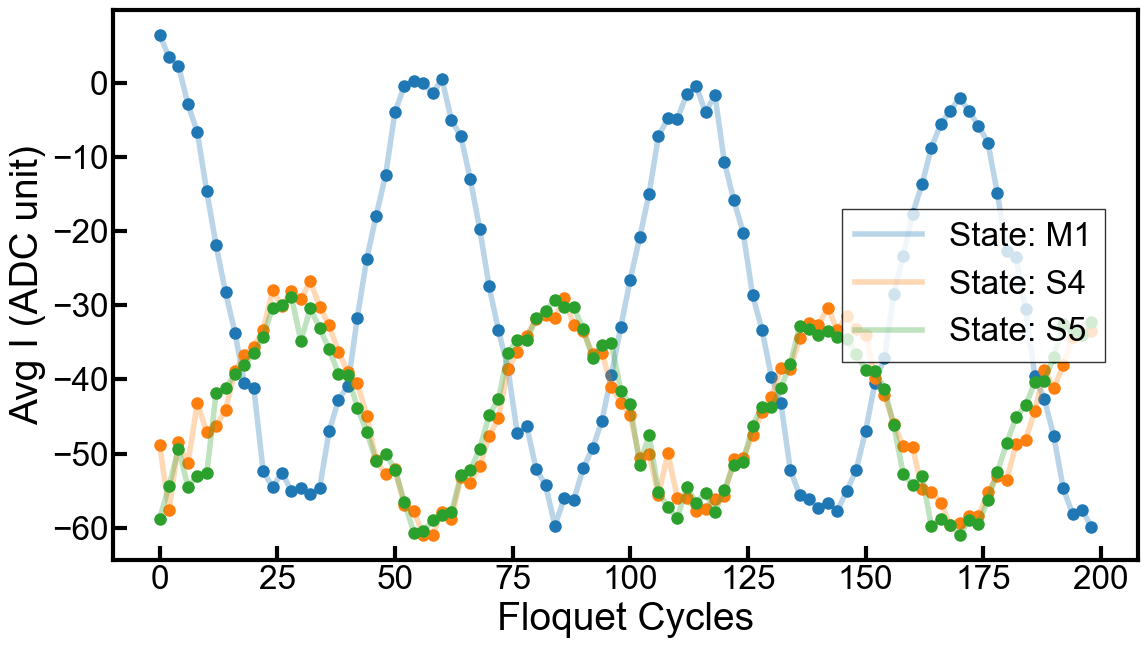

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.optimize import curve_fit

# fig, ax = plt.subplots(1, 2, figsize=(18, 12))
fig, ax = plt.subplots(figsize=(12, 7))
scatter = False
combined_data = defaultdict(lambda: {'xpts': [], 'avgi': [], 'avgq': []})

floquet_cycle2us = 0

plot_time = False
do_fitting = False   # set False to skip the sine fit / frequency extraction

for i in swap_stors:
    if station.ds_floquet.get_waveform(f"M1-S{i}") == 'gauss':
        floquet_cycle2us += float(station.ds_floquet.get_gauss_sigma(f"M1-S{i}")
                                  * station.ds_floquet.get_gauss_n_sigma(f"M1-S{i}"))
        floquet_cycle2us += station.soccfg.cycles2us(10)
    else:
        floquet_cycle2us += float(station.ds_floquet.get_len(f"M1-S{i}"))
        floquet_cycle2us += float(station.ds_floquet.get_ramp_sigma(f"M1-S{i}")) * 4
        floquet_cycle2us += station.soccfg.cycles2us(10)


# --- sine fit: y(t) = A*sin(2*pi*f*t + phi) + C ; f in MHz (t in us), omega=2*pi*f ---




# Build the deduped, flattened experiment list this cell iterates over.
# Uses its own name so it never collides with the unique_expts() helper
# function defined elsewhere in this section.


for expt in exp_list:
    state_idx = expt.cfg.expt.ro_stor

    combined_data[state_idx]['xpts'].extend(expt.data['xpts'])
    combined_data[state_idx]['avgi'].extend(expt.data['avgi'])
    combined_data[state_idx]['avgq'].extend(expt.data['avgq'])

sine_fits = {}  # {label: {'I': {...}, 'Q': {...}}}

for state_idx, data in combined_data.items():
    sort_indices = np.argsort(data['xpts'])
    x_sorted = np.array(data['xpts'])[sort_indices]  # * floquet_cycle2us # comment out if you don't want to convert cycle into time.
    if plot_time:
        x_sorted = np.array(data['xpts'])[sort_indices] * floquet_cycle2us
    i_sorted = np.array(data['avgi'])[sort_indices]
    q_sorted = np.array(data['avgq'])[sort_indices]

    display_idx = state_idx
    state_prefix = "S"
    if display_idx == 0:
        state_prefix = "M"
        display_idx = 1
    if swap_man_dark == False:
        label_str = f"State: {state_prefix}{display_idx}"
    else:
        # print("True")
        if state_idx == 0:
            label_str = "Dark Mode"
        elif state_idx == dark_swap_order[1]:
            label_str = "Bright Mode"
        else:
            label_str = "Central Mode"
    line_i, = ax.plot(x_sorted, i_sorted, linestyle='-', linewidth=4.0, alpha=0.3, label=label_str)
    # line_q, = ax[1].plot(x_sorted, q_sorted, linestyle='-', linewidth=4.0, alpha=0.3, label=label_str)
    
    ax.plot(x_sorted, i_sorted, marker='o', linestyle='None', markersize=8, alpha=1.0, color=line_i.get_color())
    # ax[1].plot(x_sorted, q_sorted, marker='o', linestyle='None', markersize=8, alpha=1.0, color=line_q.get_color())

    # Only fit vs real time -- frequency in MHz / omega in Mrad/s are meaningful then.
    if plot_time and do_fitting:
        this = {}
        t_dense = np.linspace(np.min(x_sorted), np.max(x_sorted), 500)
        for chan, y_sorted, a in (("I", i_sorted, ax[0]), ("Q", q_sorted, ax[1])):
            fit = fit_sine(x_sorted, y_sorted)
            this[chan] = fit
            if fit is not None:
                a.plot(t_dense, _sine(t_dense, *fit['popt']), "k--", alpha=0.6,
                       label=f"{label_str} fit: f={fit['f']:.4f} MHz, "
                             f"$\\omega$={fit['omega']:.4f} Mrad/s")
        sine_fits[label_str] = this

if plot_time:
    ax.set_xlabel("time (us)")
    # ax[1].set_xlabel("time (us)")
else:
    ax.set_xlabel("Floquet Cycles")
    # ax[1].set_xlabel("Floquet Cycles")

ax.set_ylabel("Avg I (ADC unit)")
# ax[1].set_ylabel("Avg Q (ADC unit)")
ax.legend(loc = "right")
# ax.set_ylim([-60, -10])
# ax[1].legend()
plt.tight_layout()
plt.show()

# --- report extracted frequency / angular frequency (time-domain fits only) ---
if plot_time and do_fitting:
    print("Sine-fit results (t in us  ->  f in MHz, omega in Mrad/s):")
    for label, chans in sine_fits.items():
        for chan in ("I", "Q"):
            fit = chans.get(chan)
            if fit is None:
                print(f"  {label} [{chan}]: fit failed")
            else:
                print(f"  {label} [{chan}]: f = {fit['f']:.6f} MHz, "
                      f"omega = {fit['omega']:.6f} Mrad/s, "
                      f"A = {fit['A']:.3g}, phi = {fit['phi']:.3f} rad")

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

combined_data = defaultdict(lambda: {'xpts': [], 'avgi': [], 'avgq': []})

unique_expts = []
for expt in exp_list:
    if expt not in unique_expts:
        unique_expts.append(expt)

for expt in unique_expts:
    detune_idx = np.max(np.abs(expt.cfg.expt.detunings))

    combined_data[detune_idx]['xpts'].append(np.asarray(expt.data['xpts']))
    combined_data[detune_idx]['avgi'].append(np.asarray(expt.data['avgi']))
    combined_data[detune_idx]['avgq'].append(np.asarray(expt.data['avgq']))

averaged_data = {}

for detune_idx, data in combined_data.items():
    x_stack = np.stack(data['xpts'], axis=0)
    i_stack = np.stack(data['avgi'], axis=0)
    q_stack = np.stack(data['avgq'], axis=0)

    averaged_data[detune_idx] = {
        'xpts': np.mean(x_stack, axis=0),
        'avgi': np.mean(i_stack, axis=0),
        'avgq': np.mean(q_stack, axis=0),
    }

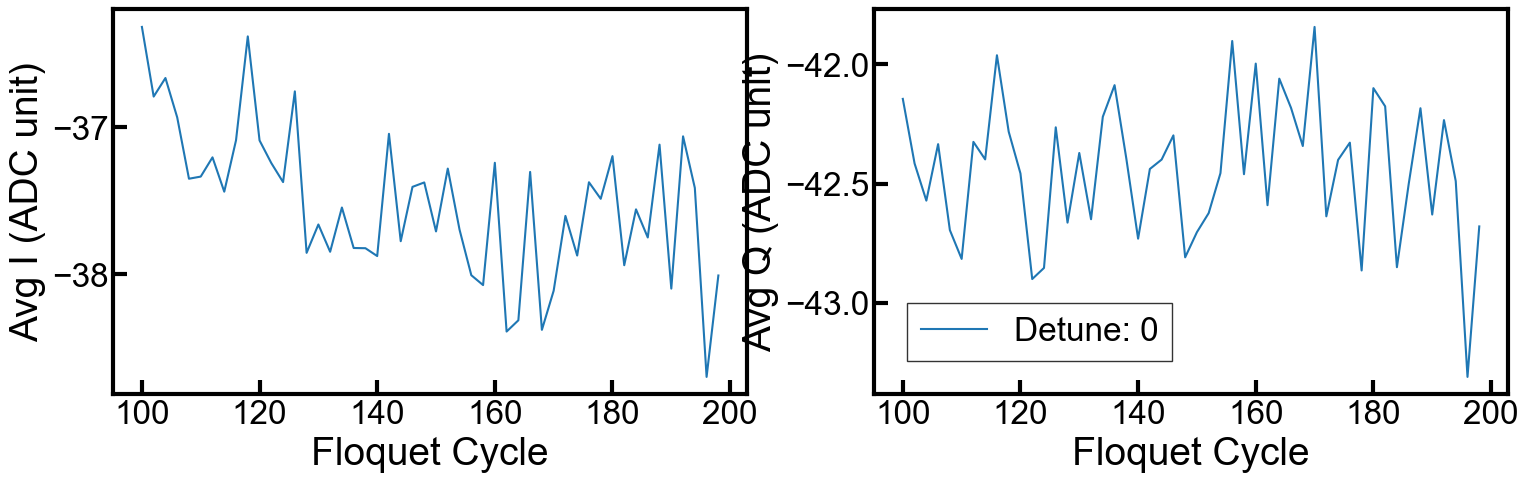

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(18, 5))

for detune_idx, data in averaged_data.items():
    sort_indices = np.argsort(data['xpts'])

    x_sorted = data['xpts'][sort_indices]
    i_sorted = data['avgi'][sort_indices]
    q_sorted = data['avgq'][sort_indices]

    label_str = f"Detune: {detune_idx}"

    ax[0].plot(x_sorted, i_sorted, label=label_str)
    ax[1].plot(x_sorted, q_sorted, label=label_str)

ax[0].set_xlabel("Floquet Cycle")
ax[1].set_xlabel("Floquet Cycle")
ax[0].set_ylabel("Avg I (ADC unit)")
ax[1].set_ylabel("Avg Q (ADC unit)")
# ax[0].legend()
ax[1].legend()

plt.show()

In [44]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

items = sorted(averaged_data.items(), key=lambda kv: kv[0])
detunes = np.array([k for k, _ in items], dtype=float)

positive_detunes = detunes[detunes > 0]
norm = mcolors.LogNorm(vmin=positive_detunes.min(), vmax=positive_detunes.max())
cmap = cm.turbo

fig, ax = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)

for detune_idx, data in items:
    sort_indices = np.argsort(data['xpts'])

    x_sorted = data['xpts'][sort_indices]
    i_sorted = data['avgi'][sort_indices]
    q_sorted = data['avgq'][sort_indices]

    if detune_idx == 0:
        color = "black"
        linestyle = "--"
        linewidth = 2.5
        alpha = 1.0
        label = "Detune: 0"
    else:
        color = cmap(norm(detune_idx))
        linestyle = "-"
        linewidth = 2.0
        alpha = 0.9
        label = None

    ax[0].plot(x_sorted, i_sorted, color=color, lw=linewidth, ls=linestyle, alpha=alpha, label=label)
    ax[1].plot(x_sorted, q_sorted, color=color, lw=linewidth, ls=linestyle, alpha=alpha, label=label)

ax[0].set_xlabel("Floquet Cycle")
ax[1].set_xlabel("Floquet Cycle")
ax[0].set_ylabel("Avg I (ADC unit)")
ax[1].set_ylabel("Avg Q (ADC unit)")

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Detune")

for a in ax:
    a.grid(alpha=0.25)
    a.legend()

plt.show()

ValueError: zero-size array to reduction operation minimum which has no identity

In [ ]:
cycle_to_time_us = 0.687521

fig, ax = plt.subplots(1,2, figsize=(18, 5))
data = combined_data[0]
sort_indices = np.argsort(data['xpts'])
x_sorted = np.array(data['xpts'])[sort_indices] * cycle_to_time_us
i_sorted = np.array(data['avgi'])[sort_indices]

data_1 = combined_data[2]
data_2 = combined_data[3]
i_sorted1 = np.array(data_1['avgi'])[sort_indices]
i_sorted2 = np.array(data_2['avgi'])[sort_indices]
i_sorted_sum = i_sorted1 + i_sorted2
ax[0].plot(x_sorted, i_sorted, label="Dark 1 number")
ax[1].plot(x_sorted, i_sorted_sum, label="Dark 0 number + Man 1 number")

ax[0].set_xlabel("Time (us)")
ax[1].set_xlabel("Time (us)")
ax[0].set_ylabel("Avg I (ADC unit)")
ax[1].set_ylabel("Avg I (ADC unit)")
ax[0].legend()
ax[1].legend()
# ax[0].set_xlim([0, 100])
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

fig, ax = plt.subplots(1, 2, figsize=(18, 5))


for state_idx, data in combined_data.items():
    sort_indices = np.argsort(data['xpts'])
    x_sorted = np.array(data['xpts'])[sort_indices] * cycle_to_time_us
    i_sorted = np.array(data['avgi'])[sort_indices]
    q_sorted = np.array(data['avgq'])[sort_indices]

    display_idx = state_idx
    if display_idx == 0:
        label_str = f"State: Dark 1"
    elif display_idx == 2:
        label_str = f"State: Man"
    elif display_idx == 3:
        label_str = f"State: Dark 2"
        
    
    ax[0].plot(x_sorted, i_sorted, label=label_str)
data = combined_data[0]
sort_indices = np.argsort(data['xpts'])
i_sorted = np.array(data['avgi'])[sort_indices]
ax[1].plot(x_sorted, i_sorted, label="Dark 1 number")
ax[1].plot(x_sorted, i_sorted_sum+80, label="Dark 0 + Man 1 number (added 80 for comparison)")

ax[0].set_xlabel("Floquet Cycle")
ax[1].set_xlabel("Floquet Cycle")
ax[0].set_ylabel("Avg I (ADC unit)")
ax[1].set_ylabel("Avg I (ADC unit)")
ax[0].legend()
ax[1].legend()
# ax[0].set_xlim([0, 100])
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from lmfit import Model



fig, ax = plt.subplots(1, 2, figsize=(18, 5))

for state_idx, data in combined_data.items():
    sort_indices = np.argsort(data['xpts'])
    x_sorted = np.array(data['xpts'])[sort_indices] * cycle_to_time_us
    i_sorted = np.array(data['avgi'])[sort_indices]
    q_sorted = np.array(data['avgq'])[sort_indices]

    display_idx = state_idx
    if display_idx == 0:
        label_str = f"State: Dark 2"
    elif display_idx == 2:
        label_str = f"State: Man"
    elif display_idx == 3:
        label_str = f"State: Dark 1"
        
    ax[0].plot(x_sorted, i_sorted, label=label_str)

data = combined_data[0]
sort_indices = np.argsort(data['xpts'])
x_sorted = np.array(data['xpts'])[sort_indices] * cycle_to_time_us
i_sorted = np.array(data['avgi'])[sort_indices]

y_sum = np.array(i_sorted_sum)[sort_indices] + 80

dark1_fit = fit_t1(x_sorted, i_sorted)
sum_fit = fit_t1(x_sorted, y_sum)

x_fit = np.linspace(np.min(x_sorted), np.max(x_sorted), 1000)

dark1_t1 = dark1_fit.params['tau'].value
sum_t1 = sum_fit.params['tau'].value

ax[1].plot(x_sorted, i_sorted, label="Dark 2 number")
ax[1].plot(x_fit, dark1_fit.eval(x=x_fit), '--')

ax[1].plot(x_sorted, y_sum, label="Dark 1 + Man 1 number (added 80 for comparison)")
ax[1].plot(x_fit, sum_fit.eval(x=x_fit), '--')

ax[0].set_xlabel("Time (us)")
ax[1].set_xlabel("Time (us)")
ax[0].set_ylabel("Avg I (ADC unit)")
ax[1].set_ylabel("Avg I (ADC unit)")
ax[0].legend()
ax[1].legend()
fig.suptitle(f"State initialized to S2 = D2-D1")
# ax[0].set_xlim([0, 100])
plt.show()


## Disorder-dependent decay

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (18, 5))

for scramble_expt in exp_list:
    state_idx = scramble_expt.cfg.expt.ro_stor
    detuning = np.max(scramble_expt.cfg.expt.detunings)
    print(detuning)
    state_prefix = "S"
    if state_idx == 0:
        state_prefix = "M"
        state_idx = 1
    ax[0].plot(scramble_expt.data['xpts'], scramble_expt.data['avgi'], label = F"State: {state_prefix}{state_idx}")
    ax[1].plot(scramble_expt.data['xpts'], scramble_expt.data['avgq'], label = F"State: {state_prefix}{state_idx}")
ax[0].set_xlabel("Floquet Cycle")
ax[1].set_xlabel("Floquet Cycle")
ax[0].set_ylabel("Avg I (ADC unit)")
ax[1].set_ylabel("Avg Q (ADC unit)")
# ax[0].legend()
# ax[1].legend()

# Multiphoton Fock Post Processing

Post-processing for the `Multi photon fock` subsection of
`qsim_experiments.ipynb`. Every section below reconstructs the relevant
`DarkBaseExperiment` multiparity data from `*.h5`, builds the per-readout
modulo-4 observables from the single-shot data, and applies the readout
confusion-matrix correction.

The confusion matrix and all helper functions are defined **once** in the
"Shared definitions" cells right below; the calibration cell can optionally
recompute the matrix from data. Every experiment section after that is just a
load cell plus a process-and-plot cell.

## Shared definitions (confusion matrix + multiparity helpers)

In [112]:
# ---- Multiparity helper functions (shared by every section below) -----------
import matplotlib.pyplot as plt
import textwrap

# n_mod4 = b0 + 2*b1, with b0 = n % 2 (first parity), b1 = n // 2 (second parity).
# parity expectation = +1 for bit 0, -1 for bit 1  (i.e. 1 - 2*bit).


from collections import namedtuple

# Single source of truth for a dataset's dark-readout config. These values live
# in each experiment's cfg.expt, so we read them from the experiments themselves
# instead of re-declaring them by hand -- post-processing then always matches the
# data it is plotting.

# Module-level "current" dark params, set as a side effect of get_dark_params() so
# label/plot helpers can fall back to the most recently loaded dataset.

# ---- Multiparity plot labels + line statistics override --------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import textwrap
from collections import namedtuple

MULTIPARITY_SHOW_LINE_STATS = True     # std/mean 표시 on/off
MULTIPARITY_STATS_FOR = "corrected"    # "corrected", "raw", "both"
MULTIPARITY_USE_DARK_LABELS = True     # large DM에서 끄고 싶으면 False

try:
    DarkParams
except NameError:
    DarkParams = namedtuple("DarkParams", ["swap_stors", "swap_man_dark", "dark_swap_order"])
    DARK_PARAMS = None

def _cfg_get(obj, key, default=None):
    if hasattr(obj, "get"):
        return obj.get(key, default)
    return getattr(obj, key, default)

def _as_tuple(x):
    if x is None:
        return tuple()
    if isinstance(x, np.ndarray):
        x = x.tolist()
    if isinstance(x, (list, tuple)):
        return tuple(x)
    return (x,)

def _flatten_expts(items):
    if items is None:
        return []
    out = []
    for x in items:
        if isinstance(x, (list, tuple, set)):
            out.extend(_flatten_expts(x))
        else:
            out.append(x)
    return out

def get_dark_params(expts):
    global DARK_PARAMS

    flat = _flatten_expts(expts)
    if len(flat) == 0:
        DARK_PARAMS = None
        return None

    def one(exp):
        c = exp.cfg.expt
        return DarkParams(
            _as_tuple(_cfg_get(c, "swap_stors", [])),
            bool(_cfg_get(c, "swap_man_dark", False)),
            _as_tuple(_cfg_get(c, "dark_swap_order", [])),
        )

    params = one(flat[0])
    for exp in flat:
        if one(exp) != params:
            raise Exception("Exps are not identical in swap_stors/swap_man_dark/dark_swap_order")

    DARK_PARAMS = params
    return params

def stor_label(ro_stor, params=None):
    ro_stor = int(ro_stor)

    if params is None:
        params = DARK_PARAMS

    if (not MULTIPARITY_USE_DARK_LABELS) or params is None or not params.swap_man_dark:
        return "M1" if ro_stor == 0 else f"S{ro_stor}"

    dark_order = list(params.dark_swap_order)

    if ro_stor == 0:
        return "Dark Mode"
    if len(dark_order) > 1 and ro_stor == int(dark_order[1]):
        return "Bright Mode"
    if len(dark_order) > 0 and ro_stor == int(dark_order[0]):
        return "Central Mode"

    return f"S{ro_stor}"

def _std_over_mean_text(y):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]

    if y.size == 0:
        return r"$\sigma/|\mu|$=nan"

    mu = np.mean(y)
    sig = np.std(y)

    if np.isclose(mu, 0.0):
        return r"$\sigma/|\mu|$=inf"

    return rf"$\sigma/|\mu|$={sig / abs(mu):.3g}"

def _line_label(label, y, kind):
    if not MULTIPARITY_SHOW_LINE_STATS:
        return str(label)
    if MULTIPARITY_STATS_FOR not in ("both", kind):
        return str(label)
    return f"{label} ({_std_over_mean_text(y)})"

def _raw_label(label, y):
    if MULTIPARITY_SHOW_LINE_STATS and MULTIPARITY_STATS_FOR in ("raw", "both"):
        return _line_label(f"{label} raw", y, "raw")
    return None

def plot_thick_line_with_dots(ax, x, y, label=None, color=None, stats_kind="corrected"):
    if label is not None:
        label = _line_label(label, y, stats_kind)

    line, = ax.plot(x, y, linestyle="-", linewidth=4.0, alpha=0.3,
                    label=label, color=color)
    col = line.get_color()
    ax.plot(x, y, marker="o", linestyle="None", markersize=8,
            alpha=1.0, color=col)
    return col

def plot_nmod4_corrected(corrected, params=None, title="", figsize=(9, 7),
                         title_size=12, custom_labels=None):
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    idx = 0

    for ro_stor in corrected:
        x = corrected[ro_stor]["xpts"]
        y = corrected[ro_stor]["nmod4_mean"]

        if custom_labels is None:
            lbl = stor_label(ro_stor, params)
        else:
            lbl = custom_labels[idx]
            idx += 1

        plot_thick_line_with_dots(ax, x, y, label=lbl)

    ax.set_xlabel("Floquet cycle")
    ax.set_ylabel(r"$\langle n\ mod\ 4\rangle$")
    ax.legend()

    if title:
        ax.set_title(textwrap.fill(str(title), 60), fontsize=title_size)

    plt.tight_layout()
    plt.show()

def plot_multiparity(raw, corrected, params=None, title="", figsize=(20, 5), title_size=12):
    fig, ax = plt.subplots(1, 3, figsize=figsize)

    keys = [
        ("nmod4_mean", r"$\langle n\ mod\ 4\rangle$", "(dashed=raw, solid=corrected)"),
        ("mean_parity_first", "parity value", "First parity expectation"),
        ("mean_parity_second", "parity value", "Second parity expectation"),
    ]

    for ro_stor in corrected:
        x = corrected[ro_stor]["xpts"]
        lbl = stor_label(ro_stor, params)

        for i, (key, _, _) in enumerate(keys):
            y_corr = corrected[ro_stor][key]
            y_raw = raw[ro_stor][key]

            col = plot_thick_line_with_dots(ax[i], x, y_corr, label=lbl)
            ax[i].plot(x, y_raw, "--", alpha=0.4, color=col,
                       label=_raw_label(lbl, y_raw))

    for i, (_, ylabel, title_i) in enumerate(keys):
        ax[i].set_title(title_i)
        ax[i].set_xlabel("Floquet cycle")
        ax[i].set_ylabel(ylabel)
        ax[i].axhline(0, color="k", linewidth=0.8, alpha=0.4)
        ax[i].grid(alpha=0.25)
        ax[i].legend(fontsize=10)

    ax[1].set_ylim(-1.05, 1.05)
    ax[2].set_ylim(-1.05, 1.05)

    if title:
        fig.suptitle(textwrap.fill(str(title), 60), fontsize=title_size)

    plt.tight_layout()
    plt.show()






import matplotlib.pyplot as plt
import textwrap

import matplotlib.gridspec as gridspec




import matplotlib.pyplot as plt
import textwrap



    

## Multi photon fock - confusion matrix from calibration (optional)

Mirrors the `Multi photon fock` calibration: load the Fock |0>,|1>,|2>,|3>
preparation runs (`init_man_fock_state` = 0..3, `ro_stor = 0`, single floquet
point) and build the confusion matrix from their single-shot data. Running this
cell **overrides** the manual matrix above; skip it to keep the manual one.

In [113]:
# Set this to the job range of your Fock |0>..|3> calibration runs.
cal_expts = load_dark_experiments("260526_qsim_darkmode", [20260625], [280], [283])
# cal_expts = load_dark_experiments("260526_qsim_darkmode", [20260702], [356], [359])

print("loaded", len(cal_expts), "calibration experiments")


    

  0%|          | 0/4 [00:00<?, ?it/s]

loaded 4 calibration experiments


In [114]:


# Support both: compute from calibration data if it covers all four Fock states,
# otherwise keep the manually-entered matrix.
_counts = build_confusion_matrix_from_calibration(cal_expts)
if np.all(_counts.sum(axis=1) > 0):
    set_confusion_matrix(_counts)
    print("Confusion matrix computed from calibration data:")
else:
    set_confusion_matrix(confusion_matrix_manual)
    print("Calibration incomplete; using the manually-entered confusion matrix:")
print(np.round(confusion_matrix, 4))

Confusion matrix computed from calibration data:
[[0.7238 0.0858 0.109  0.0815]
 [0.0488 0.7398 0.061  0.1505]
 [0.0735 0.09   0.7288 0.1078]
 [0.0432 0.116  0.069  0.7718]]


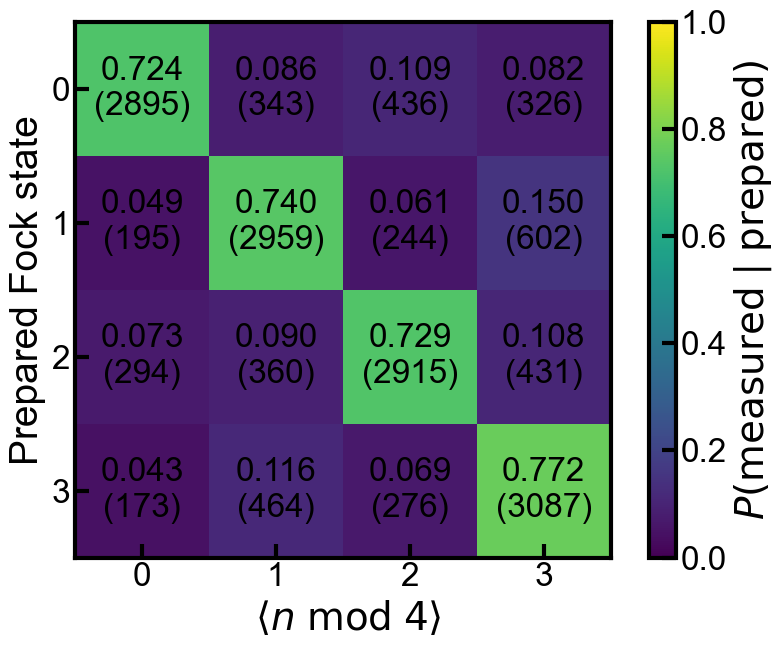

In [115]:
probs = _counts / _counts.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(probs, vmin=0, vmax=1)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(["0", "1", "2", "3"]); ax.set_yticklabels(["0", "1", "2", "3"])
ax.set_xlabel(r" $\langle n \;\mathrm{mod}\; 4\rangle$")
ax.set_ylabel("Prepared Fock state")
# wrapped_title = textwrap.fill(str(fname_list), width=60)
# ax.set_title(f"Modulo-4 readout confusion matrix {wrapped_title}")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{probs[i, j]:.3f}\n({int(_counts[i, j])})",
                ha="center", va="center")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$P(\mathrm{measured}\mid\mathrm{prepared})$")
fig.tight_layout()
plt.show()

## Floquet with Initial Costate and Multiparity Readout

In [139]:
# Set this to the job range of your Floquet-with-initial-costate run.
# fic_expts = load_dark_experiments("260526_qsim_darkmode", [20260625], [271], [273])
# fic_expts = load_dark_experiments("260526_qsim_darkmode", [20260625], [274], [276])
fic_expts = load_dark_experiments("260526_qsim_darkmode", [20260707], [429], [433])
len(fic_expts)

fic_params = get_dark_params(fic_expts)
swap_stors, swap_man_dark, dark_swap_order = fic_params

  0%|          | 0/3 [00:00<?, ?it/s]

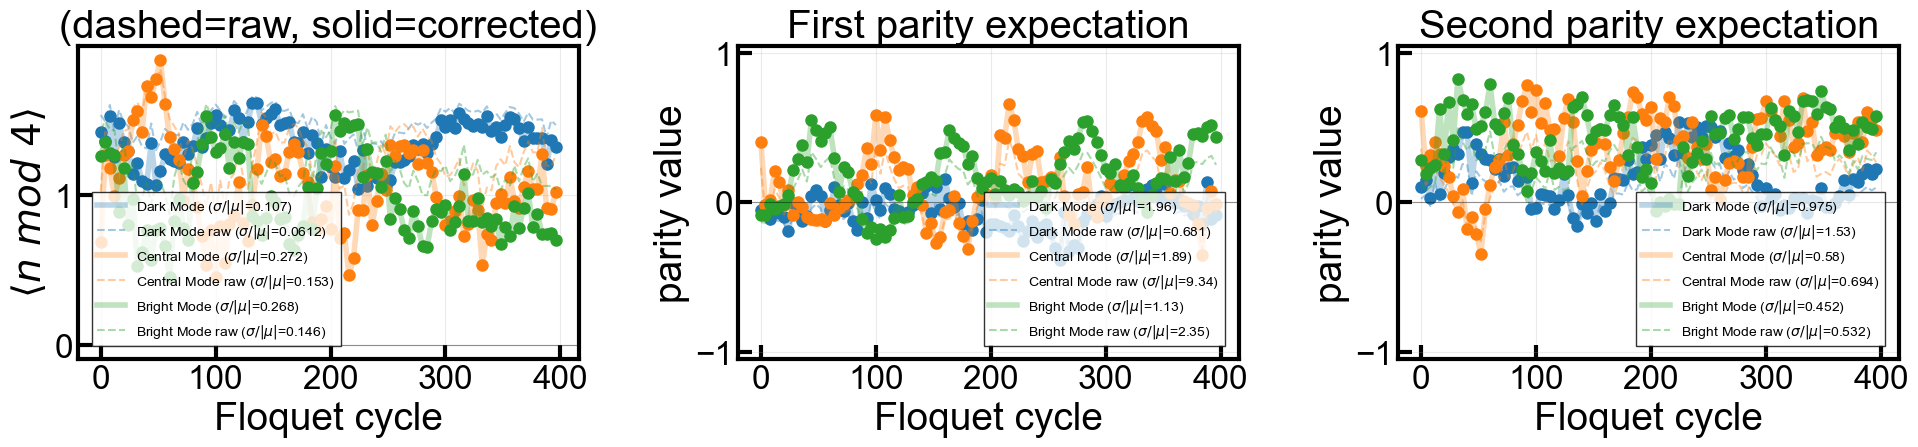

In [140]:
MULTIPARITY_STATS_FOR = "both"
MULTIPARITY_SHOW_LINE_STATS = True

fic_raw, fic_corr = process_multiparity(fic_expts)
fic_title = str([exp.config_file for exp in fic_expts])

plot_multiparity(fic_raw, fic_corr, fic_params)
# plot_nmod4_corrected(fic_corr, fic_params, title=" (confusion-corrected)")

### plot fluctuations

In [157]:
n_photons = [1, 2, 3]
fluctuations = {
    '40' : 
        {
            'n_mod_4' : 
                {
                    'raw': [0.0624, 0.0769, 0.115],
                    'corrected': [0.108, 0.123, 0.196]
                },
            'first_parity' : 
                {
                    'raw': [1.19, ],
                    'corrected': []
                },
            'second_parity' : 
                {
                    'raw': [],
                    'corrected': []
                },
        },
    '80' : 
        {
            'n_mod_4' : 
                {
                    'raw': [0.0369, 0.0305, 0.0423],
                    'corrected': [0.0635, 0.0457, 0.0629]
                },
            'first_parity' : 
                {
                    'raw': [1.19, ],
                    'corrected': []
                },
            'second_parity' : 
                {
                    'raw': [],
                    'corrected': []
                },
        },
    }

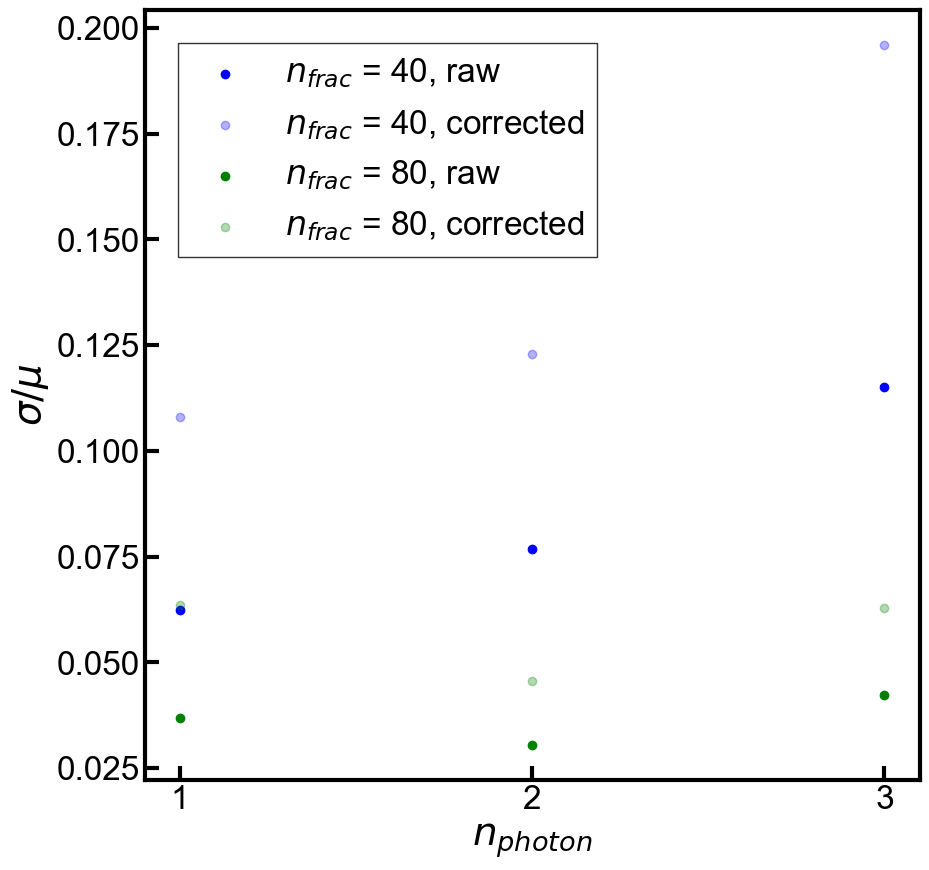

In [168]:
fig, ax = plt.subplots(figsize = (10, 10))
color_list = ['blue', 'green']
alpha_list = [1, 0.3]
for idx, keys in enumerate(['40', '80']):
    for data_idx, data_key in enumerate(['raw', 'corrected']):
        _color = color_list[idx] 
        ax.scatter(n_photons, 
                fluctuations[keys]['n_mod_4'][data_key],
                alpha = alpha_list[data_idx],
                color = _color,
                label = '$n_{frac}$'+f' = {keys}, {data_key}')
        
ax.set_xticks([1, 2, 3])
ax.set_ylabel("$\\sigma/\\mu$")
ax.set_xlabel("$n_{photon}$")
ax.legend()

## Large Support DM

### Bare

In [174]:
# "Bare" Large-Support-DM run (no dark-mode swap; meas_stors = [0, 2, 5, 6, 7]).
bare_expts = load_dark_experiments("260526_qsim_darkmode", [20260611], [1], [500])
len(bare_expts)

  0%|          | 0/112 [00:00<?, ?it/s]

112

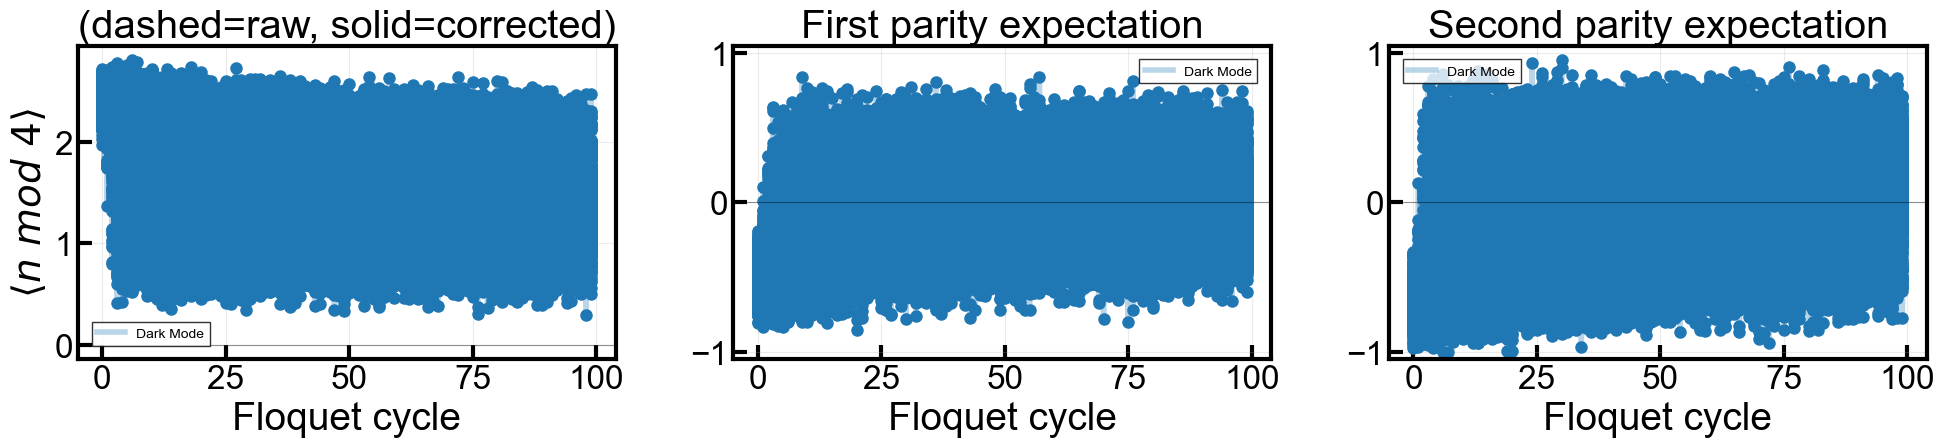

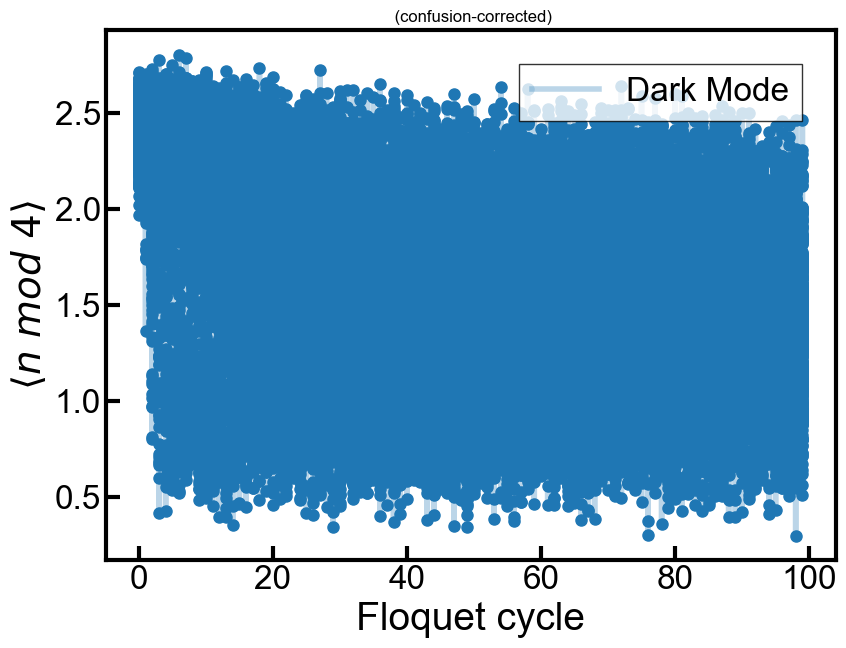

In [173]:
bare_raw, bare_corr = process_multiparity(bare_expts)
bare_title = str([exp.config_file for exp in bare_expts])
bare_params = get_dark_params(bare_expts)

plot_multiparity(bare_raw, bare_corr, bare_params,)
plot_nmod4_corrected(bare_corr, bare_params, " (confusion-corrected)")

### DM readout

In [19]:
# "DM readout" Large-Support-DM run (init_stor = 2, swap_man_dark = True).
dmro_expts = load_dark_experiments("260526_qsim_darkmode", [2026625], [0], [300])
len(dmro_expts)

0it [00:00, ?it/s]

0

In [41]:
dmro_raw, dmro_corr = process_multiparity(dmro_expts)
dmro_title = str([exp.config_file for exp in dmro_expts])
dmro_params = get_dark_params(dmro_expts)

plot_multiparity(dmro_raw, dmro_corr, dmro_params, title=dmro_title)
plot_nmod4_corrected(dmro_corr, dmro_params, title=dmro_title + " (confusion-corrected)")

IndexError: list index out of range

### DM load and readout

In [51]:
# "DM load and readout" multiparity run.
dmlr_expts = load_dark_experiments("260526_qsim_darkmode", [20260625], [202], [206], meas.qsim.qsim_base.QsimBaseExperiment)
len(dmlr_expts)

  0%|          | 0/5 [00:00<?, ?it/s]

5

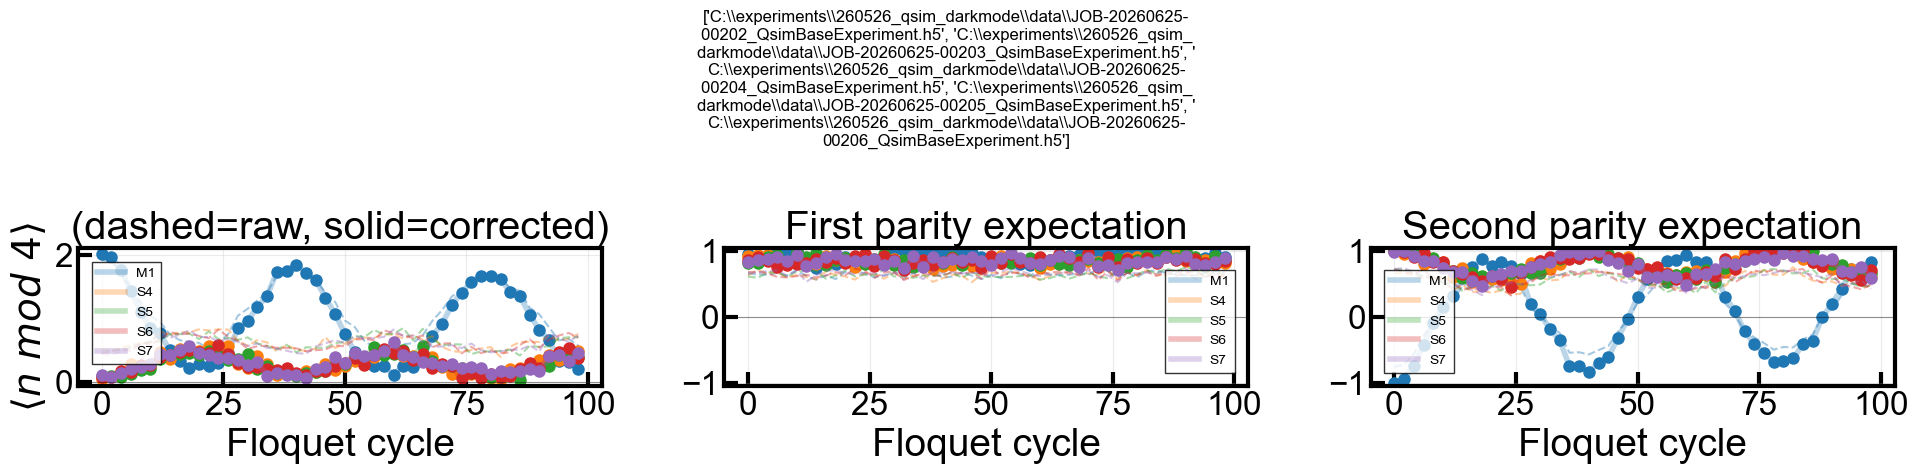

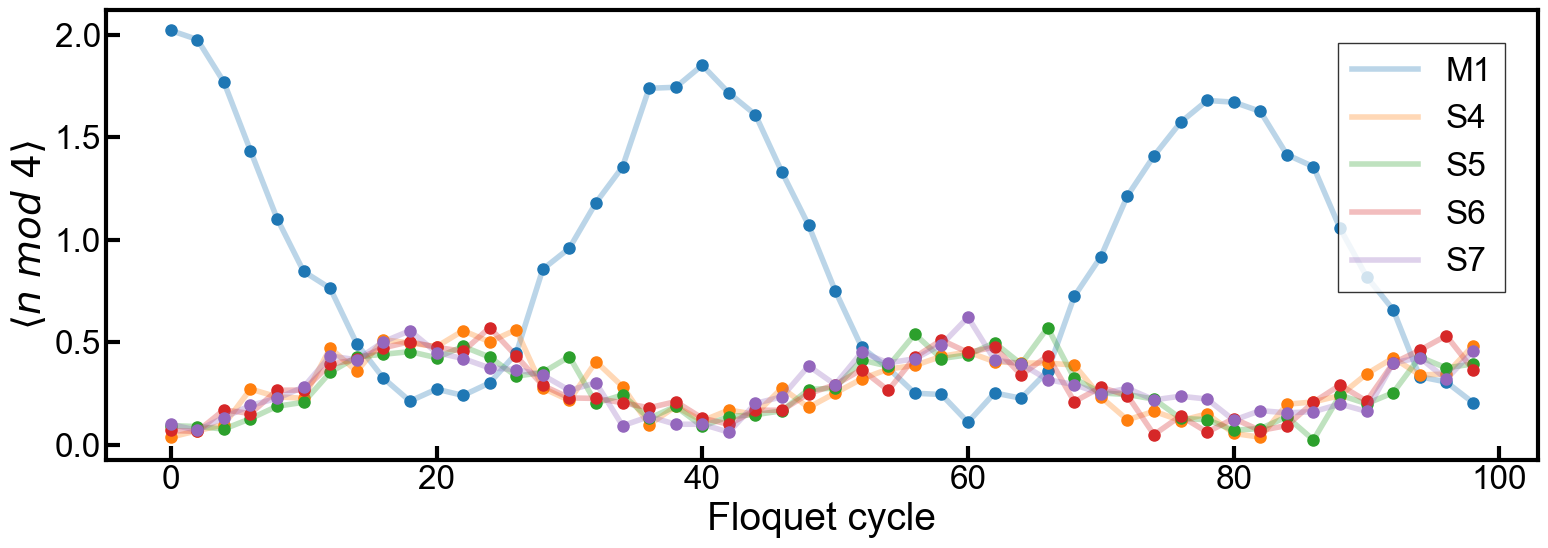

In [55]:
dmlr_raw, dmlr_corr = process_multiparity(dmlr_expts)
dmlr_title = str([exp.config_file for exp in dmlr_expts])
dmlr_params = get_dark_params(dmlr_expts)

plot_multiparity(dmlr_raw, dmlr_corr, dmlr_params, title=dmlr_title)
plot_nmod4_corrected(dmlr_corr, dmlr_params, figsize = (16, 6))

In [100]:
# "DM load and readout" multiparity run.
dmlr_expt_list = []
dmlr_expt_list.append(load_dark_experiments("260526_qsim_darkmode", [20260611], [14], [14]))
dmlr_expt_list.append(load_dark_experiments("260526_qsim_darkmode", [20260611], [15], [15]))
dmlr_expt_list.append(load_dark_experiments("260526_qsim_darkmode", [20260611], [16], [16]))
dmlr_expt_list.append(load_dark_experiments("260526_qsim_darkmode", [20260611], [17], [17]))
len(dmlr_expt_list)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

4

In [98]:
# "DM load and readout" multiparity run.
dmlr_expt_list = []
dmlr_expt_list.append(load_dark_experiments("260526_qsim_darkmode", [20260702], [378], [379]))
dmlr_expt_list.append(load_dark_experiments("260526_qsim_darkmode", [20260702], [380], [381]))
dmlr_expt_list.append(load_dark_experiments("260526_qsim_darkmode", [20260702], [382], [383]))
dmlr_expt_list.append(load_dark_experiments("260526_qsim_darkmode", [20260702], [384], [385]))
# dmlr_expts2 = load_dark_experiments("260526_qsim_darkmode", [20260611], [15], [15])
# dmlr_expts3 = load_dark_experiments("260526_qsim_darkmode", [20260611], [16], [16])
# dmlr_expts4 = load_dark_experiments("260526_qsim_darkmode", [20260611], [17], [17])
len(dmlr_expt_list)

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

4

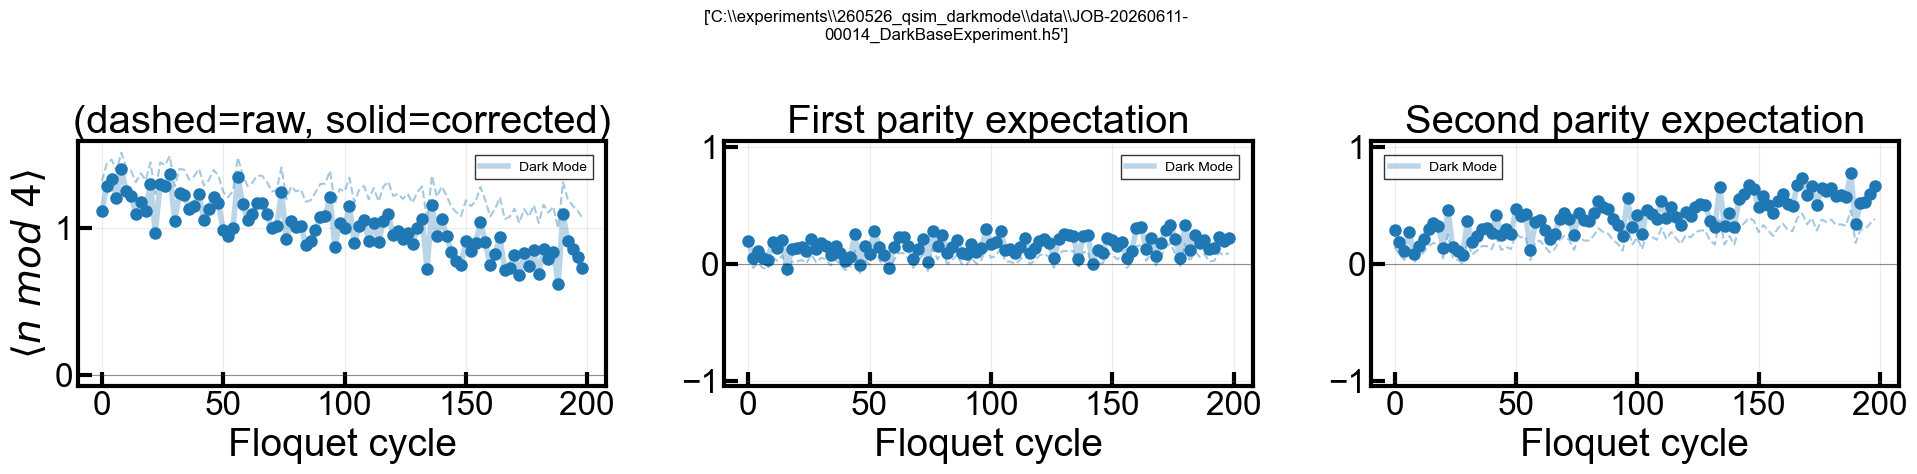

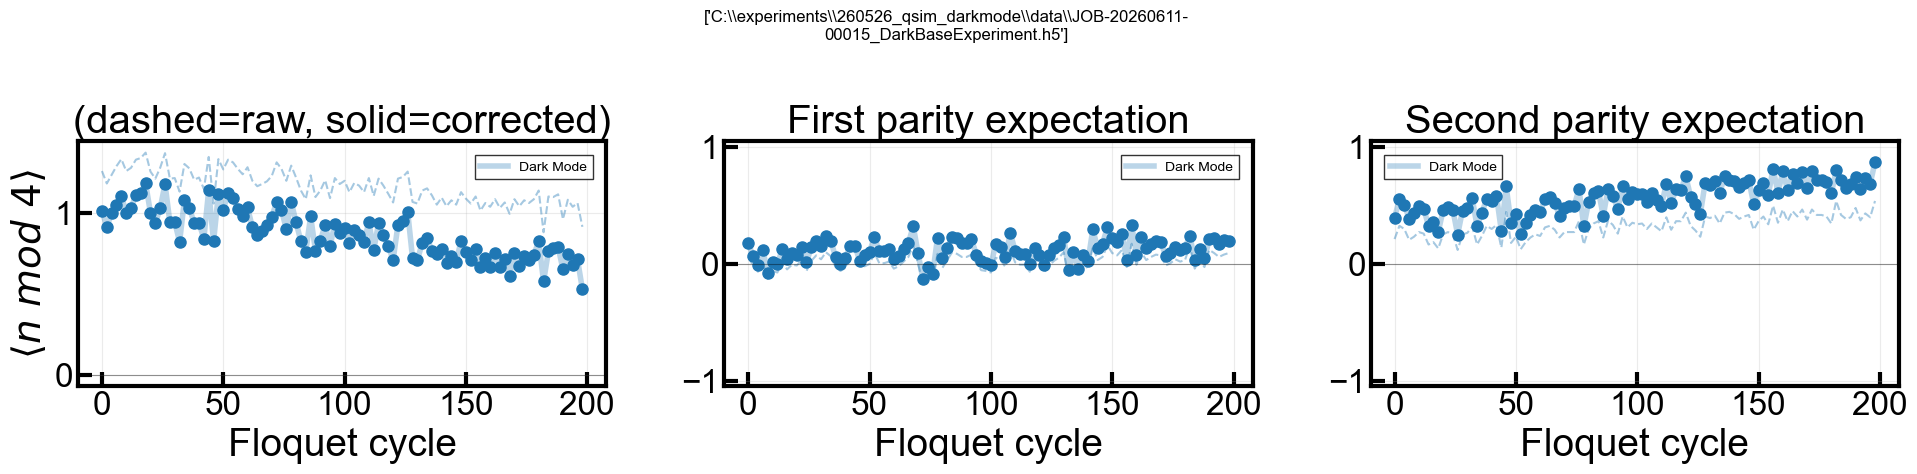

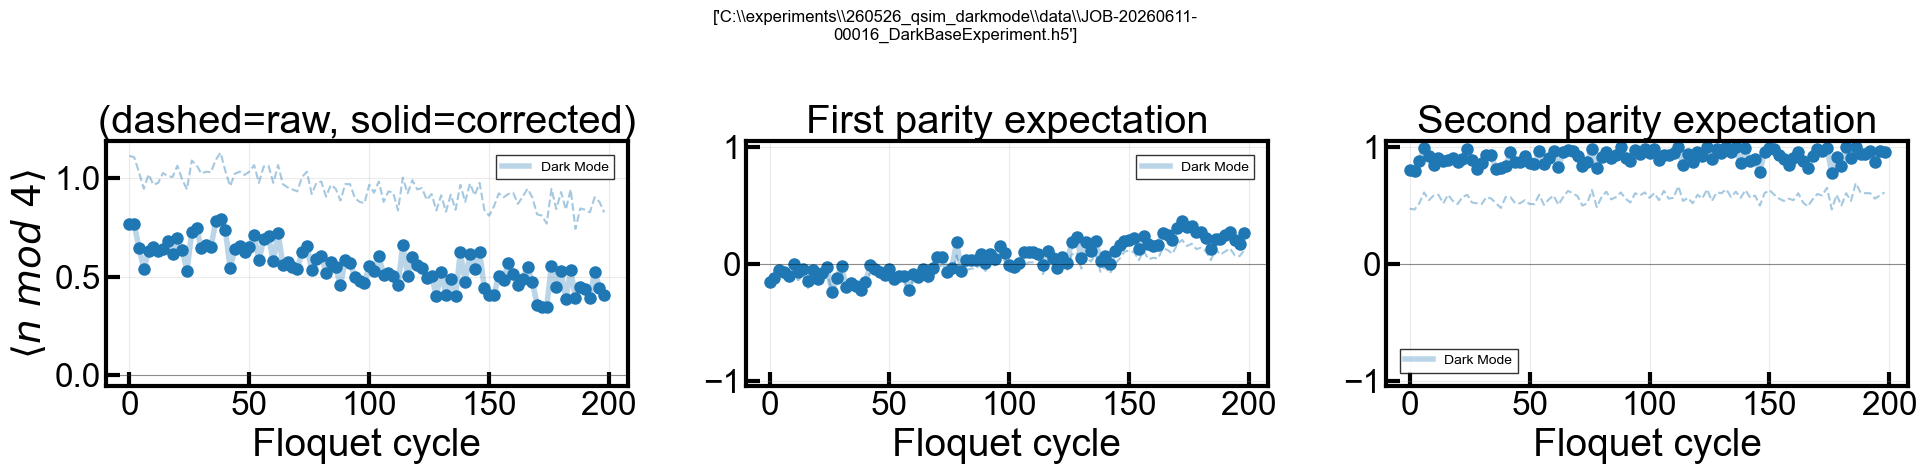

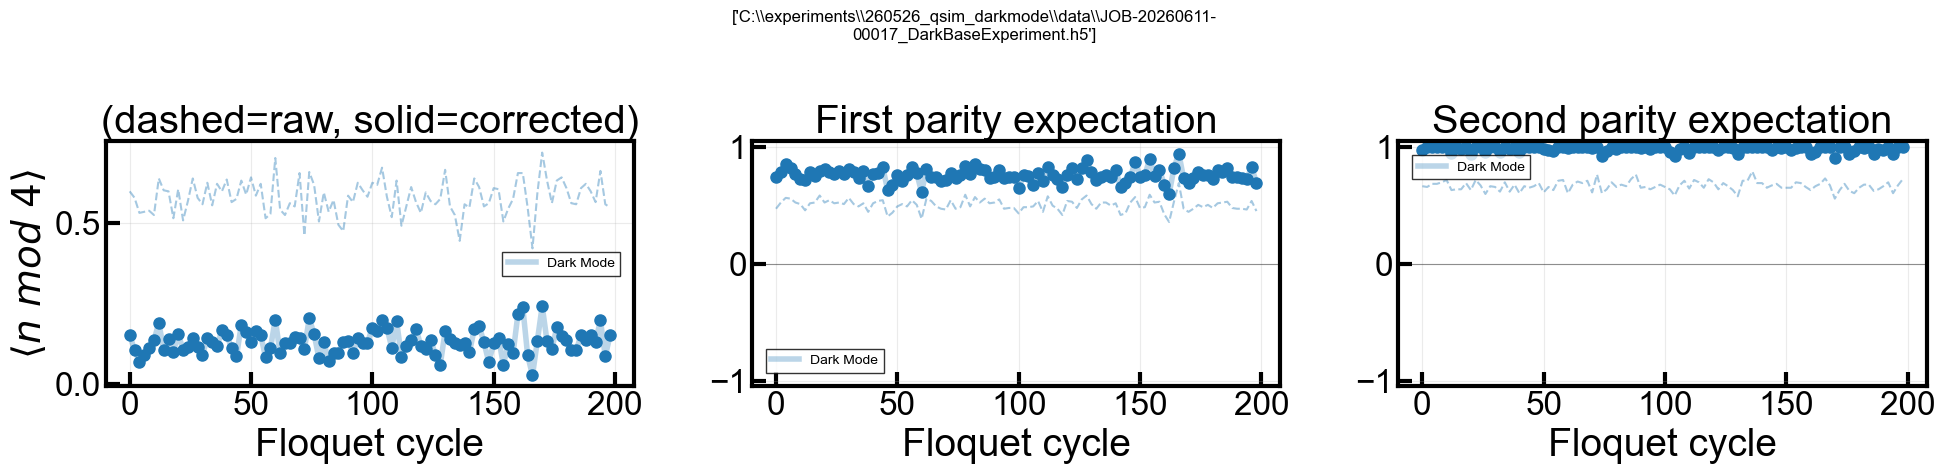

In [101]:
dmlr_corr_list = []
dmlr_params_list = []
for dmlr_expts in dmlr_expt_list:
    dmlr_raw, dmlr_corr = process_multiparity(dmlr_expts)
    dmlr_title = str([exp.config_file for exp in dmlr_expts])
    dmlr_params = get_dark_params(dmlr_expts)
    
    dmlr_corr_list.append(dmlr_corr)
    dmlr_params_list.append(dmlr_params)

    
    plot_multiparity(dmlr_raw, dmlr_corr, dmlr_params, title=dmlr_title)

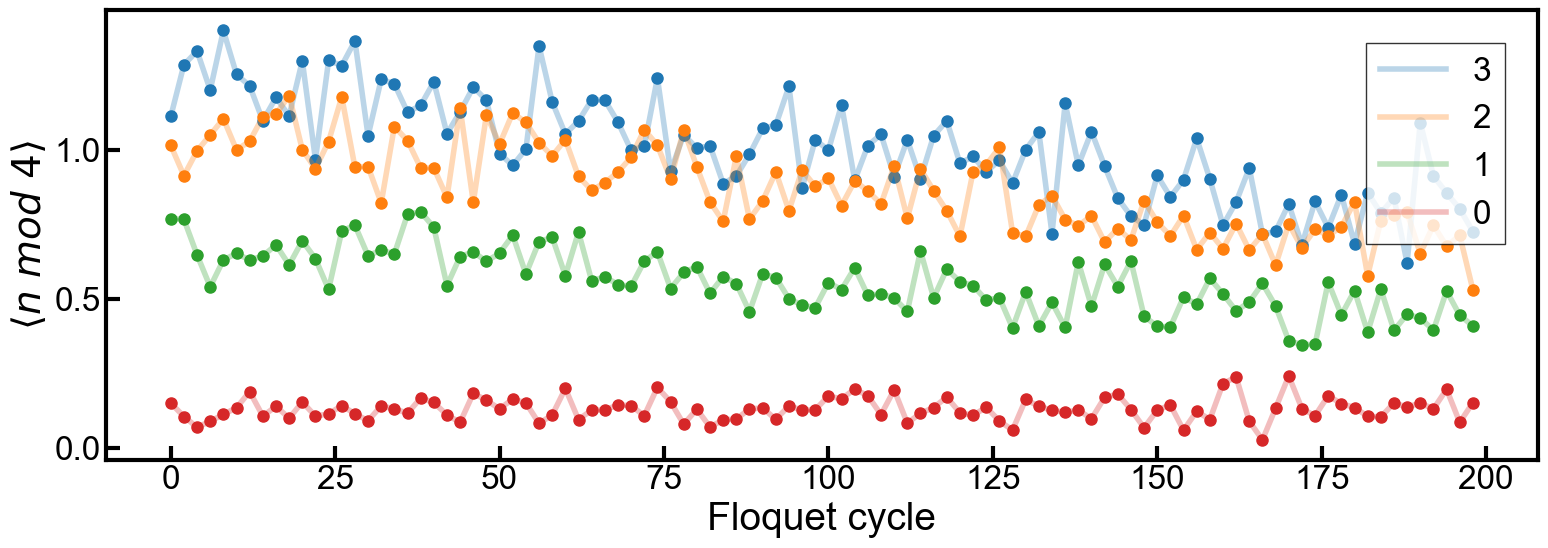

In [102]:
fig, ax = plt.subplots(1, 1, figsize=(16, 6))
idx = 0
lbl_list = [3, 2, 1, 0]
for idx, dmlr_corr in enumerate(dmlr_corr_list):
    x = dmlr_corr[0]["xpts"]
    plot_thick_line_with_dots(ax, x, dmlr_corr[0]["nmod4_mean"], label=lbl_list[idx])
    
ax.set_xlabel("Floquet cycle")
ax.set_ylabel("$\\langle n\\ mod\\ 4\\rangle$")
ax.legend(loc = "upper right")

    
plt.tight_layout()
plt.show()

## Large DM detuning dependent decay (disorder ensemble)

Reconstructs the disorder-realization ensemble purely from the saved `*.h5`
files. Each file carries its `disorder_epsilon` / `disorder_realization` in
`cfg.expt`, so the per-realization records (and their floquet-cycle chunks) are
regrouped automatically -- no execution code needed. Each realization is
confusion-corrected at the single-shot level (via `process_multiparity`), then
averaged over realizations to give the ensemble mean +/- SEM per disorder
strength.

In [ ]:
from collections import defaultdict
import textwrap








In [203]:
# Set this to the job range of your disorder sweep (DarkBaseExperiment files).
disorder_expts = load_dark_experiments("260526_qsim_darkmode", [20260704], [127], [487])
len(disorder_expts)

  0%|          | 0/361 [00:00<?, ?it/s]

361

In [204]:
disorder_records = reconstruct_disorder_records(disorder_expts)
disorder_summary = disorder_ensemble_summary(disorder_records, obs_key="nmod4_mean")
disorder_params = get_dark_params(disorder_expts)

# Quick look at how many realizations were found per disorder strength.
for eps in sorted(disorder_summary):
    for ro_stor, b in disorder_summary[eps].items():
        print(f"epsilon={eps:<6g} readout={stor_label(ro_stor, disorder_params):<3s} R={b['n']}")

epsilon=0      readout=Dark Mode R=1
epsilon=0.000309 readout=Dark Mode R=40
epsilon=0.000618 readout=Dark Mode R=40
epsilon=0.001545 readout=Dark Mode R=40
epsilon=0.00309 readout=Dark Mode R=40
epsilon=0.00618 readout=Dark Mode R=40
epsilon=0.01545 readout=Dark Mode R=40
epsilon=0.0309 readout=Dark Mode R=40
epsilon=0.1545 readout=Dark Mode R=40
epsilon=0.309  readout=Dark Mode R=40


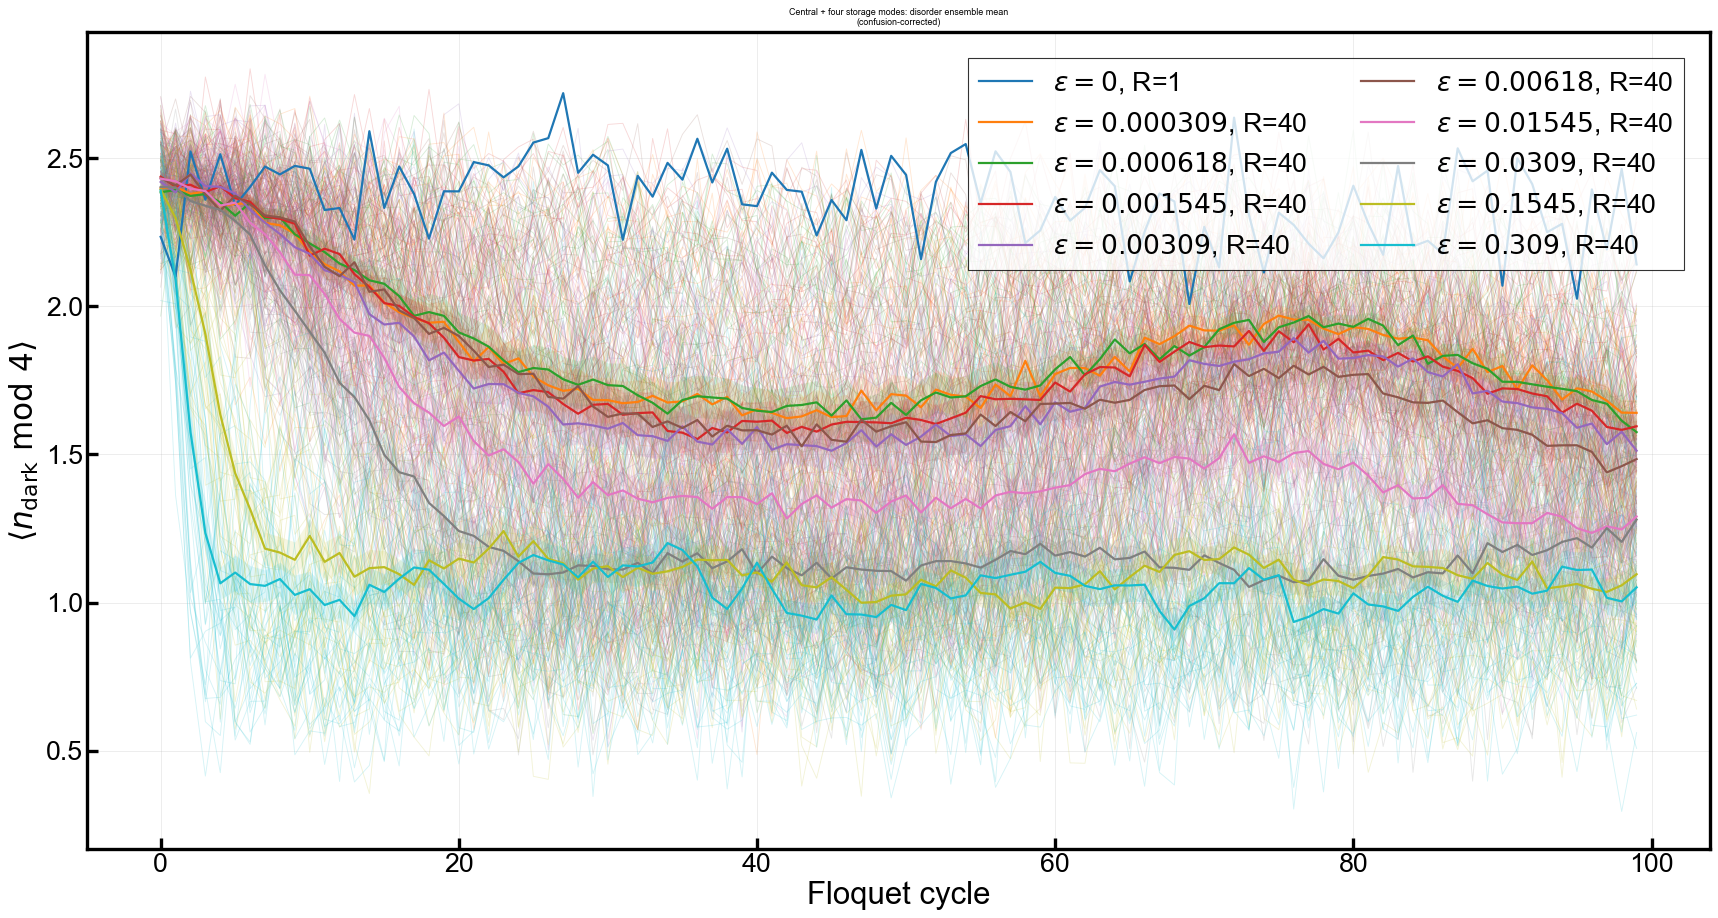

In [206]:
disorder_title = "Central + four storage modes: disorder ensemble mean"
ensemble_figsize = (22, 12)  # keep this ratio if you only want the whole image smaller
ensemble_dpi = 80           # lower dpi shrinks the rendered notebook image without changing relative style
ensemble_legend_fontsize = None  # None -> use mpl.rcParams['legend.fontsize']; try 12, 14, 16, ...
ensemble_legend_ncol = 2
ensemble_legend_loc = "upper center"  # e.g. "best", "upper right", "upper center"
ensemble_legend_frameon = None  # None -> use mpl.rcParams['legend.frameon']
show_realization_count = False  # False -> legend only shows epsilon

# Confusion-corrected ensemble (set corrected=False to see the raw ensemble).
plot_disorder_ensemble(
    disorder_summary,
    ro_stor=0,
    corrected=True,
    params=disorder_params,
    title=disorder_title,
    figsize=ensemble_figsize,
    dpi=ensemble_dpi,
    legend_fontsize=ensemble_legend_fontsize,
    legend_ncol=ensemble_legend_ncol,
    legend_loc=ensemble_legend_loc,
    legend_frameon=ensemble_legend_frameon,
    show_realization_count=show_realization_count,
)

In [ ]:
# Threshold-crossing cycle vs disorder strength, plus power-law fit.
# This cell is self-contained: it only needs disorder_summary and disorder_params.
threshold = 2.5 * 0.7
ro_stor = 0
corrected = True
direction = "down"   # use "up" if the observable rises through threshold
strengths_to_plot = None  # None -> all strengths; e.g. [0.002, 0.005, 0.01]
plot_panels = "first"     # "first" or "both"
figsize = (7.2, 5.0)      # change this directly if labels/title collide
dpi = 130
figure_title = None       # e.g. fr"threshold={threshold:g}, readout={stor_label(ro_stor, disorder_params)}"

def crossing_x(x, y, threshold, direction="down"):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    if direction == "down":
        hit = np.where((y[:-1] >= threshold) & (y[1:] <= threshold))[0]
    else:
        hit = np.where((y[:-1] <= threshold) & (y[1:] >= threshold))[0]
    if len(hit) == 0:
        return np.nan
    i = int(hit[0])
    if y[i + 1] == y[i]:
        return float(x[i])
    return float(x[i] + (threshold - y[i]) * (x[i + 1] - x[i]) / (y[i + 1] - y[i]))

eps_list = []
cycle_list = []
cycle_sem_list = []
if strengths_to_plot is None:
    selected_strengths = sorted(disorder_summary)
else:
    selected_strengths = []
    for target in strengths_to_plot:
        nearest = min(disorder_summary, key=lambda eps0: abs(float(eps0) - float(target)))
        selected_strengths.append(nearest)
    selected_strengths = list(dict.fromkeys(selected_strengths))

print("using strengths:", [f"{float(eps):g}" for eps in selected_strengths])

for eps in selected_strengths:
    if ro_stor not in disorder_summary[eps]:
        continue
    b = disorder_summary[eps][ro_stor]
    x = b["x"]
    mean = b["cor_mean"] if corrected else b["raw_mean"]
    traces = b["cor_traces"] if corrected else b["raw_traces"]
    trace_cycles = np.array([crossing_x(x, tr, threshold, direction) for tr in traces])
    finite_trace = np.isfinite(trace_cycles)
    eps_list.append(float(eps))
    cycle_list.append(crossing_x(x, mean, threshold, direction))
    cycle_sem_list.append(np.nanstd(trace_cycles[finite_trace], ddof=1) / np.sqrt(np.sum(finite_trace))
                          if np.sum(finite_trace) > 1 else np.nan)

eps = np.asarray(eps_list, dtype=float)
cycles = np.asarray(cycle_list, dtype=float)
cycle_sem = np.asarray(cycle_sem_list, dtype=float)
fit_mask = np.isfinite(eps) & np.isfinite(cycles) & (eps > 0) & (cycles > 0)
can_fit = np.sum(fit_mask) >= 2 and len(np.unique(eps[fit_mask])) >= 2
if can_fit:
    log_eps = np.log(eps[fit_mask])
    log_cycles = np.log(cycles[fit_mask])
    alpha = np.sum((log_eps - log_eps.mean()) * (log_cycles - log_cycles.mean())) / np.sum((log_eps - log_eps.mean())**2)
    log_A = log_cycles.mean() - alpha * log_eps.mean()
    A = np.exp(log_A)
    fit_cycles = A * eps[fit_mask]**alpha
    ss_tot = np.sum((log_cycles - log_cycles.mean())**2)
    r2 = 1 - np.sum((log_cycles - np.log(fit_cycles))**2) / ss_tot if ss_tot > 0 else np.nan
    eps_grid = np.geomspace(eps[fit_mask].min(), eps[fit_mask].max(), 300)
else:
    alpha, A, r2, eps_grid = np.nan, np.nan, np.nan, None

print("cycle = A * epsilon**alpha")
if can_fit:
    print(f"A = {A:.6g}, alpha = {alpha:.6g}, R^2 = {r2:.4f}")
else:
    print("Not enough finite positive strengths for a power-law fit; plotting data only.")

ncols = 1 if plot_panels == "first" else 2
fig, ax = plt.subplots(1, ncols, figsize=figsize, dpi=dpi, constrained_layout=True)
axes = np.atleast_1d(ax)
yerr = np.where(np.isfinite(cycle_sem), cycle_sem, 0)

axes[0].errorbar(eps, cycles, yerr=yerr, fmt="o", capsize=3, label="data")
if can_fit:
    axes[0].plot(eps_grid, A * eps_grid**alpha, "--", label=fr"$\alpha={alpha:.3g}$")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Disorder strength")
axes[0].set_ylabel("Floquet cycle at threshold")
axes[0].grid(alpha=0.25, which="both")
axes[0].legend()

if plot_panels == "both":
    if not can_fit:
        raise ValueError("plot_panels='both' requires at least two finite positive strengths for alpha")
    eps_alpha = eps**alpha
    eps_alpha_grid = eps_grid**alpha
    order = np.argsort(eps_alpha_grid)
    axes[1].errorbar(eps_alpha, cycles, yerr=yerr, fmt="o", capsize=3, label="data")
    axes[1].plot(eps_alpha_grid[order], A * eps_alpha_grid[order], "--", label="guide")
    axes[1].set_xlabel(fr"Disorder strength$^{{\alpha}}$, $\alpha={alpha:.3g}$")
    axes[1].set_ylabel("Floquet cycle at threshold")
    axes[1].grid(alpha=0.25)
    axes[1].legend()

if figure_title:
    fig.suptitle(figure_title)
plt.show()

### Check the disorder averaging

Confirms, for one disorder strength, that (a) every realization shares the same
floquet grid, (b) the plotted mean equals the pointwise mean of exactly the faint
traces, and (c) shows the per-realization spread. The isolated single-strength
plot lets you eyeball that the mean sits among its own realizations. A mean that
lies above the fastest-decaying traces is expected: the ensemble mean is
right-skew-pulled by the slower realizations, so it decays slower than the
typical (median) trace.

In [ ]:
eps_check = 0.02          # pick a disorder strength to inspect (e.g. the green curve)
ro = 0

b = disorder_summary[eps_check][ro]
traces, mean = b["cor_traces"], b["cor_mean"]

print(f"eps={eps_check}: R={b['n']} realizations, grids aligned = {b['aligned']}")
print("mean is exactly traces.mean(0):", np.allclose(mean, traces.mean(0)))
print()
print(f"at the last floquet-cycle point ({b['n']} realizations):")
print("  per-realization :", np.round(np.sort(traces[:, -1]), 3))
print(f"  ensemble mean   : {mean[-1]:.3f}")
print(f"  median trace    : {np.median(traces[:, -1]):.3f}   "
      f"(mean > median => right-skewed, mean decays slower than typical trace)")

# Isolated view of this one strength: mean + its own realizations only.
plot_disorder_ensemble(
    disorder_summary,
    ro_stor=ro,
    corrected=True,
    params=disorder_params,
    strengths=[eps_check],
    title=f"isolated check, eps={eps_check}",
    figsize=ensemble_figsize,
    dpi=ensemble_dpi,
    legend_fontsize=ensemble_legend_fontsize,
    legend_ncol=ensemble_legend_ncol,
    legend_loc=ensemble_legend_loc,
    legend_frameon=ensemble_legend_frameon,
    show_realization_count=show_realization_count,
)

## GPT's suggestion on post processing iq rotation. Has not perused.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ------------------------------------------------------------
# 0. Load saved HistogramExperiment
# ------------------------------------------------------------
fname = r"D:\experiments\260511_qsim_darkmode\data\JOB-20260515-00230_HistogramExperiment.h5"

ss = meas.HistogramExperiment.from_h5file(fname)

print(ss.data.keys())
print(ss.cfg.expt)

if "angle" not in ss.data:
    raise KeyError(
        "There's no ss.data['angle']"
    )

angle_deg = float(np.ravel(ss.data["angle"])[0])
print("Using saved histogram IQ rotation angle [deg] =", angle_deg)


# ------------------------------------------------------------
# 1. IQ rotation only
# ------------------------------------------------------------




# ------------------------------------------------------------
# 2. If exp_list was acquired before this histogram calibration,
#    apply the histogram rotation.
# ------------------------------------------------------------
APPLY_HISTOGRAM_ROTATION = True

angle_for_data_deg = angle_deg if APPLY_HISTOGRAM_ROTATION else 0.0


# ------------------------------------------------------------
# 3. Combine exp_list and rotate avg I/Q only
# ------------------------------------------------------------
combined_data = defaultdict(lambda: {
    "xpts": [],
    "avgi": [],
    "avgq": [],
    "avgi_rot": [],
    "avgq_rot": [],
})

unique_expts = []
for expt in exp_list:
    if expt not in unique_expts:
        unique_expts.append(expt)

for expt in unique_expts:
    state_idx = expt.cfg.expt.ro_stor

    xpts = np.asarray(expt.data["xpts"]).ravel()
    avgi = np.asarray(expt.data["avgi"]).ravel()
    avgq = np.asarray(expt.data["avgq"]).ravel()

    avgi_rot, avgq_rot = rotate_iq(avgi, avgq, angle_for_data_deg)

    combined_data[state_idx]["xpts"].extend(xpts)
    combined_data[state_idx]["avgi"].extend(avgi)
    combined_data[state_idx]["avgq"].extend(avgq)
    combined_data[state_idx]["avgi_rot"].extend(avgi_rot)
    combined_data[state_idx]["avgq_rot"].extend(avgq_rot)


# ------------------------------------------------------------
# 4. Plot: original vs rotated avg I/Q
# ------------------------------------------------------------
fig, ax = plt.subplots(2, 2, figsize=(18, 10), sharex=True)

for state_idx, data in combined_data.items():
    sort_indices = np.argsort(data["xpts"])

    x_sorted = np.asarray(data["xpts"])[sort_indices]

    i_sorted = np.asarray(data["avgi"])[sort_indices]
    q_sorted = np.asarray(data["avgq"])[sort_indices]

    i_rot_sorted = np.asarray(data["avgi_rot"])[sort_indices]
    q_rot_sorted = np.asarray(data["avgq_rot"])[sort_indices]

    label_str = state_label(state_idx)

    ax[0, 0].plot(x_sorted, i_sorted, label=label_str)
    ax[0, 1].plot(x_sorted, q_sorted, label=label_str)

    ax[1, 0].plot(x_sorted, i_rot_sorted, label=label_str)
    ax[1, 1].plot(x_sorted, q_rot_sorted, label=label_str)


ax[0, 0].set_title("Original Avg I")
ax[0, 1].set_title("Original Avg Q")
ax[1, 0].set_title("Rotated Avg I")
ax[1, 1].set_title("Rotated Avg Q")

ax[1, 0].set_xlabel("Floquet Cycle")
ax[1, 1].set_xlabel("Floquet Cycle")

ax[0, 0].set_ylabel("Avg I (ADC unit)")
ax[0, 1].set_ylabel("Avg Q (ADC unit)")
ax[1, 0].set_ylabel("Rotated Avg I (ADC unit)")
ax[1, 1].set_ylabel("Rotated Avg Q (ADC unit)")

for a in ax.ravel():
    a.legend()

plt.tight_layout()
plt.show()

# Pulse Visualization Test

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from copy import deepcopy

import experiments as meas
from slab import AttrDict
from experiments import MultimodeStation, CharacterizationRunner, SweepRunner

from job_server import JobClient
from job_server.database import get_database
from job_server.config_versioning import ConfigVersionManager

# Initialize database and config manager
db = get_database()
config_dir = 'C:/python/multimode_expts/configs'
config_manager = ConfigVersionManager(config_dir)

# Initialize job client (handle submitting and waiting for jobs)
client = JobClient()

# Check server health (offline-tolerant: visualization never uses the job client)
try:
    health = client.health_check()
    print(f"Server status: {health['status']}")
    print(f"Pending jobs: {health['pending_jobs']}")
except Exception as e:
    print(f"[offline] job server not reachable ({e!r}); continuing for visualization only")

In [ ]:
# Enable offline pulse-sequence visualization (QICK board off / no proxy).
# Structure (plot_circuit) is accurate; absolute timing is approximate.
import sys
sys.path.insert(0, r"measurement_notebooks/jonginn")
from offline_viz import enable_offline_visualization
enable_offline_visualization()


In [ ]:
# Initialize station to retrieve soc and configs
config_dict = {'hardware_config': 'CFG-HW-20260610-00017',
 'multiphoton_config': 'CFG-MP-20260121-00001',
 'man1_storage_swap': 'CFG-M1-20260610-00053',
 'floquet_storage_swap': 'CFG-FL-20260611-00001'}



station = MultimodeStation(
    user = "jonginn",
    mock = True,   # offline visualization (see patch cell above)
    experiment_name = "260526_qsim_darkmode",
    
    storage_man_file = config_dict['man1_storage_swap'],
    hardware_config= config_dict['hardware_config'],
    floquet_file=config_dict['floquet_storage_swap'],
    

    # storage_man_file="CFG-M1-20260218-00025",
    # hardware_config="CFG-HW-20260211-00039",
    # floquet_file="versions/floquet_storage_swap/CFG-FL-20260520-00002.csv",
    # multiphoton_config="versions/multiphoton_config/CFG-MP-20260115-00001.yml",
)

In [ ]:
error_amp_floquet_defaults = AttrDict(dict(
    reps=100,
    rounds=1,
    qubits=[0],
    active_reset=False,
    man_mode_no=1,
    stor_is_dump=False,
    man_reset=True,
    storage_reset=True,
    relax_delay=2500, 
    expts=25,
    qubit_start_storage='g',
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

error_amp_gain_floquet_coarse_defaults = AttrDict(dict(
    n_pulses=8,
    span=4000,#4000
    expts=30,#30
))

error_amp_freq_floquet_coarse_defaults = AttrDict(dict(
    n_pulses=7,
    span=0.25,
    expts=50,
))





error_amp_floquet_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.error_amplification.ErrorAmplificationExperiment,
    default_expt_cfg=error_amp_floquet_defaults,
    preprocessor=error_amp_floquet_preproc,
    postprocessor=error_amp_floquet_postproc,
    job_client=client,
)

In [ ]:
from experiments.MM_dual_rail_base import MM_dual_rail_base



In [ ]:
import sys
sys.path.insert(0, r"measurement_notebooks/jonginn")

from pulse_sequence_visualizer import install_qick_stubs, trace_runner_point
install_qick_stubs()  

from experiments.single_qubit.error_amplification import ErrorAmplificationProgram

stor_i = 1
stor_name = f"M1-S{stor_i}"

prog, trace, cfg = trace_runner_point(
    error_amp_floquet_runner,
    program_class=ErrorAmplificationProgram,
    stor_mode_no=stor_i,
    parameter_to_test="frequency",
    span=0.03,
    expts=60,
    relax_delay=200,
    active_reset=True,
    man_reset=True,
    storage_reset=[stor_i],
    reset_dump_mode=2,
)

fig, ax = trace.plot_circuit(
    waveform_blocks=True,
    annotate_params=True,
    annotate_sweep=True,
    detail = 'full'
)

In [ ]:
dm_sideband_scramble_defaults = AttrDict(dict(
    expts=1,
    reps=100,
    rounds=1,
    qubits=[0],
    ro_stor=0, # storage mode number that gets read out in the end

    init_fock=True,

    normalize=False,
    post_select_pre_pulse=False,
    active_reset=False,
    man_reset=False, 
    storage_reset=False, 
    prepulse=True,
    postpulse=True,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values


import textwrap







            

In [ ]:
dm_sideband_scramble_defaults = AttrDict(dict(
    expts=1,
    reps=100,
    rounds=1,
    qubits=[0],
    ro_stor=0, # storage mode number that gets read out in the end

    init_fock=True,

    normalize=False,
    post_select_pre_pulse=False,
    active_reset=False,
    man_reset=False, 
    storage_reset=False, 
    prepulse=True,
    postpulse=True,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values


import textwrap







            



from tqdm.notebook import tqdm

dmscramble_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.qsim.floquet_dark_mode_readout.DarkBaseExperiment,
    ExptProgram=meas.qsim.floquet_dark_mode_readout.SidebandScrambleDarkProgramNewNew,
    default_expt_cfg=dm_sideband_scramble_defaults,
    preprocessor=sideband_scramble_preproc,
    postprocessor=None,
    job_client=client,
)

floquet_cycles_list = floquet_cycle_list_gen(100, 200, 200, 2)

meas_stors = [0]
# meas_stors = [0]
swap_stors = [2, 5, 6, 7]
detunings = [0, 0, 0, 0] # None/False/unspecified all default to all zeros
# detunings = [150e-3, 150e-3, 150e-3, 150e-3] # None/False/unspecified all default to all zeros
dark_swaps = [2, 5, 6, 7]
scramble_expts = []

rel_phase_list = [0]
# for phase in rel_phase_list:

prog, trace, cfg = trace_runner_point(
    dmscramble_runner,
    reps=300,
    init_fock=False,
    # init_alpha = np.sqrt(3),
    init_man_fock_state = '3',
    init_stor= 0,
    ro_stor = 0,
    relax_delay=200,
    active_reset=True,
    pre_relax_delay = 100, 
    man_reset=True, 
    storage_reset = swap_stors, 
    reset_dump_mode = 2,
    dump_reset_iter_num = 1,
    swap_stors=swap_stors,
    update_phases=True,
    detunings=detunings,
    floquet_cycles=floquet_cycles_list[0],
    swept_params=['floquet_cycle'],
    custom_prepulse = False,
    custom_postpulse = False,
    debug = False,
    load_man_dark = True,
    swap_man_dark = True,
    swap_man_large_dark = True,
    dark_swap_order = dark_swaps,
    second_rel_phase = 180,
    map_to_qubit_ge = True, 
    
    multiparity_readout = True,
    cond_sec_phase= -90,

    prepulse = True, #for debugging. Should always be true
    postpulse = True, #for debugging. Should always be true
    
    perform_wigner = False
    )
# scramble.display()

fig, ax = trace.plot_circuit(
    waveform_blocks=True,
    annotate_params=True,
    annotate_sweep=True,
)

In [266]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import product
from experiments.qsim.floquet_dark_mode_readout import DarkBaseExperiment


spectroscopy_fnames = [
    [[r'C:\experiments\260526_qsim_darkmode\data\JOB-20260720-00330_QsimBaseExperiment.h5'],
     [r'C:\experiments\260526_qsim_darkmode\data\JOB-20260720-00331_QsimBaseExperiment.h5']],
]

occupation_strings = []
A_rows = []
cycles = None
decoder_phase_matrix = None
swap_stors = None
physical_kerr_MHz = None

for occupation_files in spectroscopy_fnames:
    Q_by_phi = {}
    saved_occupation = None

    for phi_files in occupation_files:
        cycle_parts = []
        Q_parts = []
        saved_phi = None

        for fname in phi_files:
            expt = DarkBaseExperiment.from_h5file(fname)
            expt_cfg = expt.cfg.expt

            saved_kerr_MHz = float(np.asarray(
                expt.cfg.device.manipulate.kerr
            ).reshape(-1)[0])
            saved_kerr_MHz = -10e-3
            if physical_kerr_MHz is None:
                physical_kerr_MHz = saved_kerr_MHz
            elif not np.isclose(saved_kerr_MHz, physical_kerr_MHz):
                raise ValueError('the saved M1 Kerr changed between jobs')

            occupation = tuple(int(n) for n in expt_cfg.spectroscopy_occupations)
            phi = float(expt_cfg.spectroscopy_analyzer_phase) % 360.
            measured_theta = np.asarray(expt.data['xpts'], dtype=float) % 360.
            measured_cycles = np.asarray(expt.data['ypts'], dtype=int)
            signal = np.asarray(expt.data['avgi'], dtype=float).reshape(
                len(measured_cycles),
                len(measured_theta),
            )

            theta_0 = np.flatnonzero(np.isclose(measured_theta, 0.))[0]
            theta_180 = np.flatnonzero(np.isclose(measured_theta, 180.))[0]

            readout_Ig = float(np.asarray(
                expt.cfg.device.readout.Ig
            ).reshape(-1)[0])
            readout_Ie = float(np.asarray(
                expt.cfg.device.readout.Ie
            ).reshape(-1)[0])
            Pe = (signal - readout_Ig) / (readout_Ie - readout_Ig)

            if saved_occupation is None:
                saved_occupation = occupation
            elif occupation != saved_occupation:
                raise ValueError('one occupation group contains different states')

            if saved_phi is None:
                saved_phi = phi
            elif not np.isclose(phi, saved_phi):
                raise ValueError('one analyzer group contains different phases')

            elif not np.allclose(saved_matrix, decoder_phase_matrix):
                raise ValueError('the saved decoder phase matrix changed between jobs')

            cycle_parts.append(measured_cycles)
            Q_parts.append(Pe[:, theta_0] - Pe[:, theta_180])
            del expt

        acquired_cycles = np.concatenate(cycle_parts)
        Q = np.concatenate(Q_parts)
        order = np.argsort(acquired_cycles)
        acquired_cycles = acquired_cycles[order]
        Q = Q[order]

        if cycles is None:
            cycles = acquired_cycles
        elif not np.array_equal(acquired_cycles, cycles):
            raise ValueError('the saved Floquet cycles are incomplete or different')

        Q_by_phi[int(round(saved_phi)) % 360] = Q

    if 0 not in Q_by_phi or 90 not in Q_by_phi:
        raise ValueError('each occupation needs analyzer phases 0 and 90 deg')

    occupation_strings.append(saved_occupation)
    A_rows.append(Q_by_phi[0] + 1j * Q_by_phi[90])


In [ ]:
expt.data.

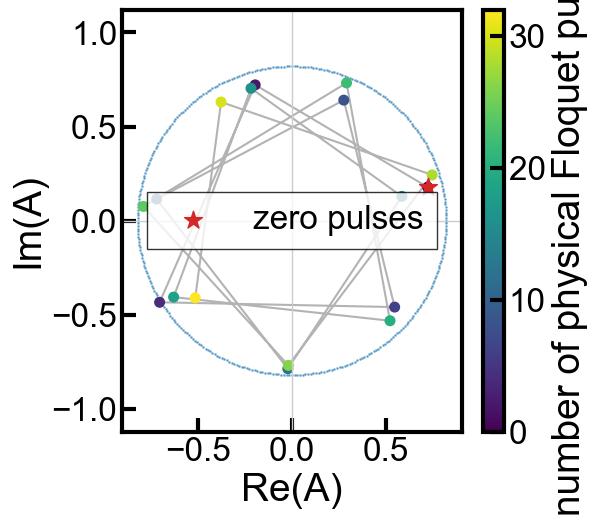

In [271]:
# Plot the complex return from the two analyzer-phase jobs.
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from experiments.qsim.floquet_dark_mode_readout import DarkBaseExperiment


phase_fnames = [
    r'C:\experiments\260526_qsim_darkmode\data\JOB-20260720-00330_QsimBaseExperiment.h5',
    r'C:\experiments\260526_qsim_darkmode\data\JOB-20260720-00331_QsimBaseExperiment.h5',
]
normalize_to_zero_pulse = False

quadratures = {}
pulse_counts = None

for fname in phase_fnames:
    expt = DarkBaseExperiment.from_h5file(fname)
    measured_pulse_counts = np.asarray(expt.data['ypts'], dtype=int)
    prep_phases = np.asarray(expt.data['xpts'], dtype=float) % 360.
    signal = np.asarray(expt.data['avgi'], dtype=float).reshape(
        len(measured_pulse_counts),
        len(prep_phases),
    )

    Ig = float(np.asarray(expt.cfg.device.readout.Ig).reshape(-1)[0])
    Ie = float(np.asarray(expt.cfg.device.readout.Ie).reshape(-1)[0])
    Pe = (signal - Ig) / (Ie - Ig)

    theta_0 = np.flatnonzero(np.isclose(prep_phases, 0.))[0]
    theta_180 = np.flatnonzero(np.isclose(prep_phases, 180.))[0]
    analyzer_phase = int(round(
        float(expt.cfg.expt.spectroscopy_analyzer_phase)
    )) % 360
    quadratures[analyzer_phase] = Pe[:, theta_0] - Pe[:, theta_180]

    if pulse_counts is None:
        pulse_counts = measured_pulse_counts
    elif not np.array_equal(measured_pulse_counts, pulse_counts):
        raise ValueError('the two jobs contain different pulse counts')

complex_return = quadratures[0] + 1j * quadratures[90]
if normalize_to_zero_pulse:
    plotted_return = complex_return / complex_return[0]
    axis_label = 'A / A(0)'
else:
    plotted_return = complex_return
    axis_label = 'A'

fig, ax = plt.subplots(figsize=(6.4, 5.8))
ax.plot(plotted_return.real, plotted_return.imag, color='0.7', zorder=1)
points = ax.scatter(
    plotted_return.real,
    plotted_return.imag,
    c=pulse_counts,
    cmap='viridis',
    s=48,
    zorder=2,
)
ax.scatter(
    plotted_return.real[0],
    plotted_return.imag[0],
    marker='*',
    s=180,
    color='tab:red',
    label='zero pulses',
    zorder=3,
)

theta = np.linspace(0, 2*np.pi, 361)
cpx = 0.82*np.exp(1j*theta)
ax.scatter(
    cpx.real,
    cpx.imag,
    s = 1,
    alpha = 0.5
)


ax.axhline(0., color='0.8', linewidth=1.)
ax.axvline(0., color='0.8', linewidth=1.)
ax.set_xlabel(f'Re({axis_label})')
ax.set_ylabel(f'Im({axis_label})')
ax.set_aspect('equal', adjustable='datalim')
ax.legend()
fig.colorbar(points, ax=ax, label='number of physical Floquet pulses')
# fig.suptitle(
#     'M1 from M1-S4 complex return\n'
#     + '\n'.join(Path(fname).name for fname in phase_fnames)
# )
plt.tight_layout()
plt.show()


# N=2 Hamiltonian spectroscopy from saved jobs

The files below contain 15 occupations and two analyzer phases for each
occupation. Each file already contains both preparation phases
$\theta=(0,180)^\circ$. The complex return is reconstructed as

$$
Q(\phi)=P_e(0,\phi)-P_e(180^\circ,\phi),\qquad
A_{\mathbf n}=Q(0)+iQ(90^\circ).
$$

The decoder phase matrix saved in each HDF5 file was already applied during
acquisition and is not applied again here. The last cell applies only the
overall occupation-dependent shifts entered explicitly by the user.

In [272]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import product
from experiments.qsim.floquet_dark_mode_readout import DarkBaseExperiment


spectroscopy_fnames = [[['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00267_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00271_DarkBaseExperiment.h5'],
  ['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00269_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00273_DarkBaseExperiment.h5']],
 [['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00275_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00279_DarkBaseExperiment.h5'],
  ['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00277_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00281_DarkBaseExperiment.h5']],
 [['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00283_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00287_DarkBaseExperiment.h5'],
  ['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00285_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00289_DarkBaseExperiment.h5']],
 [['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00291_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00295_DarkBaseExperiment.h5'],
  ['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00293_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00297_DarkBaseExperiment.h5']],
 [['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00299_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00303_DarkBaseExperiment.h5'],
  ['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00301_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00305_DarkBaseExperiment.h5']],
 [['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00307_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00311_DarkBaseExperiment.h5'],
  ['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00309_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00313_DarkBaseExperiment.h5']],
 [['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00315_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00319_DarkBaseExperiment.h5'],
  ['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00317_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00321_DarkBaseExperiment.h5']],
 [['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00323_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00327_DarkBaseExperiment.h5'],
  ['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00325_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00329_DarkBaseExperiment.h5']],
 [['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00331_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00335_DarkBaseExperiment.h5'],
  ['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00333_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00337_DarkBaseExperiment.h5']],
 [['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00339_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00343_DarkBaseExperiment.h5'],
  ['C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00341_DarkBaseExperiment.h5',
   'C:\\experiments\\260526_qsim_darkmode\\data\\JOB-20260721-00345_DarkBaseExperiment.h5']]]

# One ordered Floquet cycle represents this logical Hamiltonian time.
hamiltonian_dt_us = 0.08
physical_cycle_us = 0.4130059523809524
floquet_couplings_MHz = np.array([
    0.078125, 0.078125, 0.078125, 0.078125,
])
zero_padding = 8
energy_limit_MHz = 1.25

missing_files = [
    fname
    for occupation_files in spectroscopy_fnames
    for phi_files in occupation_files
    for fname in phi_files
    if not Path(fname).exists()
]
if missing_files:
    raise FileNotFoundError('\n'.join(missing_files))

print('occupation groups:', len(spectroscopy_fnames))
print('HDF5 files:', sum(
    len(phi_files)
    for occupation_files in spectroscopy_fnames
    for phi_files in occupation_files
))

occupation groups: 10
HDF5 files: 40


## Reconstruct the complex return

Files are placed by their saved analyzer phase rather than by list position.
Only the reconstructed traces and saved acquisition metadata are retained in
memory; the large shot arrays in each HDF5 file are released immediately.

In [274]:
occupation_strings = []
A_rows = []
cycles = None
decoder_phase_matrix = None
swap_stors = None
physical_kerr_MHz = None

for occupation_files in spectroscopy_fnames:
    Q_by_phi = {}
    saved_occupation = None

    for phi_files in occupation_files:
        cycle_parts = []
        Q_parts = []
        saved_phi = None

        for fname in phi_files:
            expt = DarkBaseExperiment.from_h5file(fname)
            expt_cfg = expt.cfg.expt

            saved_kerr_MHz = float(np.asarray(
                expt.cfg.device.manipulate.kerr
            ).reshape(-1)[0])
            saved_kerr_MHz = -10e-3
            if physical_kerr_MHz is None:
                physical_kerr_MHz = saved_kerr_MHz
            elif not np.isclose(saved_kerr_MHz, physical_kerr_MHz):
                raise ValueError('the saved M1 Kerr changed between jobs')

            occupation = tuple(int(n) for n in expt_cfg.spectroscopy_occupations)
            phi = float(expt_cfg.spectroscopy_analyzer_phase) % 360.
            measured_theta = np.asarray(expt.data['xpts'], dtype=float) % 360.
            measured_cycles = np.asarray(expt.data['ypts'], dtype=int)
            signal = np.asarray(expt.data['avgi'], dtype=float).reshape(
                len(measured_cycles),
                len(measured_theta),
            )

            theta_0 = np.flatnonzero(np.isclose(measured_theta, 0.))[0]
            theta_180 = np.flatnonzero(np.isclose(measured_theta, 180.))[0]

            readout_Ig = float(np.asarray(
                expt.cfg.device.readout.Ig
            ).reshape(-1)[0])
            readout_Ie = float(np.asarray(
                expt.cfg.device.readout.Ie
            ).reshape(-1)[0])
            Pe = (signal - readout_Ig) / (readout_Ie - readout_Ig)

            if saved_occupation is None:
                saved_occupation = occupation
            elif occupation != saved_occupation:
                raise ValueError('one occupation group contains different states')

            if saved_phi is None:
                saved_phi = phi
            elif not np.isclose(phi, saved_phi):
                raise ValueError('one analyzer group contains different phases')

            saved_matrix = np.asarray(
                expt_cfg.decoder_phase_matrix,
                dtype=float,
            )
            if decoder_phase_matrix is None:
                decoder_phase_matrix = saved_matrix
                swap_stors = [int(stor) for stor in expt_cfg.swap_stors]
            elif not np.allclose(saved_matrix, decoder_phase_matrix):
                raise ValueError('the saved decoder phase matrix changed between jobs')

            cycle_parts.append(measured_cycles)
            Q_parts.append(Pe[:, theta_0] - Pe[:, theta_180])
            del expt

        acquired_cycles = np.concatenate(cycle_parts)
        Q = np.concatenate(Q_parts)
        order = np.argsort(acquired_cycles)
        acquired_cycles = acquired_cycles[order]
        Q = Q[order]

        if cycles is None:
            cycles = acquired_cycles
        elif not np.array_equal(acquired_cycles, cycles):
            raise ValueError('the saved Floquet cycles are incomplete or different')

        Q_by_phi[int(round(saved_phi)) % 360] = Q

    if 0 not in Q_by_phi or 90 not in Q_by_phi:
        raise ValueError('each occupation needs analyzer phases 0 and 90 deg')

    occupation_strings.append(saved_occupation)
    A_rows.append(Q_by_phi[0] + 1j * Q_by_phi[90])

A_raw = np.asarray(A_rows)
N = int(sum(occupation_strings[0]))
mode_labels = ['M1'] + [f'S{stor}' for stor in swap_stors]

print('N =', N)
print('A_raw shape =', A_raw.shape)
for occupation, amplitude in zip(occupation_strings, A_raw):
    print(occupation, 'A(0) =', amplitude[0])

N = 2
A_raw shape = (10, 400)
(0, 0, 0, 0, 2) A(0) = (0.0010993944527022403-0.009898952749965662j)
(0, 0, 0, 1, 1) A(0) = (-0.5717053908850924-0.13078217521682323j)
(0, 0, 0, 2, 0) A(0) = (-0.02764949821472973+0.7780488344520491j)
(0, 0, 1, 0, 1) A(0) = (-0.6817383350828423-0.3154831080481574j)
(0, 0, 1, 1, 0) A(0) = (0.6361678615119033-0.35497221209355273j)
(0, 0, 2, 0, 0) A(0) = (-0.8009183013742152-0.1755086095225145j)
(0, 1, 0, 0, 1) A(0) = (0.413989499825633+0.5851535953648588j)
(0, 1, 0, 1, 0) A(0) = (-0.7435464557347977+0.14649798937393022j)
(0, 1, 1, 0, 0) A(0) = (0.29779952959716327-0.7019540313295798j)
(0, 2, 0, 0, 0) A(0) = (-0.12505301974294047-0.8059193933281504j)


## Manual occupation-resolved rigid-shift correction and DOS

This cell does not infer a correction from the M1 row and does not fit a
measured trace to theory. Enter one overall spectral shift for every
occupation string in `occupation_energy_shift_MHz` below.

The value is `desired peak position - measured peak position`, in MHz. A
positive value moves the whole spectrum to the right and a negative value
moves it to the left. The correction changes only the phase ramp of
$A_{\mathbf n}(t)$; it does not fit, stretch, or rescale the spectrum.

The target Hamiltonian uses the signed Kerr stored in the HDF5 configuration,
as in the preceding saved-job analysis cell.

manually entered occupation-resolved rigid shifts
(0, 0, 0, 0, 2) spectral shift = -2.170000 MHz, phase ramp = +62.496000 deg/cycle, |A(0)| = 0.0100
(0, 0, 0, 1, 1) spectral shift = -0.450000 MHz, phase ramp = +12.960000 deg/cycle, |A(0)| = 0.5865
(0, 0, 0, 2, 0) spectral shift = -2.170000 MHz, phase ramp = +62.496000 deg/cycle, |A(0)| = 0.7785
(0, 0, 1, 0, 1) spectral shift = -0.450000 MHz, phase ramp = +12.960000 deg/cycle, |A(0)| = 0.7512
(0, 0, 1, 1, 0) spectral shift = -0.450000 MHz, phase ramp = +12.960000 deg/cycle, |A(0)| = 0.7285
(0, 0, 2, 0, 0) spectral shift = -2.170000 MHz, phase ramp = +62.496000 deg/cycle, |A(0)| = 0.8199
(0, 1, 0, 0, 1) spectral shift = -0.450000 MHz, phase ramp = +12.960000 deg/cycle, |A(0)| = 0.7168
(0, 1, 0, 1, 0) spectral shift = -0.450000 MHz, phase ramp = +12.960000 deg/cycle, |A(0)| = 0.7578
(0, 1, 1, 0, 0) spectral shift = -0.450000 MHz, phase ramp = +12.960000 deg/cycle, |A(0)| = 0.7625
(0, 2, 0, 0, 0) spectral shift = -2.170000 MHz, phase ramp 

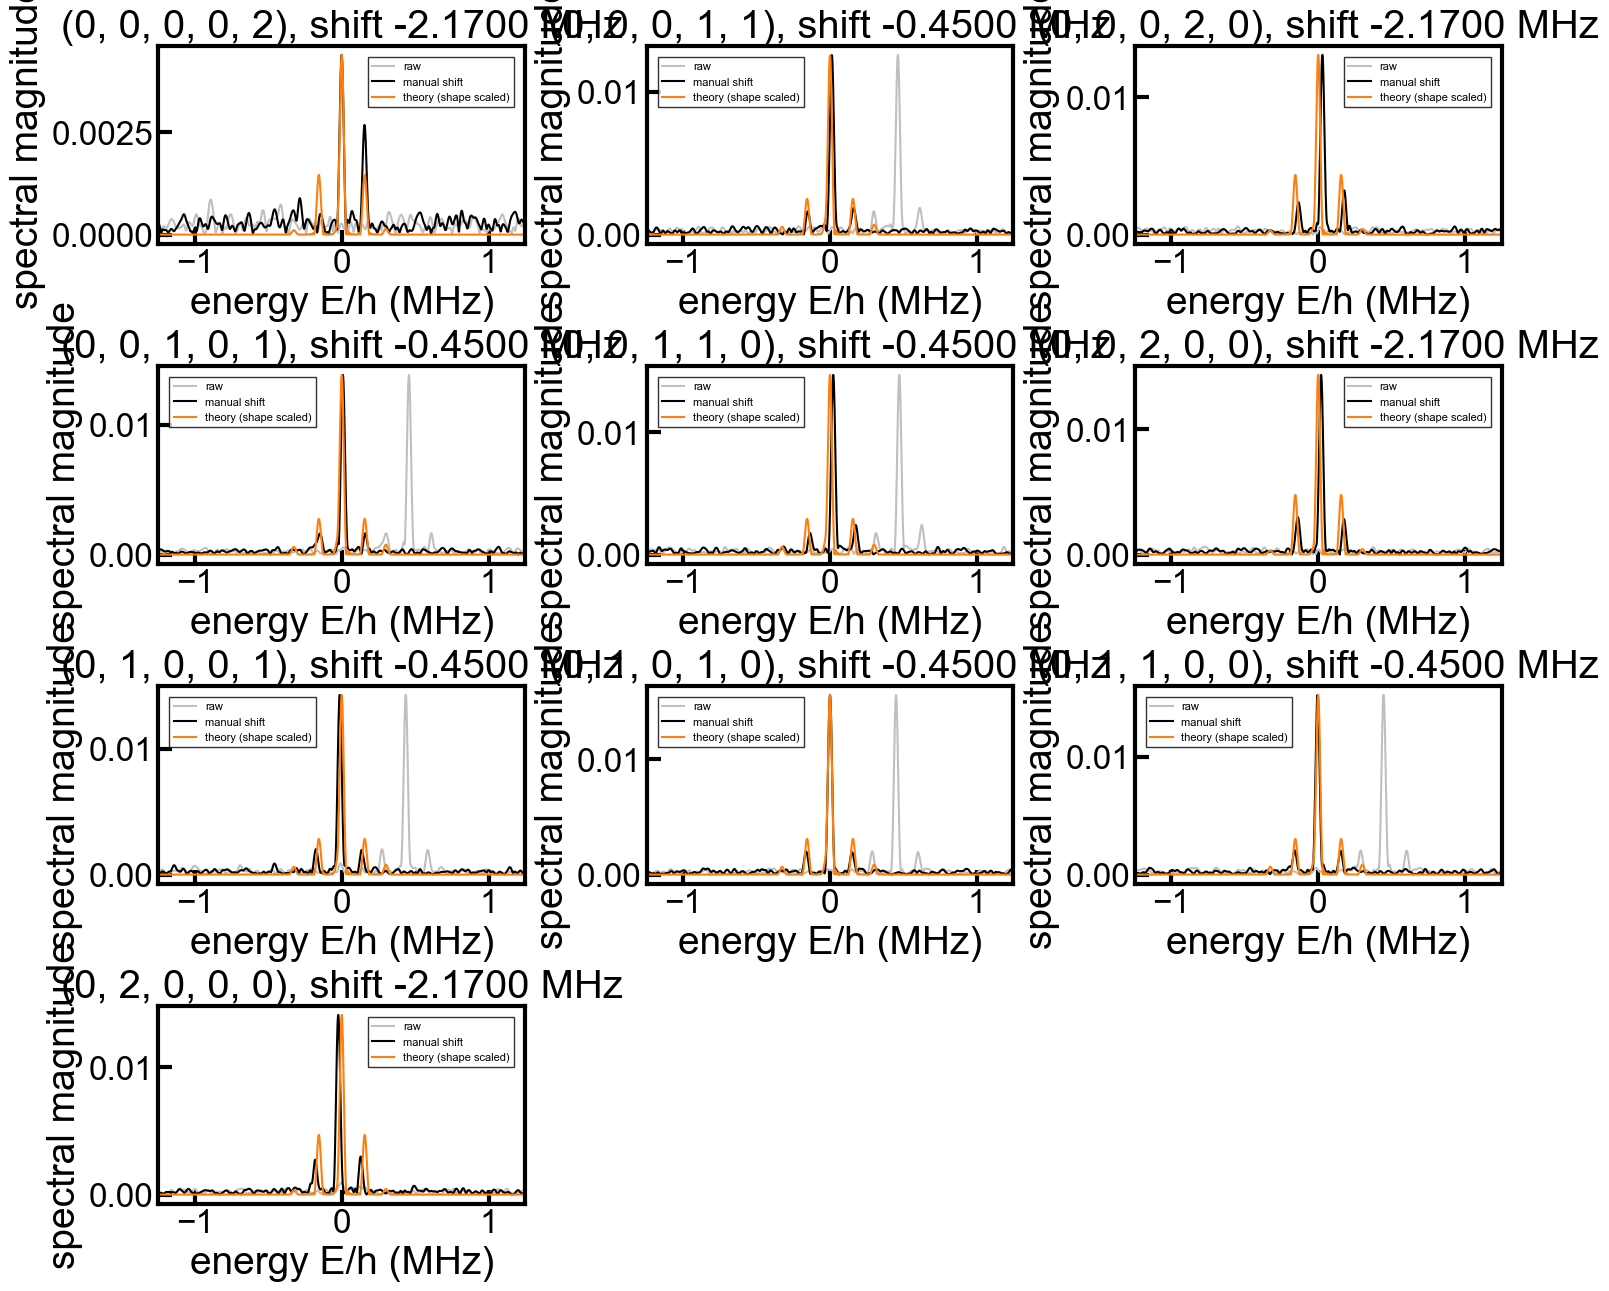

C:\Users\slab\AppData\Local\Temp\ipykernel_9340\2759572124.py:272: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


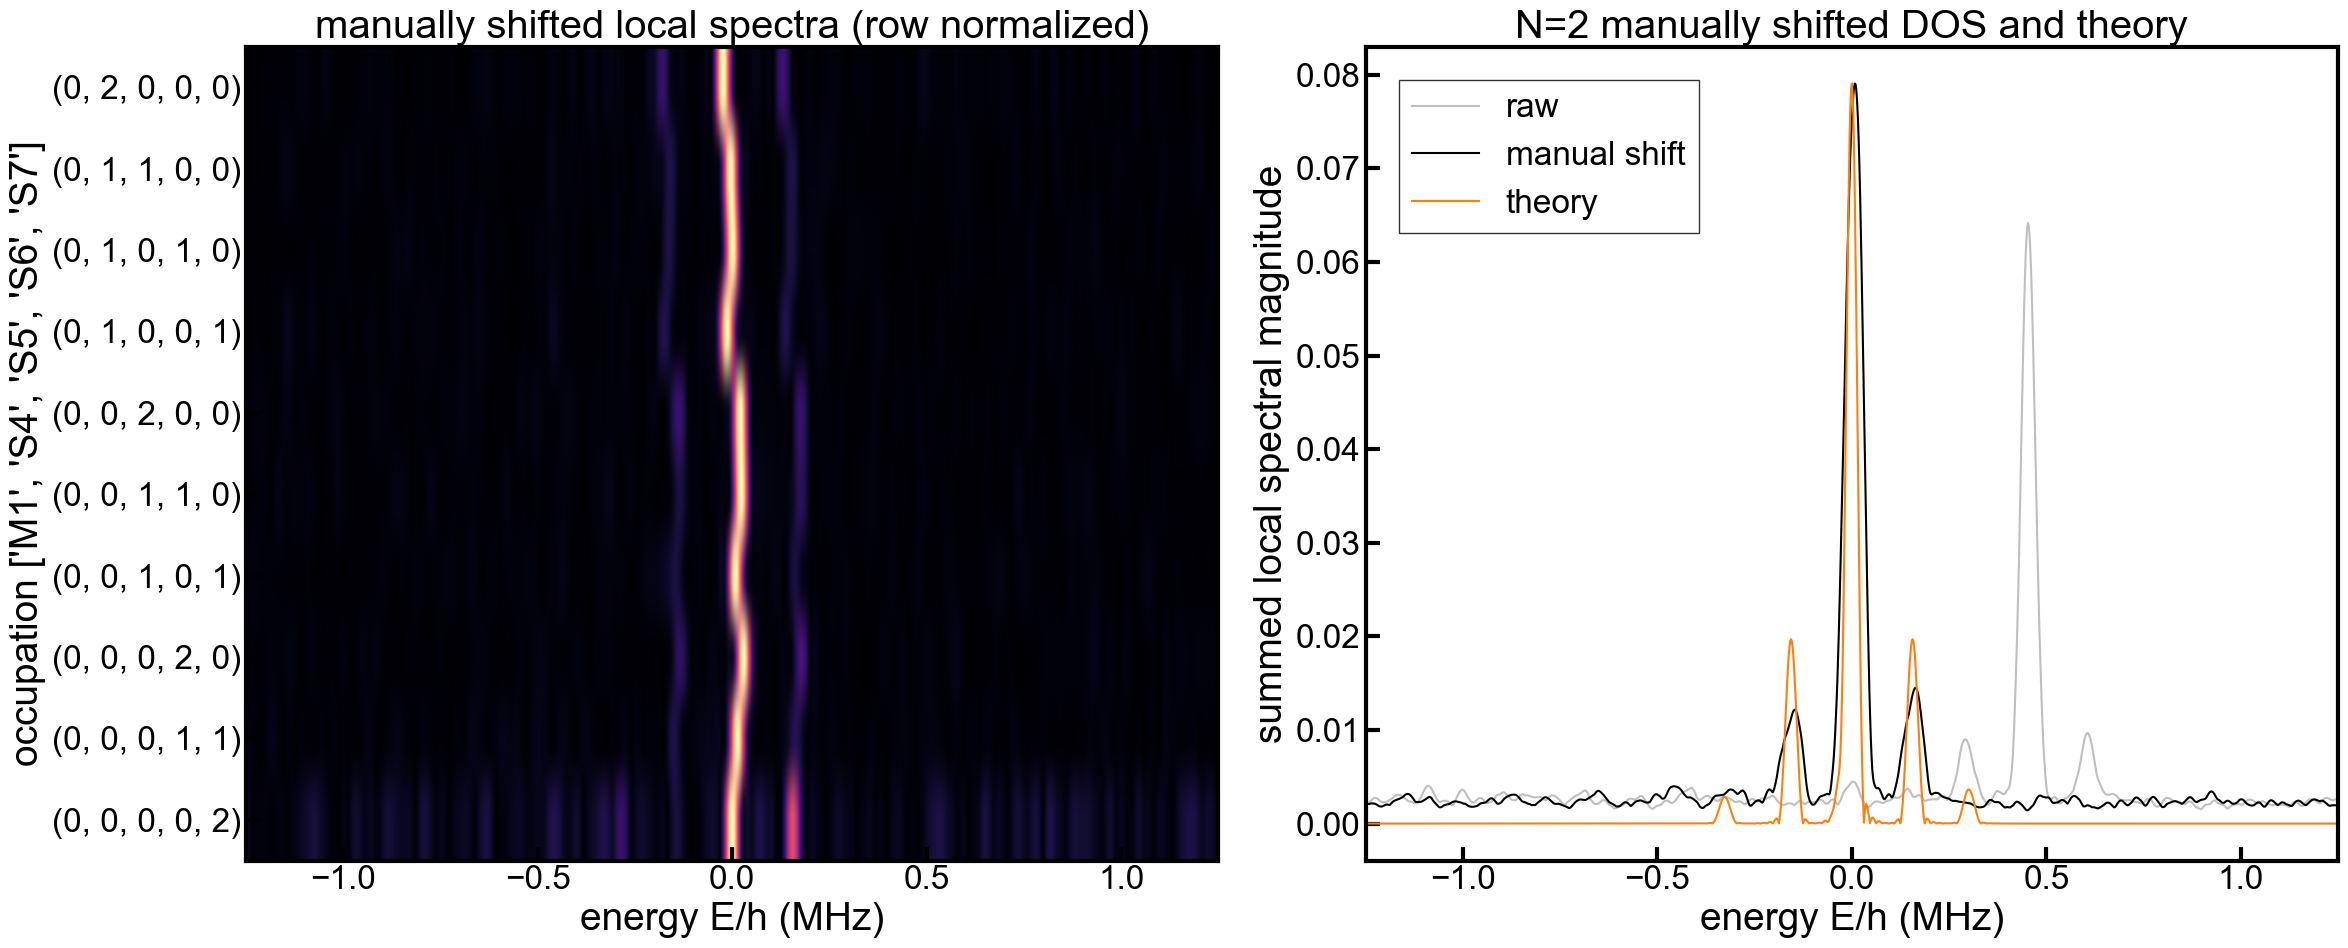

saved signed M1 Kerr = -0.01 MHz
effective theory Kerr = -0.05162574404761904 MHz
target eigenenergies = [-3.26827235e-01 -1.56250000e-01 -1.56250000e-01 -1.56250000e-01
 -2.56379534e-02 -2.78053615e-16 -1.34940125e-16 -1.33926076e-16
 -7.29335693e-17 -3.41970305e-17  1.53657950e-18  1.56250000e-01
  1.56250000e-01  1.56250000e-01  3.00839444e-01] MHz
sample time = 0.16 us
Nyquist range = +/- 3.125 MHz
approximate Hann resolution = 0.03125 MHz
largest relative row FFT-power change from the phase ramps = 6.550775611777132e-16


In [281]:
time_us = cycles * hamiltonian_dt_us
sample_times_us = np.diff(time_us)
if not np.allclose(sample_times_us, sample_times_us[0]):
    raise ValueError('FFT requires uniformly spaced Floquet cycles')

window = np.hanning(len(cycles))
n_fft = zero_padding * len(cycles)
energy_MHz = np.fft.fftshift(np.fft.fftfreq(
    n_fft,
    d=float(sample_times_us[0]),
))
energy_step_MHz = float(energy_MHz[1] - energy_MHz[0])

# First construct every raw local spectrum. Do not divide rows by A(0):
# this cell is allowed to translate spectra, but not to change their weights.
raw_local_DOS = np.empty((len(occupation_strings), n_fft))
for occupation_index in range(len(occupation_strings)):
    raw_local_DOS[occupation_index] = abs(np.fft.fftshift(np.fft.ifft(
        A_raw[occupation_index] * window,
        n=n_fft,
    )))

# Build the same fixed-N target Hamiltonian used by the orange qsim curve.
if len(floquet_couplings_MHz) != len(swap_stors):
    raise ValueError('floquet_couplings_MHz must match swap_stors')

fock_basis = [
    tuple(occupation)
    for occupation in product(
        range(N + 1),
        repeat=len(mode_labels),
    )
    if sum(occupation) == N
]
fock_index = {
    occupation: index
    for index, occupation in enumerate(fock_basis)
}

effective_kerr_MHz = (
    physical_kerr_MHz
    * physical_cycle_us
    / hamiltonian_dt_us
)
H_N_MHz = np.zeros((len(fock_basis), len(fock_basis)))

for column, occupation in enumerate(fock_basis):
    n_M1 = occupation[0]
    H_N_MHz[column, column] = (
        0.5 * effective_kerr_MHz * n_M1 * (n_M1 - 1)
    )

    for mode_index, coupling_MHz in enumerate(
            floquet_couplings_MHz, start=1):
        if n_M1 == 0:
            continue

        final_occupation = list(occupation)
        final_occupation[0] -= 1
        final_occupation[mode_index] += 1
        row = fock_index[tuple(final_occupation)]
        matrix_element_MHz = coupling_MHz * np.sqrt(
            n_M1 * (occupation[mode_index] + 1)
        )
        H_N_MHz[row, column] += matrix_element_MHz
        H_N_MHz[column, row] += matrix_element_MHz

theory_energies_MHz, theory_states = np.linalg.eigh(H_N_MHz)
theory_phase = np.exp(
    -2j * np.pi * np.outer(theory_energies_MHz, time_us)
)
theory_local_DOS = np.empty_like(raw_local_DOS)

for occupation_index, occupation in enumerate(occupation_strings):
    basis_row = fock_index[occupation]
    spectral_weights = abs(theory_states[basis_row]) ** 2
    theory_A = spectral_weights @ theory_phase
    theory_local_DOS[occupation_index] = abs(np.fft.fftshift(
        np.fft.ifft(
            theory_A * window,
            n=n_fft,
        )
    ))

# Enter the desired rigid energy shift for each occupation, in MHz.
# Example: if a measured peak is at +0.45 MHz and should be at 0 MHz,
# enter -0.45 for that occupation.

one_fock = -0.45
two_fock = -2.17

occupation_energy_shift_MHz = {
    (2, 0, 0, 0, 0): two_fock,
    (1, 1, 0, 0, 0): one_fock,
    (1, 0, 1, 0, 0): one_fock,
    (1, 0, 0, 1, 0): one_fock,
    (1, 0, 0, 0, 1): one_fock,
    (0, 2, 0, 0, 0): two_fock,
    (0, 1, 1, 0, 0): one_fock,
    (0, 1, 0, 1, 0): one_fock,
    (0, 1, 0, 0, 1): one_fock,
    (0, 0, 2, 0, 0): two_fock,
    (0, 0, 1, 1, 0): one_fock,
    (0, 0, 1, 0, 1): one_fock,
    (0, 0, 0, 2, 0): two_fock,
    (0, 0, 0, 1, 1): one_fock,
    (0, 0, 0, 0, 2): two_fock,
}

missing_occupations = [
    occupation
    for occupation in occupation_strings
    if occupation not in occupation_energy_shift_MHz
]
if missing_occupations:
    raise KeyError(
        'add overall shifts for these occupations: '
        f'{missing_occupations}'
    )

spectral_shift_MHz = np.array([
    float(occupation_energy_shift_MHz[occupation])
    for occupation in occupation_strings
])

# Under the current IFFT convention this moves every peak by +shift_MHz.
A_corrected = A_raw * np.exp(
    -2j * np.pi
    * spectral_shift_MHz[:, None]
    * time_us[None, :]
)

corrected_local_DOS = np.empty_like(raw_local_DOS)
for occupation_index in range(len(occupation_strings)):
    corrected_local_DOS[occupation_index] = abs(np.fft.fftshift(np.fft.ifft(
        A_corrected[occupation_index] * window,
        n=n_fft,
    )))

raw_DOS = np.sum(raw_local_DOS, axis=0)
corrected_DOS = np.sum(corrected_local_DOS, axis=0)
theory_DOS = np.sum(theory_local_DOS, axis=0)
theory_DOS *= corrected_DOS.max() / theory_DOS.max()

print('manually entered occupation-resolved rigid shifts')
for occupation_index, (occupation, shift_MHz) in enumerate(zip(
        occupation_strings,
        spectral_shift_MHz)):
    phase_ramp_deg_per_cycle = (
        -360. * shift_MHz * hamiltonian_dt_us
    )
    print(
        occupation,
        f'spectral shift = {shift_MHz:+.6f} MHz,',
        f'phase ramp = {phase_ramp_deg_per_cycle:+.6f} deg/cycle,',
        f'|A(0)| = {abs(A_raw[occupation_index, 0]):.4f}',
    )

# Show every manually shifted local spectrum.
n_columns = 3
n_rows = int(np.ceil(len(occupation_strings) / n_columns))
fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(15, 3.2 * n_rows),
    squeeze=False,
    constrained_layout=True,
)

for occupation_index, occupation in enumerate(occupation_strings):
    row, column = divmod(occupation_index, n_columns)
    ax = axes[row, column]
    theory_plot = theory_local_DOS[occupation_index].copy()
    theory_plot *= (
        corrected_local_DOS[occupation_index].max()
        / theory_plot.max()
    )

    ax.plot(
        energy_MHz,
        raw_local_DOS[occupation_index],
        color='0.75',
        label='raw',
    )
    ax.plot(
        energy_MHz,
        corrected_local_DOS[occupation_index],
        color='black',
        label='manual shift',
    )
    ax.plot(
        energy_MHz,
        theory_plot,
        color='tab:orange',
        label='theory (shape scaled)',
    )
    ax.set_xlim(-energy_limit_MHz, energy_limit_MHz)
    ax.set(
        xlabel='energy E/h (MHz)',
        ylabel='spectral magnitude',
        title=(
            f'{occupation}, shift '
            f'{spectral_shift_MHz[occupation_index]:+.4f} MHz'
        ),
    )
    ax.legend(fontsize=8)

for empty_index in range(len(occupation_strings), n_rows * n_columns):
    row, column = divmod(empty_index, n_columns)
    axes[row, column].axis('off')

plt.show()

corrected_heatmap = corrected_local_DOS / np.maximum(
    corrected_local_DOS.max(axis=1, keepdims=True),
    1e-15,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(24, 10),
    constrained_layout=True,
)

axes[0].imshow(
    corrected_heatmap,
    origin='lower',
    aspect='auto',
    extent=[
        energy_MHz[0],
        energy_MHz[-1],
        -0.5,
        len(occupation_strings) - 0.5,
    ],
    cmap='magma',
)
axes[0].set_yticks(range(len(occupation_strings)))
axes[0].set_yticklabels([str(occupation) for occupation in occupation_strings])
axes[0].set_xlim(-energy_limit_MHz, energy_limit_MHz)
axes[0].set(
    xlabel='energy E/h (MHz)',
    ylabel=f'occupation {mode_labels}',
    title='manually shifted local spectra (row normalized)',
)

axes[1].plot(
    energy_MHz,
    raw_DOS,
    color='0.75',
    label='raw',
)
axes[1].plot(
    energy_MHz,
    corrected_DOS,
    color='black',
    label='manual shift',
)
axes[1].plot(
    energy_MHz,
    theory_DOS,
    color='tab:orange',
    label='theory',
)
axes[1].set_xlim(-energy_limit_MHz, energy_limit_MHz)
axes[1].set(
    xlabel='energy E/h (MHz)',
    ylabel='summed local spectral magnitude',
    title=f'N={N} manually shifted DOS and theory',
)
axes[1].legend()
fig.tight_layout()
plt.show()

raw_power = np.sum(raw_local_DOS ** 2, axis=1)
corrected_power = np.sum(corrected_local_DOS ** 2, axis=1)

print('saved signed M1 Kerr =', physical_kerr_MHz, 'MHz')
print('effective theory Kerr =', effective_kerr_MHz, 'MHz')
print('target eigenenergies =', theory_energies_MHz, 'MHz')
print('sample time =', sample_times_us[0], 'us')
print('Nyquist range = +/-', 0.5 / sample_times_us[0], 'MHz')
print(
    'approximate Hann resolution =',
    2. / (len(cycles) * sample_times_us[0]),
    'MHz',
)
print(
    'largest relative row FFT-power change from the phase ramps =',
    np.max(abs(corrected_power - raw_power) / raw_power),
)